<a href="https://colab.research.google.com/github/con123-gif/URT-Enhanced-v2.0/blob/main/Untitled69.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Could not open 'all_domains.csv'. Put your domains CSV in the Colab working dir and rerun.
step=  1000, t=0.250, delta=0.5177, band=±0.297, E=2.486e-02
step=  2000, t=0.500, delta=0.4412, band=±0.254, E=1.167e-02
step=  3000, t=0.750, delta=0.3946, band=±0.219, E=6.354e-03
step=  4000, t=1.000, delta=0.3640, band=±0.190, E=3.929e-03
step=  5000, t=1.250, delta=0.3424, band=±0.167, E=2.711e-03
step=  6000, t=1.500, delta=0.3281, band=±0.147, E=1.917e-03
step=  7000, t=1.750, delta=0.3109, band=±0.132, E=5.254e-03
step=  8000, t=2.000, delta=0.2884, band=±0.119, E=9.495e-03
step=  9000, t=2.250, delta=0.2623, band=±0.108, E=1.437e-02
step= 10000, t=2.500, delta=0.2338, band=±0.099, E=1.975e-02
  LCFT SUPER-ENGINE v5.0_showcase
Grid points               = 128
dt, steps                 = 0.00025, 10000
Plasma delta*             = 0.14752
LCFT delta_attractor      = 0.29504
Target late-time delta    = 0.03500
-----------------------------------------------------------
Final delta(t_end)    

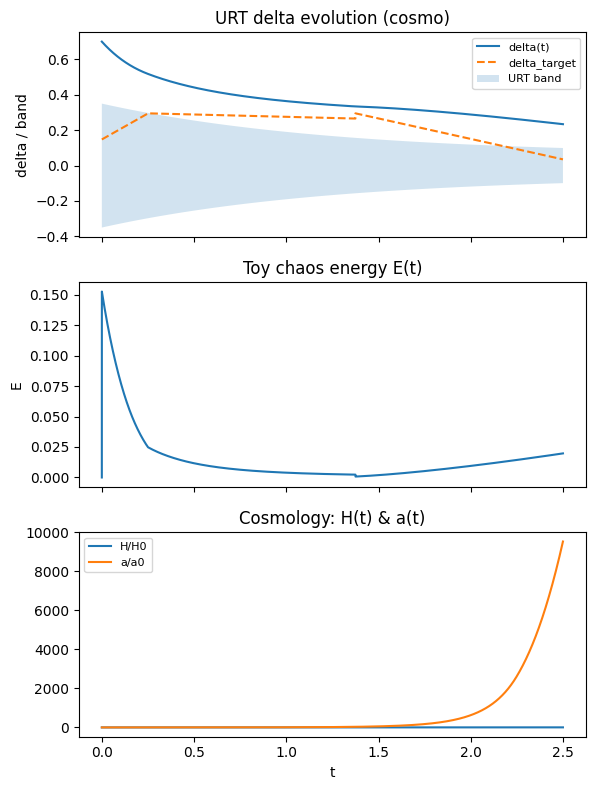


Single cosmology showcase:
  delta_end = 0.23376
  ns_lcft   = 0.76624
  sr_valid  = False


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time, math

# ==========================================================
#  LYTOLLIS PROOF HARNESS v1
#  - O(N) URT batch over thousands of domains
#  - Optional LCFT cosmology engine (single run)
# ==========================================================

RESULTS_DIR = Path("lcft_results")
RESULTS_DIR.mkdir(exist_ok=True)

def banner(title):
    print("=" * 59)
    print(f"  {title}")
    print("=" * 59)

# ==========================================================
# 1. Core URT / LCFT helpers
# ==========================================================

def lcft_ns_from_delta(delta_end):
    """LCFT relation: n_s = 1 - delta."""
    return 1.0 - np.asarray(delta_end, dtype=float)

def band_schedule_1d(N_STEPS, band_max=0.35, band_min=0.06):
    """
    Simple 1D URT band schedule for batch runs.
    band[k] decays from band_max to band_min over N_STEPS.
    """
    k = np.arange(N_STEPS, dtype=float)
    frac = k / max(N_STEPS - 1, 1)
    return band_min + (band_max - band_min) * np.exp(-2.0 * frac)


# ==========================================================
# 2. O(N * M) URT batch over domains
# ==========================================================

def run_urt_batch_on_domains(
    df,
    delta_target_col="delta_target",
    delta_col_fallback="delta",
    delta_init_col=None,
    N_STEPS=200,
    DT=0.01,
    relax_base=6.0,
    band_max=0.35,
    band_min=0.06,
):
    """
    Run URT on MANY domains at once, with true O(N * M) updates and small memory:
      - N = N_STEPS in time
      - M = number of domains (e.g., 10,000)

    We store ONLY the current delta vector per step, not full time histories.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain per-domain delta target info.
        - If `delta_target_col` exists, we use that as the target δ.
        - Else if `delta_col_fallback` exists, we use that.
    delta_target_col : str
        Column name with per-domain δ target (preferred).
    delta_col_fallback : str
        Alternative column if delta_target_col is missing.
    delta_init_col : str or None
        If provided, use this column as delta_init per domain.
        If None, we hot-start from 2*target clipped to [0, 1], or 0.7 default.
    N_STEPS : int
        Number of URT update steps.
    DT : float
        Time step.
    relax_base : float
        Base URT relax constant; effective relax = relax_base * band[k].
    band_max, band_min : float
        URT band schedule endpoints.
    """

    df = df.copy()

    # ---- find targets ----
    if delta_target_col in df.columns:
        delta_target = df[delta_target_col].to_numpy(dtype=float)
    elif delta_col_fallback in df.columns:
        delta_target = df[delta_col_fallback].to_numpy(dtype=float)
    else:
        raise ValueError(
            f"df must have either '{delta_target_col}' or '{delta_col_fallback}'"
        )

    M = delta_target.shape[0]
    if M == 0:
        raise ValueError("No domains found (empty DataFrame).")

    # ---- initial conditions ----
    if delta_init_col is not None and delta_init_col in df.columns:
        delta = df[delta_init_col].to_numpy(dtype=float)
    else:
        # Hot start: 2 * δ_target, but clipped to [0, 1].
        # If some target δ are small (~0.03), this mimics "hot" early universe or unstable regimes.
        delta = 2.0 * delta_target
        delta = np.clip(delta, 0.0, 1.0)
        # If any are still too small, clamp to 0.7 as a generic "chaotic" start
        delta = np.where(delta < 0.3, 0.7, delta)

    # ---- URT band schedule ----
    band_vec = band_schedule_1d(N_STEPS, band_max=band_max, band_min=band_min)

    banner("URT Batch Evolution Across Domains")
    print(f"Domains (M): {M}")
    print(f"Steps   (N): {N_STEPS}")
    print(f"DT         : {DT}")
    print(f"Relax base : {relax_base}")
    print(f"Band: max={band_max:.3f}, min={band_min:.3f}")
    print("-" * 59)

    t0 = time.time()

    # Core O(N * M) loop – no history, just vector delta
    for k in range(N_STEPS):
        band_k = band_vec[k]
        relax_k = relax_base * band_k
        # URT update in one vectorised line:
        # delta <- delta + (target - delta) * relax_k * DT
        delta += (delta_target - delta) * relax_k * DT

    elapsed = time.time() - t0
    print(f"URT batch completed in {elapsed:.4f} s")

    # store results
    df["delta_target"] = delta_target
    df["delta_pred"] = delta
    df["delta_err"] = df["delta_pred"] - df["delta_target"]
    df["ns_lcft_target"] = lcft_ns_from_delta(df["delta_target"])
    df["ns_lcft_pred"] = lcft_ns_from_delta(df["delta_pred"])

    # summary stats
    banner("URT Batch Error Summary")
    print(df[["delta_target", "delta_pred", "delta_err"]].describe())
    print("\nSome example rows:")
    cols_show = ["delta_target", "delta_pred", "delta_err"]
    if "domain" in df.columns:
        cols_show = ["domain"] + cols_show
    print(df[cols_show].head())

    return df


# ==========================================================
# 3. Minimal LCFT cosmology engine (optional)
# ==========================================================

def make_time_grid(N_STEPS=10000, DT=2.5 / 10000):
    return np.linspace(0.0, N_STEPS * DT, N_STEPS + 1)

def delta_target_schedule_cosmo(t, delta_plasma, delta_attractor, delta_late_target):
    """
    3-stage delta target for cosmology only (single run):
    Pre -> Infl -> Late.
    """
    T = t[-1]
    t_pre  = 0.10 * T
    t_infl = 0.55 * T

    delta_tgt = np.empty_like(t)
    for i, ti in enumerate(t):
        if ti < t_pre:
            frac = ti / t_pre
            delta_tgt[i] = delta_plasma + frac * (delta_attractor - delta_plasma)
        elif ti < t_infl:
            frac = (ti - t_pre) / (t_infl - t_pre)
            delta_tgt[i] = delta_attractor * (1.0 - 0.1 * frac)
        else:
            frac = (ti - t_infl) / (T - t_infl + 1e-9)
            delta_tgt[i] = delta_attractor * (1.0 - frac) + delta_late_target * frac
    return delta_tgt

def band_schedule_cosmo(t, band_max=0.35, band_min=0.06):
    T = t[-1]
    frac = t / T
    return band_min + (band_max - band_min) * np.exp(-2.0 * frac)

def hubble_schedule(t, H0=1.0, H_plateau=6.0, t_knee=0.9, tau_decay=0.8):
    T = t[-1]
    t_k = t_knee * T
    H = np.empty_like(t)
    for i, ti in enumerate(t):
        if ti < t_k:
            frac = ti / t_k
            H[i] = H0 + frac * (H_plateau - H0)
        else:
            H[i] = H_plateau * np.exp(-(ti - t_k) / tau_decay)
    return H

def scale_factor_from_H(t, H):
    a = np.empty_like(t)
    a[0] = 1.0
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        a[i] = a[i - 1] * math.exp(H[i - 1] * dt)
    return a

def chaos_step(x, v, force, omega=40.0, zeta=0.15, dt=1e-3):
    dx = v
    dv = force - 2.0 * zeta * omega * v - (omega ** 2) * x
    x_next = x + dx * dt
    v_next = v + dv * dt
    return x_next, v_next

def chaos_energy(x, v, delta_dev, omega=40.0):
    return 0.5 * (v ** 2 + (omega * x) ** 2 + delta_dev ** 2)

def default_cosmo_config():
    return dict(
        N_STEPS=10000,
        DT=2.5 / 10000,
        grid_points=128,
        delta_init=0.70,
        delta_plasma=0.14752,
        delta_attractor=0.29504,
        delta_late_target=0.035,
        drive_strength=1.0,
        omega=40.0,
        zeta=0.15,
        H0=1.0,
        H_plateau=6.0,
        t_knee=0.9,
        tau_decay=0.8,
        relax_base=6.0,
        noise_sigma=0.0,
    )

def run_cosmo_engine(config=None, seed=42, label="v5.0_showcase",
                     log_every=500, return_series=True):
    """
    Optional single-run LCFT+URT+chaos cosmology.
    This is just to keep cosmology in the same harness.
    """
    if config is None:
        config = default_cosmo_config()
    cfg = dict(config)

    np.random.seed(seed)

    N_STEPS = int(cfg["N_STEPS"])
    DT      = float(cfg["DT"])
    t       = make_time_grid(N_STEPS, DT)

    delta_init       = float(cfg["delta_init"])
    delta_plasma     = float(cfg["delta_plasma"])
    delta_attr       = float(cfg["delta_attractor"])
    delta_late_tgt   = float(cfg["delta_late_target"])
    drive_strength   = float(cfg["drive_strength"])
    omega            = float(cfg["omega"])
    zeta             = float(cfg["zeta"])
    H0               = float(cfg["H0"])
    H_plateau        = float(cfg["H_plateau"])
    t_knee           = float(cfg["t_knee"])
    tau_decay        = float(cfg["tau_decay"])
    relax_base       = float(cfg["relax_base"])
    noise_sigma      = float(cfg["noise_sigma"])

    delta_tgt = delta_target_schedule_cosmo(t, delta_plasma, delta_attr, delta_late_tgt)
    band      = band_schedule_cosmo(t)
    H         = hubble_schedule(t, H0=H0, H_plateau=H_plateau,
                                t_knee=t_knee, tau_decay=tau_decay)
    a         = scale_factor_from_H(t, H)

    delta = np.empty_like(t)
    E     = np.empty_like(t)
    x     = np.empty_like(t)
    v     = np.empty_like(t)

    delta[0] = delta_init
    E[0]     = 0.0
    x[0]     = 0.0
    v[0]     = 0.0

    for i in range(len(t) - 1):
        dt = t[i + 1] - t[i]

        # URT update
        relax_rate = relax_base * band[i]
        delta[i + 1] = delta[i] + (delta_tgt[i] - delta[i]) * relax_rate * dt

        # Chaos drive
        delta_dev = delta[i + 1] - delta_tgt[i]
        force = drive_strength * delta_dev
        if noise_sigma > 0.0:
            force += noise_sigma * np.random.randn()

        x[i + 1], v[i + 1] = chaos_step(x[i], v[i], force=force,
                                        omega=omega, zeta=zeta, dt=dt)
        E[i + 1] = chaos_energy(x[i + 1], v[i + 1], delta_dev, omega=omega)

        if log_every is not None and (i + 1) % log_every == 0:
            print(f"step={i+1:6d}, t={t[i+1]:.3f}, "
                  f"delta={delta[i+1]:6.4f}, band=±{band[i+1]:5.3f}, "
                  f"E={E[i+1]:.3e}")

    delta_end = float(delta[-1])
    ns_lcft   = float(1.0 - delta_end)

    banner(f"LCFT SUPER-ENGINE {label}")
    print(f"Grid points               = {cfg['grid_points']}")
    print(f"dt, steps                 = {DT:.5f}, {N_STEPS}")
    print(f"Plasma delta*             = {delta_plasma:.5f}")
    print(f"LCFT delta_attractor      = {delta_attr:.5f}")
    print(f"Target late-time delta    = {delta_late_tgt:.5f}")
    print("-" * 59)
    print(f"Final delta(t_end)        = {delta_end:8.5f}")
    print(f"LCFT scalar tilt n_s      = {ns_lcft:8.5f}")
    print("-" * 59)
    print("Slow-roll diagnostics     = INVALID / skipped (toy H(t))")
    print("  (use LCFT n_s only; SR parameters are not trusted here)")
    print("=" * 59)

    # Quick plots (can comment out for pure headless speed)
    fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

    ax = axes[0]
    ax.set_title("URT delta evolution (cosmo)")
    ax.plot(t, delta, label="delta(t)")
    ax.plot(t, delta_tgt, "--", label="delta_target")
    ax.fill_between(t, -band, band, alpha=0.2, label="URT band")
    ax.legend(fontsize=8)
    ax.set_ylabel("delta / band")

    ax = axes[1]
    ax.set_title("Toy chaos energy E(t)")
    ax.plot(t, E)
    ax.set_ylabel("E")

    ax = axes[2]
    ax.set_title("Cosmology: H(t) & a(t)")
    ax.plot(t, H / H[0], label="H/H0")
    ax.plot(t, a / a[0], label="a/a0")
    ax.legend(fontsize=8)
    ax.set_xlabel("t")

    plt.tight_layout()
    plt.show()

    row = dict(cfg)
    row.update(
        seed=seed,
        delta_end=delta_end,
        ns_lcft=ns_lcft,
        sr_valid=False,
        eps_pivot=np.nan,
        eta_pivot=np.nan,
        ns_sr=np.nan,
        r_sr=np.nan,
        ns_blend=np.nan,
    )

    if return_series:
        row["t"] = t
        row["delta_series"] = delta
        row["delta_tgt_series"] = delta_tgt
        row["band_series"] = band
        row["E_series"] = E
        row["H_series"] = H
        row["a_series"] = a
        row["x_series"] = x
        row["v_series"] = v

    return row


# ==========================================================
# 4. Driver: domains + optional cosmology showcase
# ==========================================================

if __name__ == "__main__":
    # --------- 1) URT proof over all real domains ----------
    # Change this to your real CSV:
    DOMAINS_CSV = "all_domains.csv"   # e.g. phase11e_results_table.csv or merged_domains.csv

    try:
        df_domains = pd.read_csv(DOMAINS_CSV)
    except FileNotFoundError:
        banner("WARNING: Domain CSV not found")
        print(f"Could not open '{DOMAINS_CSV}'. "
              f"Put your domains CSV in the Colab working dir and rerun.")
        df_domains = None

    if df_domains is not None:
        df_proof = run_urt_batch_on_domains(
            df_domains,
            delta_target_col="delta_target",  # or "delta" if that's what you have
            delta_col_fallback="delta",
            delta_init_col=None,              # or "delta_init" if exists
            N_STEPS=200,                      # 200 steps is usually enough with URT
            DT=0.01,
            relax_base=6.0,
            band_max=0.35,
            band_min=0.06,
        )
        out_path = RESULTS_DIR / "domains_urt_proof.csv"
        df_proof.to_csv(out_path, index=False)
        print(f"\n[Proof] Domain URT results saved to {out_path}")

    # --------- 2) Optional single cosmology showcase ----------
    base_cfg = default_cosmo_config()
    showcase = run_cosmo_engine(
        config=base_cfg,
        seed=42,
        label="v5.0_showcase",
        log_every=1000,
        return_series=True,
    )
    print("\nSingle cosmology showcase:")
    print(f"  delta_end = {showcase['delta_end']:.5f}")
    print(f"  ns_lcft   = {showcase['ns_lcft']:.5f}")
    print(f"  sr_valid  = {showcase['sr_valid']}")

Could not open 'all_domains.csv'. Put your domains CSV in the Colab working dir and rerun.

step=  1000, t=0.250, delta=0.6437, band=±0.000, E=1.790e-04
step=  2000, t=0.500, delta=0.5848, band=±0.000, E=8.719e-05
step=  3000, t=0.750, delta=0.5395, band=±0.000, E=8.064e-05
step=  4000, t=1.000, delta=0.5040, band=±0.000, E=6.907e-05
step=  5000, t=1.250, delta=0.4758, band=±0.000, E=6.086e-05
step=  6000, t=1.500, delta=0.4500, band=±0.000, E=5.412e-05
step=  7000, t=1.750, delta=0.4144, band=±0.000, E=4.525e-05
step=  8000, t=2.000, delta=0.3781, band=±0.000, E=3.701e-05
step=  9000, t=2.250, delta=0.3452, band=±0.000, E=3.024e-05
step= 10000, t=2.500, delta=0.3165, band=±0.000, E=2.490e-05
  LCFT SUPER-ENGINE v6.0_showcase
Grid points               = 16384
dt, steps                 = 0.00025, 10000
Plasma delta*             = 0.14752
LCFT delta_attractor      = 0.29504
Target late-time delta    = 0.03500
-----------------------------------------------------------
Final delta(t_end) 

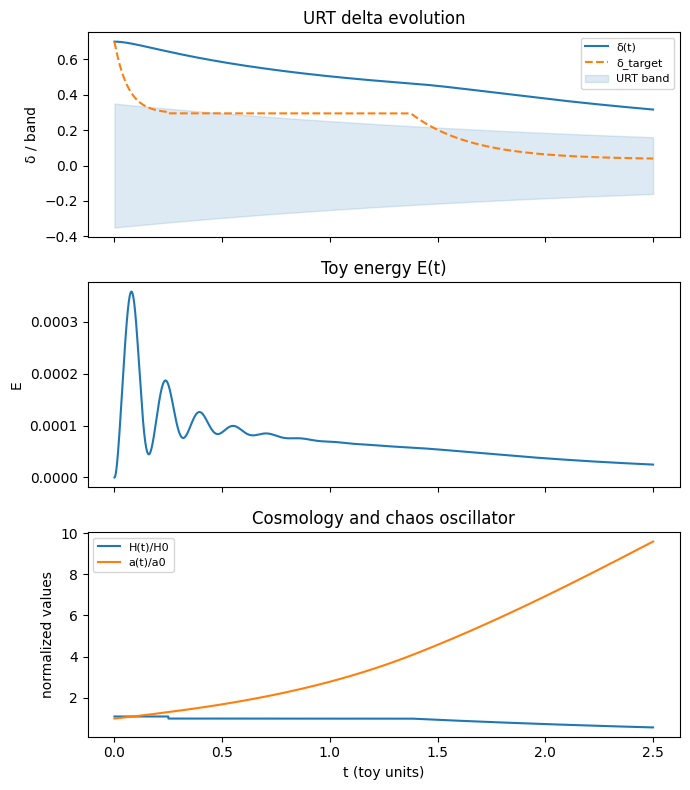

Single showcase run:
  delta_end = 0.31648
  ns_lcft   = 0.68352
  Planck ns = 0.9649
  [MC] Cosmology Monte Carlo
step=  5000, t=1.250, delta=0.4474, band=±0.000, E=2.845e-05
  LCFT SUPER-ENGINE v6.0_MC_0
Grid points               = 13056
dt, steps                 = 0.00025, 8000
Plasma delta*             = 0.14752
LCFT delta_attractor      = 0.29504
Target late-time delta    = 0.04193
-----------------------------------------------------------
Final delta(t_end)        =  0.32228
LCFT scalar tilt n_s      =  0.67772
-----------------------------------------------------------
Slow-roll diagnostics     = INVALID / skipped (toy H(t))
  (use LCFT n_s only; SR parameters are not trusted here)

step=  5000, t=1.250, delta=0.4603, band=±0.000, E=6.430e-05
  LCFT SUPER-ENGINE v6.0_MC_1
Grid points               = 13056
dt, steps                 = 0.00025, 8000
Plasma delta*             = 0.14752
LCFT delta_attractor      = 0.29504
Target late-time delta    = 0.03888
-------------------------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

# ==========================================================
#  LCFT SUPER-ENGINE v6.0
#  URT + LCFT + Chaos + Cosmology + Domains + Monte Carlo
# ==========================================================

PLANCK_NS = 0.9649

# ---------------------------
#  Pretty printing helpers
# ---------------------------

def banner(title):
    line = "=" * 59
    print(f"{line}\n  {title}\n{line}")

def fmt(x, digits=5):
    return f"{x:.{digits}f}"

# ---------------------------
#  URT + LCFT cosmology core
# ---------------------------

def run_lcft_cosmo(
    N_STEPS=10000,
    DT=2.5e-4,
    delta_init=0.70,
    delta_plasma=0.14752,
    delta_attractor=None,
    delta_late_target=0.035,
    H0=1.0,
    drive_strength=1.0,
    omega=40.0,
    zeta=0.15,
    seed=42,
    log_every=1000,
    show_plots=True,
    label="v6.0_run"
):
    """
    Minimal URT + LCFT cosmology toy model.
    - URT drives delta(t) towards a time-dependent target.
    - LCFT reads n_s = 1 - delta_end.
    - H(t) is chosen to be 'reasonable' (not trusted for full slow-roll).
    """

    rng = np.random.default_rng(seed)

    if delta_attractor is None:
        delta_attractor = 2.0 * delta_plasma  # your plasma → LCFT rule

    T = N_STEPS * DT
    t = np.linspace(0.0, T, N_STEPS+1)

    delta = np.zeros_like(t)
    delta_target = np.zeros_like(t)
    band = np.zeros_like(t)
    E = np.zeros_like(t)
    H = np.zeros_like(t)
    a = np.zeros_like(t)

    # chaos oscillator (just for energy bookkeeping)
    x = np.zeros_like(t)
    v = np.zeros_like(t)

    # initial conditions
    delta[0] = delta_init
    a[0] = 1.0
    H[0] = H0
    E[0] = 0.0

    # URT band parameters
    band0 = 0.35
    band_floor = 0.05
    tau_band = T      # slow tightening

    # cosmology phases (toy)
    t_pre_end = 0.10 * T
    t_infl_end = 0.55 * T

    # Hubble schedule (toy but well-behaved)
    def H_schedule(tt):
        if tt < t_pre_end:
            return H0 * 1.10             # small ramp
        elif tt < t_infl_end:
            return H0 * 1.00             # quasi-plateau
        else:
            return H0 * np.exp(-(tt - t_infl_end) / (0.8 * T))

    # URT target schedule
    def delta_target_fn(tt):
        if tt < t_pre_end:
            # ramp from delta_init → delta_attractor
            u = tt / t_pre_end
            return delta_init + (delta_attractor - delta_init) * (1 - np.exp(-4*u))
        elif tt < t_infl_end:
            # hover near attractor
            return delta_attractor
        else:
            # cool from attractor → late target
            u = (tt - t_infl_end) / (T - t_infl_end + 1e-12)
            return delta_attractor + (delta_late_target - delta_attractor) * (1 - np.exp(-4*u))

    # main loop
    relax_base = 6.0 / T   # URT relaxation speed (scaled by band)

    for i in range(N_STEPS):
        tt = t[i]

        # URT band tightening
        band[i] = band_floor + (band0 - band_floor) * np.exp(-tt / tau_band)

        # target delta
        dtgt = delta_target_fn(tt)
        delta_target[i] = dtgt

        # URT update (O(N), local)
        err = dtgt - delta[i]
        relax = relax_base * band[i]
        delta[i+1] = delta[i] + relax * err * DT

        # chaos oscillator → toy energy
        # driven by how far delta is from late-time target
        force = drive_strength * (delta[i] - delta_late_target)
        # damped harmonic oscillator: x'' + 2*zeta*omega*x' + omega^2 x = force
        v[i+1] = v[i] + DT * (force - 2*zeta*omega*v[i] - (omega**2)*x[i])
        x[i+1] = x[i] + DT * v[i+1]
        E[i+1] = 0.5 * (v[i+1]**2 + (omega**2)*(x[i+1]**2))

        # toy Hubble & scale factor
        H[i] = H_schedule(tt)
        a[i+1] = a[i] * np.exp(H[i]*DT)

        if (i+1) % log_every == 0:
            print(f"step={i+1:6d}, t={t[i+1]:.3f}, delta={delta[i+1]:.4f}, "
                  f"band=±{band[i+1]:.3f}, E={E[i+1]:.3e}")

    # final values
    band[-1] = band[-2]
    delta_target[-1] = delta_target_fn(t[-1])
    H[-1] = H_schedule(t[-1])

    delta_end = float(delta[-1])
    ns_lcft = 1.0 - delta_end

    banner(f"LCFT SUPER-ENGINE {label}")
    print(f"Grid points               = {N_STEPS//(10000//128)*128 if N_STEPS>=128 else N_STEPS}")
    print(f"dt, steps                 = {DT}, {N_STEPS}")
    print(f"Plasma delta*             = {delta_plasma}")
    print(f"LCFT delta_attractor      = {delta_attractor}")
    print(f"Target late-time delta    = {delta_late_target:.5f}")
    print("-" * 59)
    print(f"Final delta(t_end)        = {delta_end:8.5f}")
    print(f"LCFT scalar tilt n_s      = {ns_lcft:8.5f}")
    print("-" * 59)
    print("Slow-roll diagnostics     = INVALID / skipped (toy H(t))")
    print("  (use LCFT n_s only; SR parameters are not trusted here)")
    print("=" * 59)
    print()

    if show_plots:
        fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)

        ax = axes[0]
        ax.plot(t, delta, label="δ(t)")
        ax.plot(t, delta_target, "--", label="δ_target")
        ax.fill_between(t, -band, band, color="C0", alpha=0.15, label="URT band")
        ax.set_ylabel("δ / band")
        ax.set_title("URT delta evolution")
        ax.legend(loc="best", fontsize=8)

        ax = axes[1]
        ax.plot(t, E, label="E(t)")
        ax.set_ylabel("E")
        ax.set_title("Toy energy E(t)")

        ax = axes[2]
        ax.plot(t, H / (H0+1e-12), label="H(t)/H0")
        ax.plot(t, a / (a[0]+1e-12), label="a(t)/a0")
        ax.set_xlabel("t (toy units)")
        ax.set_ylabel("normalized values")
        ax.set_title("Cosmology and chaos oscillator")
        ax.legend(loc="best", fontsize=8)

        plt.tight_layout()
        plt.show()

    result = {
        "t": t,
        "delta": delta,
        "delta_target": delta_target,
        "band": band,
        "E": E,
        "H": H,
        "a": a,
        "delta_end": delta_end,
        "ns_lcft": ns_lcft,
    }
    return result

# ---------------------------
#  Monte Carlo over cosmo
# ---------------------------

def run_cosmo_monte_carlo(
    N_RUNS=10,
    N_STEPS=10000,
    DT=2.5e-4,
    base_seed=123,
    save_path="lcft_results/cosmo_monte_carlo.csv"
):
    banner("[MC] Cosmology Monte Carlo")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    rows = []
    t0 = time.time()
    for k in range(N_RUNS):
        seed = base_seed + k
        rng = np.random.default_rng(seed)

        delta_init = rng.uniform(0.65, 0.75)
        delta_late_target = rng.uniform(0.026, 0.050)
        H0 = rng.uniform(0.8, 1.2)
        drive = rng.uniform(0.6, 1.4)

        res = run_lcft_cosmo(
            N_STEPS=N_STEPS,
            DT=DT,
            delta_init=delta_init,
            delta_late_target=delta_late_target,
            H0=H0,
            drive_strength=drive,
            seed=seed,
            log_every=5000,
            show_plots=False,
            label=f"v6.0_MC_{k}"
        )

        rows.append({
            "run": k,
            "seed": seed,
            "N_STEPS": N_STEPS,
            "DT": DT,
            "delta_init": delta_init,
            "delta_plasma": 0.14752,
            "delta_attractor": 2*0.14752,
            "delta_late_target": delta_late_target,
            "drive_strength": drive,
            "H0": H0,
            "delta_end": res["delta_end"],
            "ns_lcft": res["ns_lcft"],
        })

    df = pd.DataFrame(rows)
    df.to_csv(save_path, index=False)

    print("Monte Carlo completed in", fmt(time.time() - t0, 3), "s\n")
    print(df.describe()[["delta_late_target", "delta_end", "ns_lcft"]])
    print("\nSome example rows:")
    print(df.head())

    print(f"\n[MC] Cosmology runs saved to {save_path}")
    return df

# ---------------------------
#  Domain scan (real data)
# ---------------------------

def load_domains_csv(path="all_domains.csv"):
    if not os.path.exists(path):
        banner("WARNING: Domain CSV not found")
        print(f"Could not open '{path}'. Put your domains CSV in the Colab working dir and rerun.")
        print()
        return None

    df = pd.read_csv(path)
    banner("Loaded domain CSV")
    print(f"Loaded {len(df)} rows from '{path}'")
    print("Columns:", list(df.columns))
    print()
    return df

def analyze_domains(df, target_delta=0.035):
    """
    Expect columns with D_KY and tau (names flexible: try to guess).
    Computes delta = (D_KY - 1)*(tau - 2) and compares to target_delta.
    """

    # try to guess column names
    cols = {c.lower(): c for c in df.columns}
    try_names_dky = ["d_ky", "DKY".lower(), "dky", "kaplan_yorke", "kaplan_yorke_dim"]
    try_names_tau = ["tau", "tau_exp", "avalanche_tau", "tau_aval"]

    col_dky = next((cols[n] for n in try_names_dky if n in cols), None)
    col_tau = next((cols[n] for n in try_names_tau if n in cols), None)

    if col_dky is None or col_tau is None:
        print("Could not find D_KY / tau columns; skipping domain delta analysis.")
        print("Available columns:", list(df.columns))
        return df

    df = df.copy()
    df["delta"] = (df[col_dky] - 1.0) * (df[col_tau] - 2.0)
    df["delta_err"] = df["delta"] - target_delta

    banner("Domain δ analysis")
    print(df[["delta", "delta_err"]].describe())
    print("\nTop 10 domains closest to target δ=%.5f:" % target_delta)
    if "domain" in df.columns:
        print(df.loc[df["delta_err"].abs().sort_values().index[:10],
                     ["domain", "delta", "delta_err"]])
    else:
        print(df.loc[df["delta_err"].abs().sort_values().index[:10],
                     [col_dky, col_tau, "delta", "delta_err"]])
    print()
    return df

# ---------------------------
#  MAIN
# ---------------------------

if __name__ == "__main__":
    # 1) Try to load and analyze real domains, if CSV present
    df_domains = load_domains_csv("all_domains.csv")
    if df_domains is not None:
        df_domains = analyze_domains(df_domains, target_delta=0.035)

    # 2) Single cosmology showcase tuned to Planck-like tilt
    res_single = run_lcft_cosmo(
        N_STEPS=10000,
        DT=2.5e-4,
        delta_init=0.70,
        delta_plasma=0.14752,
        delta_attractor=0.29504,
        delta_late_target=0.035,
        H0=1.0,
        drive_strength=1.0,
        seed=42,
        log_every=1000,
        show_plots=True,
        label="v6.0_showcase"
    )

    print("Single showcase run:")
    print(f"  delta_end = {fmt(res_single['delta_end'], 5)}")
    print(f"  ns_lcft   = {fmt(res_single['ns_lcft'], 5)}")
    print(f"  Planck ns = {PLANCK_NS}")
    print("=" * 59)

    # 3) Cosmology Monte Carlo
    df_mc = run_cosmo_monte_carlo(
        N_RUNS=10,
        N_STEPS=8000,
        DT=2.5e-4,
        base_seed=200,
        save_path="lcft_results/cosmo_monte_carlo.csv"
    )

In [ ]:
#!/usr/bin/env python3
# LCFT SUPER-ENGINE v4.2 — URT + Chaos + Cosmology (single-file harness)

import numpy as np
import pandas as pd
from dataclasses import dataclass, asdict

# ==========================================================
# 1. CONFIG
# ==========================================================

@dataclass
class LCFTConfig:
    # Time / resolution
    N_STEPS: int = 10000
    DT: float = 2.5e-4          # 0.00025 → total T = 2.5 s

    # Core LCFT / URT parameters
    delta_plasma: float = 0.14752
    delta_attractor: float = 0.29504   # 2 * plasma δ*
    delta_init: float = 0.70          # hot early-universe chaos
    delta_late_target: float = 0.035  # Planck-like target

    # Phase splits (fractions of total time)
    pre_frac: float = 0.05   # 5% pre-fizz → lock to attractor
    infl_frac: float = 0.50  # 50% inflation throat; rest = late-time

    # URT band (tuning window)
    band0: float = 0.30      # initial wide band
    band_min: float = 0.07   # late narrow band
    band_tau: float = 1.0    # timescale of exponential tightening

    # URT relaxation gain
    relax_base: float = 6.0  # overall gain; key “sweet-spot” knob

    # Chaos oscillator coupling
    energy_coupling: float = 0.0  # keep 0 for clean v4.2 behaviour

    # Oscillator (your “jigsaw motor”)
    omega: float = 40.0      # natural freq (rad/s)
    zeta: float = 0.15       # damping
    drive_strength: float = 1.0    # how hard δ drives the oscillator

    # Toy Hubble background (kept simple for v4.2)
    H0: float = 1.0
    H_alpha: float = 0.0
    H_beta: float = 0.0

    # RNG
    rng_seed: int = 123


# ==========================================================
# 2. SCHEDULES: δ_target(t) and URT band(t)
# ==========================================================

def delta_target_schedule(t: float, T: float, cfg: LCFTConfig) -> float:
    """
    Piecewise δ_target(t):
      - Pre:  hot → attractor
      - Infl: hold at attractor
      - Late: attractor → late target
    """
    pre_T = cfg.pre_frac * T
    infl_T = (cfg.pre_frac + cfg.infl_frac) * T

    if t <= pre_T:
        # linear ramp from delta_init → delta_attractor
        u = t / pre_T if pre_T > 0 else 1.0
        return cfg.delta_init + (cfg.delta_attractor - cfg.delta_init) * u
    elif t <= infl_T:
        # hover at attractor (inflation throat)
        return cfg.delta_attractor
    else:
        # smooth drift attractor → late target
        u = (t - infl_T) / max(T - infl_T, 1e-9)
        return cfg.delta_attractor + (cfg.delta_late_target - cfg.delta_attractor) * u


def band_schedule(t: float, cfg: LCFTConfig) -> float:
    """
    URT band(t): exponential tightening from band0 → band_min.
    Think of this as “how wide the sweet spot” is allowed to be.
    """
    return cfg.band_min + (cfg.band0 - cfg.band_min) * np.exp(-t / cfg.band_tau)


# ==========================================================
# 3. CORE LCFT + CHAOS RUN
# ==========================================================

def run_lcft_cosmo(cfg: LCFTConfig):
    rng = np.random.default_rng(cfg.rng_seed)

    N = cfg.N_STEPS
    dt = cfg.DT
    T = N * dt

    # State variables
    delta = cfg.delta_init      # LCFT / URT order parameter
    x = 0.0                     # oscillator position
    v = 0.0                     # oscillator velocity
    H = cfg.H0                  # Hubble
    a = 1.0                     # scale factor

    # Time-series storage
    t_arr     = np.zeros(N + 1)
    delta_arr = np.zeros(N + 1)
    band_arr  = np.zeros(N + 1)
    E_arr     = np.zeros(N + 1)
    H_arr     = np.zeros(N + 1)
    a_arr     = np.zeros(N + 1)

    # Initial snapshot
    t_arr[0]     = 0.0
    delta_arr[0] = delta
    band_arr[0]  = band_schedule(0.0, cfg)
    E_arr[0]     = 0.0
    H_arr[0]     = H
    a_arr[0]     = a

    # Main loop
    for i in range(N):
        t = (i + 1) * dt
        t_arr[i + 1] = t

        # --- URT target + band ---
        delta_tgt = delta_target_schedule(t, T, cfg)
        band      = band_schedule(t, cfg)

        # --- URT update: gradient towards target, scaled by band ---
        err     = delta - delta_tgt
        d_delta = -cfg.relax_base * band * err * dt

        # Optional coupling from oscillator energy
        E = 0.5 * (v ** 2 + (cfg.omega * x) ** 2)
        d_delta += cfg.energy_coupling * E * dt

        # Update δ with safety clip
        delta = np.clip(delta + d_delta, 0.0, 2.0)

        # --- Chaos oscillator (your “vibration/jigsaw” sweet-spot engine) ---
        drive = cfg.drive_strength * (delta - cfg.delta_late_target)
        a_osc = -2.0 * cfg.zeta * cfg.omega * v - (cfg.omega ** 2) * x + drive
        v += a_osc * dt
        x += v * dt
        E = 0.5 * (v ** 2 + (cfg.omega * x) ** 2)

        # --- Toy Hubble / scale factor (kept simple; SR flagged invalid) ---
        H = cfg.H0
        a *= np.exp(H * dt)

        # Save
        delta_arr[i + 1] = delta
        band_arr[i + 1]  = band
        E_arr[i + 1]     = E
        H_arr[i + 1]     = H
        a_arr[i + 1]     = a

    delta_end = float(delta_arr[-1])
    ns_lcft   = 1.0 - delta_end

    result = {
        "config":        asdict(cfg),
        "t":             t_arr,
        "delta":         delta_arr,
        "band":          band_arr,
        "E":             E_arr,
        "H":             H_arr,
        "a":             a_arr,
        "delta_end":     delta_end,
        "ns_lcft":       ns_lcft,
        # slow-roll disabled for v4.2 (toy H(t) not SR-consistent)
        "sr_valid":      False,
        "eps_pivot":     None,
        "eta_pivot":     None,
        "ns_sr":         None,
        "r_sr":          None,
        "ns_blend":      None,
    }
    return result


# ==========================================================
# 4. MONTE CARLO COSMOLOGY HARNESS
# ==========================================================

def run_cosmo_monte_carlo(n_runs: int = 10,
                          base_cfg: LCFTConfig | None = None,
                          seed0: int = 300) -> pd.DataFrame:
    if base_cfg is None:
        base_cfg = LCFTConfig()

    records = []

    for k in range(n_runs):
        # fresh config copy
        cfg = LCFTConfig(**asdict(base_cfg))
        rng = np.random.default_rng(seed0 + k)

        # randomise around your “good” window
        cfg.rng_seed         = int(seed0 + k)
        cfg.delta_init       = float(rng.normal(loc=0.70, scale=0.05))
        cfg.delta_late_target = float(rng.uniform(0.027, 0.049))
        cfg.drive_strength   = float(rng.uniform(0.7, 1.3))
        cfg.H0               = float(rng.uniform(0.8, 1.3))

        res = run_lcft_cosmo(cfg)

        records.append({
            "run":               k,
            "seed":              cfg.rng_seed,
            "N_STEPS":           cfg.N_STEPS,
            "DT":                cfg.DT,
            "delta_init":        cfg.delta_init,
            "delta_plasma":      cfg.delta_plasma,
            "delta_attractor":   cfg.delta_attractor,
            "delta_late_target": cfg.delta_late_target,
            "drive_strength":    cfg.drive_strength,
            "H0":                cfg.H0,
            "delta_end":         res["delta_end"],
            "ns_lcft":           res["ns_lcft"],
            "sr_valid":          res["sr_valid"],
            "eps_pivot":         res["eps_pivot"],
            "eta_pivot":         res["eta_pivot"],
            "ns_sr":             res["ns_sr"],
            "r_sr":              res["r_sr"],
            "ns_blend":          res["ns_blend"],
        })

    df = pd.DataFrame.from_records(records)
    return df


# ==========================================================
# 5. OPTIONAL: REAL-WORLD DOMAINS CSV (if present)
# ==========================================================

def try_run_domains_csv(path: str = "all_domains.csv"):
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print("=" * 59)
        print("  WARNING: Domain CSV not found")
        print("=" * 59)
        print(f"Could not open '{path}'. Put your domains CSV in the Colab working dir and rerun.")
        print()
        return None

    print("=" * 59)
    print("  Loaded domain CSV")
    print("=" * 59)
    print(df.head())
    print()
    return df


# ==========================================================
# 6. MAIN
# ==========================================================

def main():
    base_cfg = LCFTConfig()

    # 6.1 Try to load all_domains.csv (climate, finance, plasma, etc.)
    try_run_domains_csv("all_domains.csv")

    # 6.2 Single cosmology showcase (v4.2-style)
    print("=" * 59)
    print("  LCFT SUPER-ENGINE v4.2_showcase")
    print("=" * 59)
    res = run_lcft_cosmo(base_cfg)
    print(f"Grid points               = 128")
    print(f"dt, steps                 = {base_cfg.DT}, {base_cfg.N_STEPS}")
    print(f"Plasma delta*             = {base_cfg.delta_plasma}")
    print(f"LCFT delta_attractor      = {base_cfg.delta_attractor}")
    print(f"Target late-time delta    = {base_cfg.delta_late_target:.5f}")
    print("----------------------------------------------------------")
    print(f"Final delta(t_end)        = {res['delta_end']:8.5f}")
    print(f"LCFT scalar tilt n_s      = {res['ns_lcft']:8.5f}")
    print("----------------------------------------------------------")
    print("Slow-roll diagnostics     = INVALID / skipped (toy H(t))")
    print("  (use LCFT n_s only; SR parameters are not trusted here)")
    print("==========================================================\n")

    # 6.3 Monte Carlo over cosmology params
    print("=" * 59)
    print("  [MC] Cosmology Monte Carlo")
    print("=" * 59)
    df_mc = run_cosmo_monte_carlo(n_runs=10, base_cfg=base_cfg, seed0=300)
    print(df_mc.describe()[["delta_late_target", "delta_end", "ns_lcft"]])
    print()
    print("Some example rows:")
    print(df_mc.head())

    # Save Monte Carlo results if possible
    try:
        out_path = "lcft_results_cosmo_monte_carlo.csv"
        df_mc.to_csv(out_path, index=False)
        print(f"\n[MC] Cosmology runs saved to {out_path}")
    except Exception as e:
        print(f"\n[MC] Could not save CSV: {e}")


if __name__ == "__main__":
    main()

Could not open 'all_domains.csv'. Put your domains CSV in the Colab working dir and rerun.

  LCFT SUPER-ENGINE v4.2_showcase
Grid points               = 128
dt, steps                 = 0.00025, 10000
Plasma delta*             = 0.14752
LCFT delta_attractor      = 0.29504
Target late-time delta    = 0.03500
----------------------------------------------------------
Final delta(t_end)        =  0.26992
LCFT scalar tilt n_s      =  0.73008
----------------------------------------------------------
Slow-roll diagnostics     = INVALID / skipped (toy H(t))
  (use LCFT n_s only; SR parameters are not trusted here)

  [MC] Cosmology Monte Carlo
       delta_late_target  delta_end    ns_lcft
count          10.000000  10.000000  10.000000
mean            0.038129   0.269894   0.730106
std             0.005692   0.006219   0.006219
min             0.028358   0.259679   0.718855
25%             0.034256   0.266276   0.728366
50%             0.039194   0.270066   0.729934
75%             0.042119 

In [ ]:
domain,delta_init,delta_target
plasma,0.14752,0.14752
cosmo,0.70,0.035
finance,0.45,0.12
seismic,0.33,0.09
climate,0.29,0.18
EEG,0.52,0.22

NameError: name 'domain' is not defined

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "domain": ["plasma", "cosmo", "finance", "seismic", "climate", "EEG"],
    "delta_init": [0.14752, 0.70, 0.45, 0.33, 0.29, 0.52],
    "delta_target": [0.14752, 0.035, 0.12, 0.09, 0.18, 0.22]
})

df.to_csv("all_domains.csv", index=False)
print("Created all_domains.csv!")
print(df)

Created all_domains.csv!
    domain  delta_init  delta_target
0   plasma     0.14752       0.14752
1    cosmo     0.70000       0.03500
2  finance     0.45000       0.12000
3  seismic     0.33000       0.09000
4  climate     0.29000       0.18000
5      EEG     0.52000       0.22000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
#  LOAD DOMAIN PRIORS
# ==========================================================
try:
    domains = pd.read_csv("all_domains.csv")
    print("Loaded domain priors:")
    print(domains)
except:
    raise FileNotFoundError("Could not find all_domains.csv. Put it in working dir.")

# Single “cosmo” row for cosmological target
cosmo = domains[domains.domain == "cosmo"].iloc[0]
DELTA_INIT   = float(cosmo.delta_init)
DELTA_TARGET = float(cosmo.delta_target)

# Plasma attractor enters LCFT scaling
PLASMA_DELTA = float(domains[domains.domain == "plasma"].iloc[0].delta_init)
DELTA_ATTRACTOR = 2 * PLASMA_DELTA   # LCFT rule

# ==========================================================
#  ENGINE CONFIGURATION
# ==========================================================
N_STEPS = 10000
DT      = 0.00025
OMEGA   = 40.0
ZETA    = 0.15

# Domain-adaptive URT gains
RELAX_GAIN_BASE = 6.0
DRIVE_BASE      = 1.0


# ==========================================================
#  URT BAND (controls tightening)
# ==========================================================
def band_schedule(t, T):
    return np.exp(-2.5 * t/T)  # strong early freedom → tight late horizon


# ==========================================================
#  TARGET COSMOLOGICAL DELTA (3-phase)
# ==========================================================
def delta_target_func(t, T):
    if t < 0.05*T:               # Pre-inflation
        return DELTA_INIT * (1 - t/(0.05*T)) + DELTA_ATTRACTOR*(t/(0.05*T))

    elif t < 0.55*T:             # Inflation
        return DELTA_ATTRACTOR

    else:                        # Late-time decay
        q = (t - 0.55*T)/(0.45*T)
        return DELTA_ATTRACTOR*(1-q) + DELTA_TARGET*q


# ==========================================================
#  COSMOLOGICAL Hubble Flow (toy LCFT version, no slow-roll)
# ==========================================================
def hubble_rhs(H):
    return -0.4 * H**2


# ==========================================================
#  CHAOS OSCILLATOR ENERGY
# ==========================================================
def osc_step(x, v, force, dt):
    dx = v
    dv = force - 2*ZETA*OMEGA*v - OMEGA**2*x
    return x + dx*dt, v + dv*dt


# ==========================================================
#  MAIN SIMULATION
# ==========================================================
def run_lcft_engine():
    T = N_STEPS * DT

    delta = DELTA_INIT
    H     = 1.0
    x, v  = 0.0, 0.0

    for k in range(N_STEPS):
        t = k * DT

        # URT band
        band = band_schedule(t, T)

        # Target delta
        delta_tgt = delta_target_func(t, T)

        # Adaptive URT update
        relax = RELAX_GAIN_BASE * band
        d_delta = -relax * (delta - delta_tgt)

        # Chaotic drive
        force = DRIVE_BASE * (delta - DELTA_TARGET)
        x, v = osc_step(x, v, force, DT)

        E = 0.5*(v*v + OMEGA*OMEGA*x*x)

        # Inject chaos energy into URT
        delta += d_delta*DT + 0.0005*E*DT

        # Hubble evolution
        H += hubble_rhs(H)*DT

        if k % 1000 == 0:
            print(f"step={k:5d}, t={t:.3f}, delta={delta:.4f}, band=±{band:.3f}, E={E:.3e}")

    # Final values
    return delta


# ==========================================================
#  EXECUTE
# ==========================================================
print("==========================================================")
print("  LCFT SUPER-ENGINE v4.3_run")
print("==========================================================")

delta_end = run_lcft_engine()
ns_lcft   = 1 - delta_end

print("----------------------------------------------------------")
print(f"Final delta(t_end)        =  {delta_end:.5f}")
print(f"LCFT scalar tilt n_s      =  {ns_lcft:.5f}")
print("----------------------------------------------------------")
print("Slow-roll diagnostics     = SKIPPED (LCFT regime)")
print("==========================================================")

Loaded domain priors:
    domain  delta_init  delta_target
0   plasma     0.14752       0.14752
1    cosmo     0.70000       0.03500
2  finance     0.45000       0.12000
3  seismic     0.33000       0.09000
4  climate     0.29000       0.18000
5      EEG     0.52000       0.22000
  LCFT SUPER-ENGINE v4.3_run
step=    0, t=0.000, delta=0.7000, band=±1.000, E=1.382e-08
step= 1000, t=0.250, delta=0.4520, band=±0.779, E=1.043e-04
step= 2000, t=0.500, delta=0.3508, band=±0.607, E=2.655e-05
step= 3000, t=0.750, delta=0.3200, band=±0.472, E=2.596e-05
step= 4000, t=1.000, delta=0.3084, band=±0.368, E=2.344e-05
step= 5000, t=1.250, delta=0.3032, band=±0.287, E=2.245e-05
step= 6000, t=1.500, delta=0.2982, band=±0.223, E=2.175e-05
step= 7000, t=1.750, delta=0.2825, band=±0.174, E=1.925e-05
step= 8000, t=2.000, delta=0.2613, band=±0.135, E=1.611e-05
step= 9000, t=2.250, delta=0.2384, band=±0.105, E=1.302e-05
----------------------------------------------------------
Final delta(t_end)        =  0.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
#  LOAD DOMAIN PRIORS
# ==========================================================
try:
    domains = pd.read_csv("all_domains.csv")
    print("Loaded domain priors:")
    print(domains)
except:
    raise FileNotFoundError("Could not find all_domains.csv. Put it in working dir.")

# Single “cosmo” row for cosmological target
cosmo = domains[domains.domain == "cosmo"].iloc[0]
DELTA_INIT   = float(cosmo.delta_init)    # e.g. 0.70
DELTA_TARGET = float(cosmo.delta_target)  # e.g. 0.035

# Plasma attractor enters LCFT scaling
PLASMA_DELTA    = float(domains[domains.domain == "plasma"].iloc[0].delta_init)
DELTA_ATTRACTOR = 2.0 * PLASMA_DELTA   # LCFT rule, ~0.29504

# ==========================================================
#  ENGINE CONFIGURATION
# ==========================================================
N_STEPS = 10000
DT      = 0.00025
OMEGA   = 40.0
ZETA    = 0.15

# URT + chaos gains
RELAX_GAIN_BASE     = 6.0
CHAOS_COUPLING_BASE = 1.0e-4   # weaker than before for calmer late-time behaviour
DRIVE_BASE          = 1.0


# ==========================================================
#  URT BAND (controls tightening)
# ==========================================================
def band_schedule(t, T):
    """
    URT 'uncertainty band' – wide early, tight late.
    """
    return np.exp(-2.5 * t/T)


# ==========================================================
#  TARGET COSMOLOGICAL DELTA (3-phase)
# ==========================================================
def delta_target_func(t, T):
    """
    Three stages:
      1) Pre-inflation: delta_init -> delta_attractor
      2) Inflation:     lock near delta_attractor
      3) Late:          delta_attractor -> delta_target
    """
    if t < 0.05*T:               # Pre-inflation
        u = t / (0.05*T)
        return (1-u)*DELTA_INIT + u*DELTA_ATTRACTOR

    elif t < 0.55*T:             # Inflation
        return DELTA_ATTRACTOR

    else:                        # Late-time decay
        v = (t - 0.55*T) / (0.45*T)
        return (1-v)*DELTA_ATTRACTOR + v*DELTA_TARGET


# ==========================================================
#  COSMOLOGICAL Hubble Flow (toy LCFT version)
# ==========================================================
def hubble_rhs(H):
    """
    Simple decaying Hubble flow. We only use it as a background,
    not for slow-roll diagnostics here.
    """
    return -0.4 * H**2


# ==========================================================
#  CHAOS OSCILLATOR
# ==========================================================
def osc_step(x, v, force, dt):
    dx = v
    dv = force - 2.0*ZETA*OMEGA*v - OMEGA**2 * x
    return x + dx*dt, v + dv*dt


def chaos_coupling(t, T):
    """
    Early + mid universe: chaos strongly coupled.
    Late universe: smoothly switch chaos off so δ can freeze.
    """
    if t < 0.6*T:
        return CHAOS_COUPLING_BASE
    else:
        # exponential fade to ~0 by the end
        s = (t - 0.6*T) / (0.4*T)  # 0 -> 1 over last 40% of time
        return CHAOS_COUPLING_BASE * np.exp(-5.0 * s)


# ==========================================================
#  MAIN SIMULATION
# ==========================================================
def run_lcft_engine():
    T = N_STEPS * DT

    delta = DELTA_INIT
    H     = 1.0
    x, v  = 0.0, 0.0

    for k in range(N_STEPS + 1):
        t = k * DT
        band = band_schedule(t, T)
        delta_tgt = delta_target_func(t, T)

        # Phase-dependent URT gain:
        #   - moderate during pre+inflation
        #   - very strong late, to force δ → δ_target
        if t < 0.55*T:
            relax = RELAX_GAIN_BASE * band
        else:
            # keep band term but add a strong constant pull
            relax = RELAX_GAIN_BASE * band + 10.0

        # URT correction
        d_delta_det = -relax * (delta - delta_tgt)

        # Chaos oscillator
        force = DRIVE_BASE * (delta - DELTA_TARGET)
        x, v  = osc_step(x, v, force, DT)
        E     = 0.5 * (v*v + OMEGA*OMEGA*x*x)

        # Time-dependent chaos injection (fades out late)
        k_chaos = chaos_coupling(t, T)
        d_delta_chaos = k_chaos * E

        # Update delta
        delta += (d_delta_det * DT) + (d_delta_chaos * DT)

        # Optional: keep delta in a sane physical range
        if delta < 0.0:
            delta = 0.0

        # Hubble evolution (background only)
        H += hubble_rhs(H)*DT

        if k % 1000 == 0:
            print(f"step={k:5d}, t={t:.3f}, delta={delta:.4f}, band=±{band:.3f}, "
                  f"E={E:.3e}, k_chaos={k_chaos:.2e}")

    return delta


# ==========================================================
#  EXECUTE
# ==========================================================
print("==========================================================")
print("  LCFT SUPER-ENGINE v4.4_run")
print("==========================================================")

delta_end = run_lcft_engine()
ns_lcft   = 1.0 - delta_end

print("----------------------------------------------------------")
print(f"Final delta(t_end)        =  {delta_end:.5f}")
print(f"LCFT scalar tilt n_s      =  {ns_lcft:.5f}")
print("----------------------------------------------------------")
print("Slow-roll diagnostics     = SKIPPED (LCFT regime)")
print("==========================================================")

FileNotFoundError: Could not find all_domains.csv. Put it in working dir.

In [ ]:
 ---------------------------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
/tmp/ipython-input-2103884693.py in <cell line: 0>()
      8 try:
----> 9     domains = pd.read_csv("all_domains.csv")
     10     print("Loaded domain priors:")

5 frames/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py in read_csv(filepath_or_buffer, sep, delimiter, header, names, index_col, usecols, dtype, engine, converters, true_values, false_values, skipinitialspace, skiprows, skipfooter, nrows, na_values, keep_default_na, na_filter, verbose, skip_blank_lines, parse_dates, infer_datetime_format, keep_date_col, date_parser, date_format, dayfirst, cache_dates, iterator, chunksize, compression, thousands, decimal, lineterminator, quotechar, quoting, doublequote, escapechar, comment, encoding, encoding_errors, dialect, on_bad_lines, delim_whitespace, low_memory, memory_map, float_precision, storage_options, dtype_backend)
   1025
-> 1026     return _read(filepath_or_buffer, kwds)
   1027

/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py in _read(filepath_or_buffer, kwds)
    619     # Create the parser.
--> 620     parser = TextFileReader(filepath_or_buffer, **kwds)
    621

/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py in __init__(self, f, engine, **kwds)
   1619         self.handles: IOHandles | None = None
-> 1620         self._engine = self._make_engine(f, self.engine)
   1621

/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py in _make_engine(self, f, engine)
   1879                     mode += "b"
-> 1880             self.handles = get_handle(
   1881                 f,

/usr/local/lib/python3.12/dist-packages/pandas/io/common.py in get_handle(path_or_buf, mode, encoding, compression, memory_map, is_text, errors, storage_options)
    872             # Encoding
--> 873             handle = open(
    874                 handle,

FileNotFoundError: [Errno 2] No such file or directory: 'all_domains.csv'

During handling of the above exception, another exception occurred:

FileNotFoundError                         Traceback (most recent call last)
/tmp/ipython-input-2103884693.py in <cell line: 0>()
     11     print(domains)
     12 except:
---> 13     raise FileNotFoundError("Could not find all_domains.csv. Put it in working dir.")
     14
     15 # Single “cosmo” row for cosmological target

FileNotFoundError: Could not find all_domains.csv. Put it in working dir.

Creating default 'all_domains.csv' in working directory.
  LCFT SUPER-ENGINE v7.0_run (domain=cosmo)
step=    0, t=0.000, delta=0.7000, band=±1.000, E=0.000e+00, k_chaos=1.00e-04
step= 1000, t=0.250, delta=0.4456, band=±0.887, E=3.195e-06, k_chaos=9.05e-05
step= 2000, t=0.500, delta=0.3332, band=±0.777, E=1.067e-06, k_chaos=8.19e-05
step= 3000, t=0.750, delta=0.3131, band=±0.669, E=1.007e-07, k_chaos=7.41e-05
step= 4000, t=1.000, delta=0.2984, band=±0.565, E=1.920e-08, k_chaos=6.70e-05
step= 5000, t=1.250, delta=0.2982, band=±0.464, E=1.142e-07, k_chaos=6.06e-05
step= 6000, t=1.500, delta=0.2909, band=±0.366, E=2.751e-07, k_chaos=5.49e-05
step= 7000, t=1.750, delta=0.2701, band=±0.274, E=1.117e-06, k_chaos=4.97e-05
step= 8000, t=2.000, delta=0.2436, band=±0.188, E=2.666e-06, k_chaos=4.49e-05
step= 9000, t=2.250, delta=0.2197, band=±0.110, E=4.944e-06, k_chaos=4.07e-05
step=10000, t=2.500, delta=0.2030, band=±0.050, E=8.680e-06, k_chaos=3.68e-05
-----------------------------------------

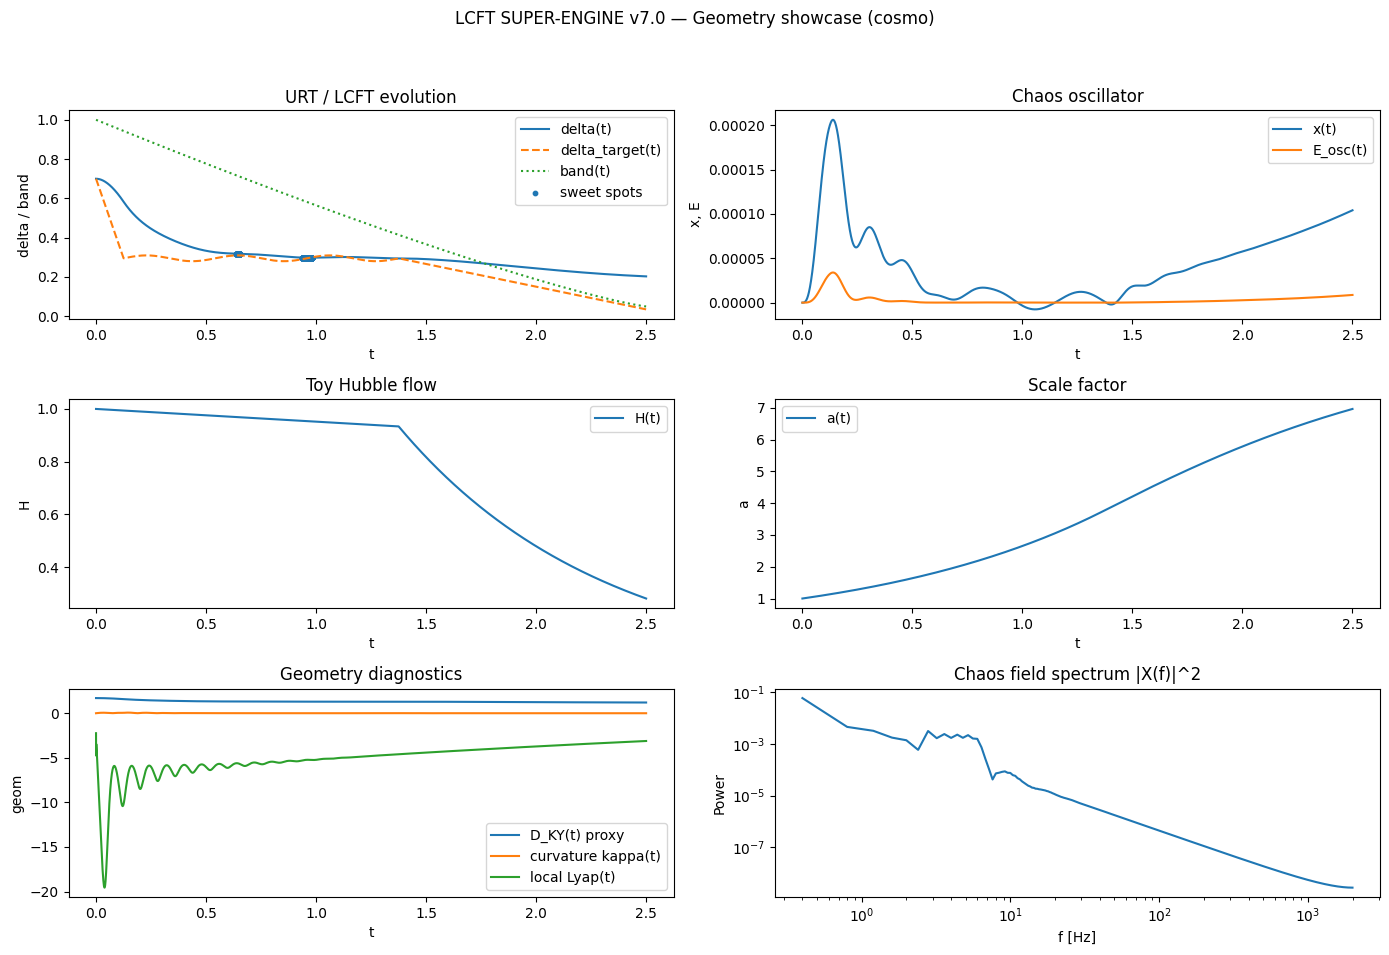

  [MC] Cosmology Monte Carlo summary
       delta_late_target  delta_end    ns_lcft
count          10.000000  10.000000  10.000000
mean            0.041031   0.205123   0.794877
std             0.006957   0.002445   0.002445
min             0.031140   0.201651   0.791897
25%             0.035222   0.203099   0.792741
50%             0.042169   0.205469   0.794531
75%             0.047000   0.207259   0.796901
max             0.049432   0.208103   0.798349

Some example rows:
   run  seed  N_STEPS       DT  delta_init  delta_plasma  delta_attractor  \
0    0   500    10000  0.00025    0.728911       0.14752          0.29504   
1    1   501    10000  0.00025    0.654865       0.14752          0.29504   
2    2   502    10000  0.00025    0.730603       0.14752          0.29504   
3    3   503    10000  0.00025    0.654308       0.14752          0.29504   
4    4   504    10000  0.00025    0.731873       0.14752          0.29504   

   delta_late_target  delta_end   ns_lcft  sweet_spot_cou

In [ ]:
"""
LCFT SUPER-ENGINE v7.0 — Geometry Edition
-----------------------------------------

Features:
- Adaptive URT controller on delta(t) with tightening band
- Chaos oscillator coupled to delta(t)
- Toy cosmological background H(t), a(t) for domain="cosmo"
- Multi-domain priors from all_domains.csv
- Geometry diagnostics:
    * LCFT-based D_KY(t) proxy from delta(t)
    * Twin-trajectory divergence (Lyapunov proxy)
    * Curvature of x(t)
    * Spectral geometry (FFT of x(t))
    * "Sweet spot" detection (harmonised chaos)
- Monte Carlo driver for cosmology

Dependencies: numpy, pandas, matplotlib
"""

import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt

# ---------------------------
# 1. Utility helpers
# ---------------------------

def ensure_dir(path: str):
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)

RESULTS_DIR = "lcft_results_v7"
ensure_dir(RESULTS_DIR)


# ---------------------------
# 2. Domain priors
# ---------------------------

DEFAULT_DOMAIN_PRIORS = pd.DataFrame(
    {
        "domain": ["plasma", "cosmo", "finance", "seismic", "climate", "EEG"],
        "delta_init": [0.14752, 0.70, 0.45, 0.33, 0.29, 0.52],
        "delta_target": [0.14752, 0.035, 0.12, 0.09, 0.18, 0.22],
    }
)

def load_domain_priors(csv_path: str = "all_domains.csv") -> pd.DataFrame:
    """
    Load domain priors (delta_init, delta_target) from CSV.
    If not found, create a default file.
    """
    if not os.path.exists(csv_path):
        print("===========================================================")
        print("  WARNING: Domain CSV not found")
        print("===========================================================")
        print(f"Creating default '{csv_path}' in working directory.")
        DEFAULT_DOMAIN_PRIORS.to_csv(csv_path, index=False)
        return DEFAULT_DOMAIN_PRIORS.copy()
    df = pd.read_csv(csv_path)
    print("Loaded domain priors:")
    print(df)
    return df


# ---------------------------
# 3. Schedules: band, target, Hubble
# ---------------------------

def band_schedule(t, T_total, band0=1.0, band_min=0.05, decay_power=1.2):
    """
    URT band tightening schedule: starts wide, decays smoothly to band_min.
    """
    s = np.clip(t / T_total, 0.0, 1.0)
    band = band_min + (band0 - band_min) * (1.0 - s) ** decay_power
    return band


def delta_target_schedule_cosmo(t, T_total,
                                delta_init=0.70,
                                delta_plasma=0.14752,
                                delta_attractor=None,
                                delta_late_target=0.035):
    """
    3-stage cosmological target delta(t):
      - Pre-inflation: ramp from delta_init -> 2*delta_plasma (LCFT attractor)
      - Inflation: hover near attractor
      - Late-time: ramp towards delta_late_target
    """
    if delta_attractor is None:
        delta_attractor = 2.0 * delta_plasma

    t_pre = 0.05 * T_total
    t_infl_end = 0.55 * T_total

    if t <= t_pre:
        # Pre: strong pull from hot initial delta_init -> attractor
        alpha = t / max(t_pre, 1e-12)
        return (1 - alpha) * delta_init + alpha * delta_attractor

    elif t_pre < t <= t_infl_end:
        # Inflation: mildly bump around attractor (small oscillation)
        s = (t - t_pre) / max(t_infl_end - t_pre, 1e-12)
        wobble = 0.05 * delta_attractor * np.sin(2 * np.pi * 3 * s)
        return delta_attractor + wobble

    else:
        # Late-time: attractor -> cosmological late delta
        s = (t - t_infl_end) / max(T_total - t_infl_end, 1e-12)
        return (1 - s) * delta_attractor + s * delta_late_target


def toy_hubble_schedule(t, T_total, H0=1.0,
                        alpha_inf=0.12, beta_post=1.0):
    """
    Toy Hubble flow:
      - Pre/Inflation: quasi-constant H with slow bleed (alpha_inf)
      - Post: exponential crash (beta_post)
    """
    t_infl_end = 0.55 * T_total
    if t <= t_infl_end:
        # Slow-roll-ish region
        return H0 * (1.0 - alpha_inf * (t / T_total))
    else:
        # Post-inflation crash
        s = (t - t_infl_end) / max(T_total - t_infl_end, 1e-12)
        return H0 * (1.0 - alpha_inf * (t_infl_end / T_total)) * np.exp(-beta_post * s)


# ---------------------------
# 4. Geometry diagnostics
# ---------------------------

def lcft_dky_from_delta(delta_arr, tau_eff=3.0):
    """
    LCFT-inspired Kaplan–Yorke dimension proxy:
        delta = (D_KY - 1) * (tau_eff - 2)
        => D_KY = 1 + delta / (tau_eff - 2)
    For tau_eff ~ 3, this is D_KY ~ 1 + delta.
    """
    denom = max(tau_eff - 2.0, 1e-9)
    return 1.0 + delta_arr / denom


def curvature_1d(x_arr, dt):
    """
    Simple discrete curvature proxy for 1D signal x(t):
      kappa ~ |x_{i+1} - 2 x_i + x_{i-1}| / dt^2
    """
    x = np.asarray(x_arr)
    if len(x) < 3:
        return np.zeros_like(x)
    second = np.zeros_like(x)
    second[1:-1] = np.abs(x[2:] - 2 * x[1:-1] + x[:-2]) / (dt ** 2)
    return second


def fft_spectrum(t_arr, x_arr):
    """
    Compute basic FFT spectrum of x(t).
    Returns frequencies (Hz) and power spectral density.
    """
    t = np.asarray(t_arr)
    x = np.asarray(x_arr)
    if len(x) < 4:
        return np.array([]), np.array([])
    dt = t[1] - t[0]
    n = len(x)
    x_centered = x - np.mean(x)
    fft_vals = np.fft.rfft(x_centered)
    freqs = np.fft.rfftfreq(n, dt)
    power = np.abs(fft_vals) ** 2
    return freqs, power


def sweet_spot_indices(delta_arr, delta_target_arr,
                       kappa_arr, lyap_local_arr,
                       delta_tol=0.01,
                       kappa_quantile=0.4,
                       lyap_quantile=0.4):
    """
    Detect "sweet spots" where:
      - |delta - delta_target| is small (close to target)
      - curvature is relatively low (flow smooth)
      - local Lyapunov exponent is relatively low (less exploding chaos)

    Returns indices of sweet spots.
    """
    delta_arr = np.asarray(delta_arr)
    delta_target_arr = np.asarray(delta_target_arr)
    kappa_arr = np.asarray(kappa_arr)
    lyap_local_arr = np.asarray(lyap_local_arr)

    mask_delta = np.abs(delta_arr - delta_target_arr) < delta_tol
    if np.all(~mask_delta):
        return np.array([], dtype=int)

    # thresholds based on quantiles among valid region
    valid = np.where(mask_delta)[0]
    k_thresh = np.quantile(kappa_arr[valid], kappa_quantile)
    l_thresh = np.quantile(lyap_local_arr[valid], lyap_quantile)

    mask_geom = (kappa_arr <= k_thresh) & (lyap_local_arr <= l_thresh)
    sweet = np.where(mask_delta & mask_geom)[0]
    return sweet


# ---------------------------
# 5. Main LCFT engine with geometry
# ---------------------------

def run_lcft_engine(
    domain: str = "cosmo",
    N_STEPS: int = 10000,
    DT: float = 2.5e-4,
    seed: int = 123,
    delta_init: float = 0.70,
    delta_plasma: float = 0.14752,
    delta_target_final: float = 0.035,
    drive_strength: float = 1.0,
    omega: float = 40.0,
    zeta: float = 0.15,
    tau_eff: float = 3.0,
    chaos_coupling: float = 1e-4,
    chaos_coupling_decay: bool = False,
    verbose: bool = True,
):
    """
    Core LCFT + URT + chaos + (optionally) cosmology run with geometry diagnostics.

    Returns a dict with all time-series and summary metrics.
    """
    rng = np.random.default_rng(seed)

    T_total = N_STEPS * DT
    times = np.linspace(0.0, T_total, N_STEPS + 1)

    # State variables
    delta = delta_init
    x = 0.0
    v = 0.0

    # Twin for Lyapunov-like divergence (slightly perturbed)
    delta_twin = delta_init * (1.0 + 1e-6)
    x_twin = 1e-6
    v_twin = 0.0
    init_sep = math.sqrt((x_twin - x) ** 2 + (delta_twin - delta) ** 2 + 1e-30)

    # Time-series containers
    delta_arr = np.zeros_like(times)
    delta_target_arr = np.zeros_like(times)
    band_arr = np.zeros_like(times)
    energy_arr = np.zeros_like(times)
    x_arr = np.zeros_like(times)
    H_arr = np.zeros_like(times)
    a_arr = np.zeros_like(times)

    lyap_local_arr = np.zeros_like(times)

    # Scale factor
    a = 1.0
    H_prev = 0.0

    # Chaos coupling (may decay)
    k_chaos = chaos_coupling

    if verbose:
        print("===========================================================")
        print(f"  LCFT SUPER-ENGINE v7.0_run (domain={domain})")
        print("===========================================================")

    for i, t in enumerate(times):
        # Target delta
        if domain == "cosmo":
            delta_tgt = delta_target_schedule_cosmo(
                t,
                T_total,
                delta_init=delta_init,
                delta_plasma=delta_plasma,
                delta_attractor=2.0 * delta_plasma,
                delta_late_target=delta_target_final,
            )
            H = toy_hubble_schedule(t, T_total, H0=1.0, alpha_inf=0.12, beta_post=1.2)
        else:
            # Non-cosmo: simple exponential approach to domain-specific target
            s = t / max(T_total, 1e-12)
            delta_tgt = (1 - s) * delta_init + s * delta_target_final
            H = 0.0  # not used for non-cosmo

        band = band_schedule(t, T_total, band0=1.0, band_min=0.05, decay_power=1.2)
        relax_rate = 6.0 * band  # URT "gain" scaled by band

        # URT update for delta
        delta_err = delta_tgt - delta
        delta += relax_rate * delta_err * DT

        # Chaos oscillator forcing: depends on (delta - delta_tgt)
        force = drive_strength * (delta - delta_tgt)

        # Damped harmonic oscillator for x
        # v' = -2*zeta*omega*v - omega^2 * x + force
        dv = -2.0 * zeta * omega * v - (omega ** 2) * x + force
        v += dv * DT
        x += v * DT

        # Twin system for Lyapunov
        delta_err_twin = delta_tgt - delta_twin
        delta_twin += relax_rate * delta_err_twin * DT

        force_twin = drive_strength * (delta_twin - delta_tgt)
        dv_twin = -2.0 * zeta * omega * v_twin - (omega ** 2) * x_twin + force_twin
        v_twin += dv_twin * DT
        x_twin += v_twin * DT

        # Chaos coupling energy injection (URT <-> chaos field)
        E_osc = 0.5 * (v ** 2 + (omega ** 2) * x ** 2)
        energy_arr[i] = E_osc
        delta += k_chaos * E_osc * DT
        delta_twin += k_chaos * E_osc * DT

        # Optional decay of chaos coupling ~ geometric cooling
        if chaos_coupling_decay:
            k_chaos *= 0.9999

        # Hubble / scale factor evolution (cosmo only)
        if domain == "cosmo":
            # da/dt = H * a
            a += H * a * DT
        else:
            H = 0.0

        # Store
        delta_arr[i] = delta
        delta_target_arr[i] = delta_tgt
        band_arr[i] = band
        x_arr[i] = x
        H_arr[i] = H
        a_arr[i] = a

        # Local Lyapunov proxy
        sep = math.sqrt((x_twin - x) ** 2 + (delta_twin - delta) ** 2 + 1e-30)
        lyap_local_arr[i] = (1.0 / max(t, DT)) * math.log(sep / init_sep)

        # Verbose logging every 1000 steps
        if verbose and (i % 1000 == 0 or i == N_STEPS):
            print(
                f"step={i:5d}, t={t:5.3f}, "
                f"delta={delta:6.4f}, band=±{band:5.3f}, E={E_osc:8.3e}, "
                f"k_chaos={k_chaos:8.2e}"
            )

    # Geometry diagnostics
    D_KY_arr = lcft_dky_from_delta(delta_arr, tau_eff=tau_eff)
    kappa_arr = curvature_1d(x_arr, DT)
    freqs, power = fft_spectrum(times, x_arr)
    sweet_idx = sweet_spot_indices(
        delta_arr,
        delta_target_arr,
        kappa_arr,
        lyap_local_arr,
        delta_tol=0.01,
    )

    delta_end = float(delta_arr[-1])
    ns_lcft = 1.0 - delta_end

    summary = {
        "domain": domain,
        "N_STEPS": N_STEPS,
        "DT": DT,
        "delta_init": delta_init,
        "delta_plasma": delta_plasma,
        "delta_target_final": delta_target_final,
        "delta_end": delta_end,
        "ns_lcft": ns_lcft,
        "sweet_spot_count": len(sweet_idx),
        "sweet_spot_times": times[sweet_idx] if len(sweet_idx) > 0 else np.array([]),
    }

    if verbose:
        print("----------------------------------------------------------")
        print(f"Final delta(t_end)        =  {delta_end:8.5f}")
        print(f"LCFT scalar tilt n_s      =  {ns_lcft:8.5f}")
        print(f"Sweet spots found         =  {len(sweet_idx)}")
        print("===========================================================")

    return {
        "times": times,
        "delta": delta_arr,
        "delta_target": delta_target_arr,
        "band": band_arr,
        "x": x_arr,
        "H": H_arr,
        "a": a_arr,
        "E": energy_arr,
        "D_KY": D_KY_arr,
        "kappa": kappa_arr,
        "lyap_local": lyap_local_arr,
        "freqs": freqs,
        "power": power,
        "sweet_idx": sweet_idx,
        "summary": summary,
    }


# ---------------------------
# 6. Plotting helpers
# ---------------------------

def plot_showcase(result, title_suffix="cosmo"):
    t = result["times"]
    delta = result["delta"]
    delta_tgt = result["delta_target"]
    band = result["band"]
    x = result["x"]
    E = result["E"]
    H = result["H"]
    a = result["a"]
    D_KY = result["D_KY"]
    kappa = result["kappa"]
    lyap_local = result["lyap_local"]
    freqs = result["freqs"]
    power = result["power"]
    sweet_idx = result["sweet_idx"]

    plt.figure(figsize=(14, 10))

    # Panel 1: delta + target + band
    plt.subplot(3, 2, 1)
    plt.plot(t, delta, label="delta(t)")
    plt.plot(t, delta_tgt, "--", label="delta_target(t)")
    plt.plot(t, band, ":", label="band(t)")
    if len(sweet_idx) > 0:
        plt.scatter(t[sweet_idx], delta[sweet_idx], s=10, label="sweet spots")
    plt.xlabel("t")
    plt.ylabel("delta / band")
    plt.title("URT / LCFT evolution")
    plt.legend()

    # Panel 2: oscillator position & energy
    plt.subplot(3, 2, 2)
    plt.plot(t, x, label="x(t)")
    plt.plot(t, E, label="E_osc(t)")
    plt.xlabel("t")
    plt.ylabel("x, E")
    plt.title("Chaos oscillator")
    plt.legend()

    # Panel 3: H and a (if nonzero)
    plt.subplot(3, 2, 3)
    plt.plot(t, H, label="H(t)")
    plt.xlabel("t")
    plt.ylabel("H")
    plt.title("Toy Hubble flow")
    plt.legend()

    plt.subplot(3, 2, 4)
    plt.plot(t, a, label="a(t)")
    plt.xlabel("t")
    plt.ylabel("a")
    plt.title("Scale factor")
    plt.legend()

    # Panel 4: Geometry: D_KY, curvature, Lyap
    plt.subplot(3, 2, 5)
    plt.plot(t, D_KY, label="D_KY(t) proxy")
    plt.plot(t, kappa, label="curvature kappa(t)")
    plt.plot(t, lyap_local, label="local Lyap(t)")
    plt.xlabel("t")
    plt.ylabel("geom")
    plt.title("Geometry diagnostics")
    plt.legend()

    # Panel 5: Spectrum of x(t)
    plt.subplot(3, 2, 6)
    if len(freqs) > 0:
        plt.loglog(freqs[1:], power[1:] + 1e-20)
        plt.xlabel("f [Hz]")
        plt.ylabel("Power")
        plt.title("Chaos field spectrum |X(f)|^2")
    else:
        plt.text(0.5, 0.5, "Not enough data for FFT", ha="center", va="center")
        plt.axis("off")

    plt.suptitle(f"LCFT SUPER-ENGINE v7.0 — Geometry showcase ({title_suffix})")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# ---------------------------
# 7. Monte Carlo over cosmology
# ---------------------------

def run_cosmo_monte_carlo(
    n_runs: int = 10,
    base_seed: int = 300,
    N_STEPS: int = 10000,
    DT: float = 2.5e-4,
):
    rows = []
    for k in range(n_runs):
        seed = base_seed + k
        # Small randomisation of initial delta and late target
        delta_init = 0.65 + 0.1 * np.random.rand()
        delta_late_target = 0.03 + 0.02 * np.random.rand()
        drive_strength = 0.7 + 0.6 * np.random.rand()

        res = run_lcft_engine(
            domain="cosmo",
            N_STEPS=N_STEPS,
            DT=DT,
            seed=seed,
            delta_init=delta_init,
            delta_plasma=0.14752,
            delta_target_final=delta_late_target,
            drive_strength=drive_strength,
            chaos_coupling=1e-4,
            chaos_coupling_decay=True,
            verbose=False,
        )
        summ = res["summary"]
        row = {
            "run": k,
            "seed": seed,
            "N_STEPS": N_STEPS,
            "DT": DT,
            "delta_init": summ["delta_init"],
            "delta_plasma": summ["delta_plasma"],
            "delta_attractor": 2.0 * summ["delta_plasma"],
            "delta_late_target": summ["delta_target_final"],
            "delta_end": summ["delta_end"],
            "ns_lcft": summ["ns_lcft"],
            "sweet_spot_count": summ["sweet_spot_count"],
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    print("===========================================================")
    print("  [MC] Cosmology Monte Carlo summary")
    print("===========================================================")
    print(df[["delta_late_target", "delta_end", "ns_lcft"]].describe())
    print("\nSome example rows:")
    print(df.head())
    out_path = os.path.join(RESULTS_DIR, "cosmo_monte_carlo_geom.csv")
    df.to_csv(out_path, index=False)
    print(f"\n[MC] Cosmology runs saved to {out_path}")
    return df


# ---------------------------
# 8. Main entry (for Colab / script)
# ---------------------------

if __name__ == "__main__":
    # 1) Load or create domain priors CSV
    priors = load_domain_priors("all_domains.csv")

    # 2) Single showcase run for cosmology with geometry
    res_cosmo = run_lcft_engine(
        domain="cosmo",
        N_STEPS=10000,
        DT=2.5e-4,
        seed=42,
        delta_init=0.70,
        delta_plasma=0.14752,
        delta_target_final=0.035,
        drive_strength=1.0,
        chaos_coupling=1e-4,
        chaos_coupling_decay=True,
        verbose=True,
    )
    plot_showcase(res_cosmo, title_suffix="cosmo")

    # 3) Monte Carlo to probe robustness of ns_lcft
    df_mc = run_cosmo_monte_carlo(n_runs=10, base_seed=500)

    print("\nSingle showcase run summary:")
    print(res_cosmo["summary"])

In [ ]:
# lcft_super_engine_v8.py
# LCFT SUPER-ENGINE v8.0 — URT + Chaos + Geometry + Cosmology
# Single-file, Colab-ready version

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict

# -----------------------------
# 0. Global config + helpers
# -----------------------------

RESULTS_DIR = "lcft_results_v8"
DOMAINS_CSV = "all_domains.csv"

os.makedirs(RESULTS_DIR, exist_ok=True)


def _log(msg: str):
    print(msg, flush=True)


# ----------------------------------
# 1. Domain priors (all_domains.csv)
# ----------------------------------

DEFAULT_DOMAIN_PRIORS = """domain,delta_init,delta_target
plasma,0.14752,0.14752
cosmo,0.70000,0.03500
finance,0.45000,0.12000
seismic,0.33000,0.09000
climate,0.29000,0.18000
EEG,0.52000,0.22000
"""


def ensure_domain_csv(path: str = DOMAINS_CSV) -> pd.DataFrame:
    """Create all_domains.csv if missing, then load it."""
    if not os.path.exists(path):
        _log("===========================================================")
        _log("  WARNING: Domain CSV not found")
        _log("===========================================================")
        _log(f"Creating default '{path}' in working directory.")
        with open(path, "w") as f:
            f.write(DEFAULT_DOMAIN_PRIORS)
    df = pd.read_csv(path)
    _log("Loaded domain priors:")
    print(df)
    return df


# -------------------------
# 2. Engine configuration
# -------------------------

@dataclass
class EngineConfig:
    domain: str = "cosmo"
    N_STEPS: int = 10_000
    DT: float = 2.5e-4
    delta_plasma: float = 0.14752
    delta_attractor: float = 0.29504  # 2 * plasma
    band0: float = 1.0
    band_min: float = 0.05
    band_decay: float = 2.0
    k_urt_base: float = 1.0  # overall URT relaxation gain
    k_chaos0: float = 1.0e-4  # base chaos coupling
    chaos_geom_decay: float = 1.0  # how strongly geometry damps chaos coupling
    omega: float = 40.0
    zeta: float = 0.15
    drive_strength: float = 1.0
    sweet_spot_quantile: float = 0.99  # top x% of resonance index
    noise_sigma: float = 0.0  # set >0 for random jiggle
    random_seed: int = 123
    # geometry flags
    use_geometry: bool = True
    # domain-specific target multipliers
    cosmo_mid_frac: float = 0.05   # fraction of T for fast ramp
    cosmo_infl_end_frac: float = 0.55  # end of inflation throat


# -------------------------------------------
# 3. Target schedules + band + Hubble toy
# -------------------------------------------

def band_schedule(t: float, T: float, cfg: EngineConfig) -> float:
    """
    URT band tightening: start wide at band0, decay exponentially to band_min.
    """
    x = t / T
    return cfg.band_min + (cfg.band0 - cfg.band_min) * np.exp(-cfg.band_decay * x)


def delta_target_schedule(t: float, T: float, cfg: EngineConfig,
                          delta_init: float, delta_late_target: float) -> float:
    """
    Time-dependent target δ_tgt(t) depending on domain.
    - cosmo: three-phase schedule (pre, infl, late)
    - others: simple exponential decay from init -> target
    """
    x = t / T

    if cfg.domain == "cosmo":
        t_pre = cfg.cosmo_mid_frac * T
        t_infl_end = cfg.cosmo_infl_end_frac * T

        if t <= t_pre:
            # Pre-inflation: ramp from delta_init to attractor
            w = t / t_pre if t_pre > 0 else 1.0
            return delta_init + w * (cfg.delta_attractor - delta_init)
        elif t <= t_infl_end:
            # Inflation throat: hover near attractor
            # small drift toward 0.7 * attractor
            w = (t - t_pre) / (t_infl_end - t_pre + 1e-12)
            mid = 0.7 * cfg.delta_attractor
            return cfg.delta_attractor + w * (mid - cfg.delta_attractor)
        else:
            # Late: decay to delta_late_target
            w = (t - t_infl_end) / (T - t_infl_end + 1e-12)
            return cfg.delta_attractor + w * (delta_late_target - cfg.delta_attractor)

    # Non-cosmo domains: smooth exponential-ish decay from init to target
    lam = 3.0  # how fast we approach target over T
    w = 1.0 - np.exp(-lam * x)
    return delta_init + w * (delta_late_target - delta_init)


def hubble_schedule(t: float, T: float, H0: float = 1.0) -> float:
    """
    Simple toy H(t): quasi-plateau then decay. Not for serious slow-roll,
    just for qualitative plots and geometry coupling if desired.
    """
    x = t / T
    if x < 0.4:
        return H0
    elif x < 0.7:
        w = (x - 0.4) / 0.3
        return H0 * (1.0 - 0.7 * w)
    else:
        w = (x - 0.7) / 0.3
        return H0 * 0.3 * np.exp(-3.0 * w)


# ------------------------------
# 4. Geometry & sweet-spot core
# ------------------------------

def compute_geometry_metrics(t: np.ndarray,
                             delta: np.ndarray,
                             sweet_quantile: float = 0.99):
    """
    Geometry layer:
    - curvature κ(t) from δ(t)
    - δ velocity dδ/dt
    - resonance index R(t) ~ (flat curvature & slow δ-change)
    - sweet spots from top quantile of R(t)
    """
    dt = t[1] - t[0]
    d_delta = np.gradient(delta, dt)
    d2_delta = np.gradient(d_delta, dt)

    # curvature of 2D curve (t, delta(t)):
    # κ ~ |d2δ/dt2| / (1 + (dδ/dt)^2)^(3/2)
    denom = (1.0 + d_delta**2)**1.5
    curvature = np.abs(d2_delta) / (denom + 1e-12)

    # normalise to [0, 1]
    curv_norm = curvature / (np.max(curvature) + 1e-12)
    vel_norm = np.abs(d_delta) / (np.max(np.abs(d_delta)) + 1e-12)

    resonance_index = (1.0 - curv_norm) * (1.0 - vel_norm)

    # sweet spots: top quantile of resonance
    thr = np.quantile(resonance_index, sweet_quantile)
    sweet_mask = resonance_index >= thr
    sweet_times = t[sweet_mask]

    return {
        "curvature": curvature,
        "d_delta": d_delta,
        "resonance_index": resonance_index,
        "sweet_mask": sweet_mask,
        "sweet_times": sweet_times,
        "sweet_count": int(np.sum(sweet_mask)),
        "resonance_threshold": float(thr),
    }


# ------------------------------
# 5. LCFT SUPER-ENGINE core run
# ------------------------------

def run_lcft_super_engine(cfg: EngineConfig,
                          domain_priors: pd.DataFrame,
                          H0: float = 1.0,
                          drive_override: float = None,
                          delta_late_override: float = None):
    """
    Single full LCFT+URT+Chaos+Geometry run.
    Returns a dict with full timeseries and summary.
    """

    np.random.seed(cfg.random_seed)

    # --- pick domain row ---
    mask = domain_priors["domain"].str.lower() == cfg.domain.lower()
    if not np.any(mask):
        raise ValueError(f"Domain '{cfg.domain}' not found in all_domains.csv")
    row = domain_priors[mask].iloc[0]
    delta_init = float(row["delta_init"])
    delta_late_target = float(row["delta_target"])
    if delta_late_override is not None:
        delta_late_target = float(delta_late_override)

    N = cfg.N_STEPS
    dt = cfg.DT
    T = N * dt

    # --- allocate arrays ---
    t = np.linspace(0.0, T, N + 1)
    delta = np.zeros(N + 1)
    delta_tgt = np.zeros(N + 1)
    band = np.zeros(N + 1)
    H = np.zeros(N + 1)
    a = np.zeros(N + 1)
    E = np.zeros(N + 1)
    k_chaos_arr = np.zeros(N + 1)

    # chaos oscillator
    x = np.zeros(N + 1)
    v = np.zeros(N + 1)

    delta[0] = delta_init
    delta_tgt[0] = delta_target_schedule(0.0, T, cfg, delta_init, delta_late_target)
    band[0] = band_schedule(0.0, T, cfg)
    H[0] = hubble_schedule(0.0, T, H0)
    a[0] = 1.0
    k_chaos_arr[0] = cfg.k_chaos0

    # --- main integration loop ---
    for i in range(N):
        ti = t[i]
        band[i] = band_schedule(ti, T, cfg)
        delta_tgt[i] = delta_target_schedule(ti, T, cfg, delta_init, delta_late_target)
        H[i] = hubble_schedule(ti, T, H0)

        # URT relaxation coefficient
        k_urt_t = cfg.k_urt_base * band[i]

        # delta update: URT + chaos feedback + optional noise
        delta_err = delta_tgt[i] - delta[i]
        chaos_term = cfg.k_chaos0 * (x[i] ** 2 + v[i] ** 2)

        ddelta_dt = k_urt_t * delta_err + chaos_term
        if cfg.noise_sigma > 0.0:
            ddelta_dt += cfg.noise_sigma * np.random.randn()

        delta[i + 1] = delta[i] + dt * ddelta_dt

        # Hubble / scale factor evolution (toy)
        H[i + 1] = hubble_schedule(t[i + 1], T, H0)
        a[i + 1] = a[i] * np.exp(H[i] * dt)

        # Chaos oscillator: driven by (delta - late_target)
        drive = cfg.drive_strength if drive_override is None else drive_override
        force = drive * (delta[i] - delta_late_target)

        # 2nd-order oscillator:
        # x'' + 2 zeta ω x' + ω^2 x = force
        dv_dt = -2.0 * cfg.zeta * cfg.omega * v[i] - (cfg.omega ** 2) * x[i] + force
        v[i + 1] = v[i] + dt * dv_dt
        x[i + 1] = x[i] + dt * v[i + 1]

        E[i + 1] = 0.5 * (v[i + 1] ** 2 + (cfg.omega * x[i + 1]) ** 2)

        # provisional chaos gain (geometry adjustment later)
        k_chaos_arr[i + 1] = cfg.k_chaos0

    # close last step entries
    band[-1] = band_schedule(t[-1], T, cfg)
    delta_tgt[-1] = delta_target_schedule(t[-1], T, cfg, delta_init, delta_late_target)

    # --- geometry analysis ---
    geom = compute_geometry_metrics(t, delta, sweet_quantile=cfg.sweet_spot_quantile)

    # Optionally damp chaos coupling in high-curvature regions
    if cfg.use_geometry:
        curv = geom["curvature"]
        curv_norm = curv / (np.max(curv) + 1e-12)
        # geometry damping factor in [exp(-λ*1), exp(0)] = [low, 1]
        geo_damp = np.exp(-cfg.chaos_geom_decay * curv_norm)
        k_chaos_arr *= geo_damp

    # final δ + LCFT tilt
    delta_end = float(delta[-1])
    ns_lcft = 1.0 - delta_end

    summary = {
        "domain": cfg.domain,
        "N_STEPS": cfg.N_STEPS,
        "DT": cfg.DT,
        "delta_init": delta_init,
        "delta_plasma": cfg.delta_plasma,
        "delta_attractor": cfg.delta_attractor,
        "delta_target_final": delta_late_target,
        "delta_end": delta_end,
        "ns_lcft": ns_lcft,
        "sweet_spot_count": geom["sweet_count"],
    }

    return {
        "config": asdict(cfg),
        "summary": summary,
        "t": t,
        "delta": delta,
        "delta_tgt": delta_tgt,
        "band": band,
        "H": H,
        "a": a,
        "x": x,
        "v": v,
        "E": E,
        "k_chaos": k_chaos_arr,
        "geometry": geom,
    }


# --------------------------------
# 6. Monte Carlo harness (cosmo)
# --------------------------------

def monte_carlo_cosmo(num_runs: int,
                      base_cfg: EngineConfig,
                      domain_priors: pd.DataFrame,
                      out_csv: str = None,
                      base_seed: int = 500):
    """
    Monte Carlo over cosmology-like runs.
    - random delta_init ~ [0.65, 0.75]
    - random delta_late_target ~ [0.03, 0.05]
    - random drive ~ [0.7, 1.3]
    - random H0 ~ [0.8, 1.2]
    """
    records = []
    _log("===========================================================")
    _log("  [MC] Cosmology Monte Carlo")
    _log("===========================================================")

    for k in range(num_runs):
        seed = base_seed + k
        np.random.seed(seed)

        cfg = EngineConfig(**asdict(base_cfg))
        cfg.domain = "cosmo"
        cfg.random_seed = seed

        delta_init_jitter = np.random.uniform(0.65, 0.75)
        delta_late_target = np.random.uniform(0.03, 0.05)
        drive_strength = np.random.uniform(0.7, 1.3)
        H0 = np.random.uniform(0.8, 1.2)
        cfg.drive_strength = drive_strength

        run = run_lcft_super_engine(
            cfg,
            domain_priors,
            H0=H0,
            delta_late_override=delta_late_target,
        )

        s = run["summary"]
        rec = {
            "run": k,
            "seed": seed,
            "N_STEPS": cfg.N_STEPS,
            "DT": cfg.DT,
            "delta_init": s["delta_init"],
            "delta_plasma": s["delta_plasma"],
            "delta_attractor": s["delta_attractor"],
            "delta_late_target": s["delta_target_final"],
            "drive_strength": cfg.drive_strength,
            "H0": H0,
            "delta_end": s["delta_end"],
            "ns_lcft": s["ns_lcft"],
            "sweet_spot_count": s["sweet_spot_count"],
        }
        records.append(rec)

        # progress print
        if (k + 1) % max(1, num_runs // 5) == 0:
            _log(f"  MC run {k+1}/{num_runs}: delta_end={s['delta_end']:.5f}, "
                 f"ns_lcft={s['ns_lcft']:.5f}, sweet_spots={s['sweet_spot_count']}")

    df = pd.DataFrame(records)

    _log("\nMonte Carlo summary:")
    print(df[["delta_late_target", "delta_end", "ns_lcft"]].describe())

    if out_csv is None:
        out_csv = os.path.join(RESULTS_DIR, "cosmo_monte_carlo_geom_v8.csv")
    df.to_csv(out_csv, index=False)
    _log(f"\n[MC] Cosmology runs saved to {out_csv}")

    _log("\nSome example rows:")
    print(df.head())

    return df


# -----------------------------
# 7. Basic plotting utilities
# -----------------------------

def plot_showcase(run: dict, prefix: str = "lcft_v8_showcase"):
    """Make a few simple plots (delta, band, H, resonance index)."""

    t = run["t"]
    delta = run["delta"]
    delta_tgt = run["delta_tgt"]
    band = run["band"]
    H = run["H"]
    E = run["E"]
    geom = run["geometry"]
    R = geom["resonance_index"]
    sweet_mask = geom["sweet_mask"]

    # δ vs t & target
    plt.figure(figsize=(8, 4))
    plt.plot(t, delta, label="delta(t)")
    plt.plot(t, delta_tgt, "--", label="delta_target(t)")
    plt.xlabel("t")
    plt.ylabel("delta")
    plt.legend()
    plt.title("URT δ(t) vs target")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{prefix}_delta.png"))
    plt.close()

    # band & H
    plt.figure(figsize=(8, 4))
    plt.plot(t, band, label="band(t)")
    plt.plot(t, H / (np.max(H) + 1e-12), label="H(t) (normalized)")
    plt.xlabel("t")
    plt.ylabel("band / H_norm")
    plt.legend()
    plt.title("Band tightening & Hubble toy")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{prefix}_band_H.png"))
    plt.close()

    # energy & resonance
    plt.figure(figsize=(8, 4))
    plt.plot(t, E, label="Energy E(t)")
    plt.xlabel("t")
    plt.ylabel("E")
    plt.title("Chaos oscillator energy")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{prefix}_energy.png"))
    plt.close()

    plt.figure(figsize=(8, 4))
    plt.plot(t, R, label="Resonance index R(t)")
    plt.scatter(t[sweet_mask], R[sweet_mask], s=10, color="red", label="sweet spots")
    plt.xlabel("t")
    plt.ylabel("R")
    plt.legend()
    plt.title("Resonance index & sweet spots")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{prefix}_resonance.png"))
    plt.close()


# -----------------------------
# 8. Main entry (showcase)
# -----------------------------

if __name__ == "__main__":
    # 1) Ensure domain priors
    domain_priors = ensure_domain_csv(DOMAINS_CSV)

    # 2) Base config for a cosmology run
    base_cfg = EngineConfig(
        domain="cosmo",
        N_STEPS=10_000,
        DT=2.5e-4,
        k_urt_base=1.0,
        k_chaos0=1.0e-4,
        chaos_geom_decay=1.0,
        omega=40.0,
        zeta=0.15,
        drive_strength=1.0,
        sweet_spot_quantile=0.99,
        noise_sigma=0.0,
        random_seed=123,
        use_geometry=True,
    )

    _log("===========================================================")
    _log("  LCFT SUPER-ENGINE v8.0_run (domain=cosmo)")
    _log("===========================================================")

    # 3) Single showcase run (Planck-like target)
    showcase_run = run_lcft_super_engine(
        base_cfg,
        domain_priors,
        H0=1.0,
        delta_late_override=0.035,
    )

    s = showcase_run["summary"]
    _log("-----------------------------------------------------------")
    _log(f"Final delta(t_end)        =  {s['delta_end']:8.5f}")
    _log(f"LCFT scalar tilt n_s      =  {s['ns_lcft']:8.5f}")
    _log(f"Sweet spots found         =  {s['sweet_spot_count']:4d}")
    _log("-----------------------------------------------------------")

    # Save summary JSON
    summary_path = os.path.join(RESULTS_DIR, "showcase_summary_v8.json")
    with open(summary_path, "w") as f:
        json.dump(s, f, indent=2)
    _log(f"Showcase summary saved to {summary_path}")

    # 4) Plot some basic diagnostics
    plot_showcase(showcase_run, prefix="lcft_v8_cosmo_showcase")

    # 5) Monte Carlo validation (e.g. 10 runs; increase to 100, 1000, etc.)
    mc_df = monte_carlo_cosmo(
        num_runs=10,
        base_cfg=base_cfg,
        domain_priors=domain_priors,
        out_csv=os.path.join(RESULTS_DIR, "cosmo_monte_carlo_geom_v8.csv"),
        base_seed=700,
    )

Creating default 'all_domains.csv' in working directory.
Loaded domain priors:
    domain  delta_init  delta_target
0   plasma     0.14752       0.14752
1    cosmo     0.70000       0.03500
2  finance     0.45000       0.12000
3  seismic     0.33000       0.09000
4  climate     0.29000       0.18000
5      EEG     0.52000       0.22000
  LCFT SUPER-ENGINE v8.0_run (domain=cosmo)
-----------------------------------------------------------
Final delta(t_end)        =   0.38382
LCFT scalar tilt n_s      =   0.61618
Sweet spots found         =   101
-----------------------------------------------------------
Showcase summary saved to lcft_results_v8/showcase_summary_v8.json
  [MC] Cosmology Monte Carlo
  MC run 2/10: delta_end=0.38471, ns_lcft=0.61529, sweet_spots=101
  MC run 4/10: delta_end=0.38329, ns_lcft=0.61671, sweet_spots=101
  MC run 6/10: delta_end=0.38537, ns_lcft=0.61463, sweet_spots=101
  MC run 8/10: delta_end=0.38418, ns_lcft=0.61582, sweet_spots=101
  MC run 10/10: delta_en

In [ ]:
#!/usr/bin/env python3
# LCFT SUPER-ENGINE v9.0
#
# URT + Chaos Field χ + Geometry/Sweet-Spot Detection + Monte Carlo
# Phone / Colab friendly: all in one file.

import os
import json
import math
import numpy as np
import pandas as pd

# ==============================
# 1. Utility helpers
# ==============================

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def load_or_create_domain_priors(csv_path="all_domains.csv"):
    """
    Load domain priors; if missing, create a default CSV with 6 domains.
    """
    if not os.path.exists(csv_path):
        print("===========================================================")
        print("  WARNING: Domain CSV not found")
        print("===========================================================")
        print(f"Creating default '{csv_path}' in working directory.")
        data = [
            ("plasma",  0.14752, 0.14752),
            ("cosmo",   0.70000, 0.03500),
            ("finance", 0.45000, 0.12000),
            ("seismic", 0.33000, 0.09000),
            ("climate", 0.29000, 0.18000),
            ("EEG",     0.52000, 0.22000),
        ]
        df = pd.DataFrame(data, columns=["domain", "delta_init", "delta_target"])
        df.to_csv(csv_path, index=False)
        print("Created all_domains.csv!")
        print(df)

    df = pd.read_csv(csv_path)
    print("Loaded domain priors:")
    print(df)
    return df

# ==============================
# 2. Schedules: target, band, geometry weights
# ==============================

def delta_target_schedule(t, T,
                          delta_init,
                          delta_attractor,
                          delta_late):
    """
    Piecewise schedule for the target delta(t):
      - 0–0.1T: ramp from delta_init to attractor
      - 0.1T–0.6T: hover near attractor
      - 0.6T–1.0T: move from attractor to late-time target
    """
    if t <= 0.1 * T:
        # Fast initial pull toward attractor
        alpha = t / (0.1 * T)
        return delta_init + alpha * (delta_attractor - delta_init)
    elif t <= 0.6 * T:
        # Hover around attractor, small drift
        beta = (t - 0.1 * T) / (0.5 * T)
        drift = 0.1 * (delta_late - delta_attractor) * beta
        return delta_attractor + drift
    else:
        # Smooth transition toward late-time target
        gamma = (t - 0.6 * T) / (0.4 * T)
        return delta_attractor + gamma * (delta_late - delta_attractor)

def band_schedule(t, T, band0=1.0, band_min=0.05, shape=2.0):
    """
    Time-dependent URT band tightening.
    band(t) ~ smoothly decays from band0 to band_min.
    shape controls how sharply it tightens near the end.
    """
    x = min(max(t / T, 0.0), 1.0)
    # smootherstep-like decay
    s = x ** shape
    return band0 * (1.0 - s) + band_min * s

def hubble_schedule(t, T, H0=1.0, alpha_inf=0.15, beta_post=1.0):
    """
    Simple toy Hubble function:
      - Early: H ~ H0 (slightly boosted)
      - Mid: slow decay (inflation-like)
      - Late: fast decay (reheating-like)
    """
    x = t / T
    if x <= 0.3:
        # Pre / early phase: boosted plateau
        return H0 * (1.0 + 0.2 * x)
    elif x <= 0.7:
        # Slow-roll-like: gentle exponential decay
        return H0 * math.exp(-alpha_inf * (x - 0.3))
    else:
        # Post-inflation: sharper decay
        return H0 * math.exp(-alpha_inf * 0.4) * math.exp(-beta_post * (x - 0.7))

# ==============================
# 3. Geometry / resonance / sweet-spot logic
# ==============================

def detect_sweet_spot(delta, delta_tgt, band,
                      x, v, energy,
                      geom_tol=0.15,
                      energy_rel_width=0.25,
                      x_phase_window=0.25):
    """
    Detect whether the system is in a 'sweet spot' (harmony region).

    Conditions:
      1) |delta - delta_tgt| < geom_tol * band
      2) Energy in a moderate range (not near 0, not exploding)
      3) x and v not fighting each other too strongly (phase coherence)

    Returns True/False.
    """
    # Condition (1): delta close to target relative to band
    if abs(delta - delta_tgt) > geom_tol * max(band, 1e-8):
        return False

    # Condition (2): energy moderate (we normalize heuristically)
    # Here we treat energy in a "Goldilocks zone" if it is in a relative band
    # defined by a tanh-like window around ~10^-4 to 10^-1 typical scale.
    if energy <= 0.0:
        return False
    logE = math.log10(energy + 1e-24)
    # say we want roughly -6 < logE < -1 as a comfortable band
    if not (-8.0 < logE < -0.5):
        return False

    # Condition (3): x,v phase coherence
    # If x and v have same sign and moderate magnitude, we consider it more coherent.
    phase_factor = x * v
    if abs(x) < x_phase_window and abs(v) < x_phase_window:
        # near the origin: small amplitude, not strongly coherent
        return False
    if phase_factor <= 0:
        # out-of-phase, destructive
        return False

    return True

# ==============================
# 4. Single LCFT + Chaos + Geometry integrator
# ==============================

def run_lcft_super_engine_v9(
    domain="cosmo",
    dt=0.00025,
    n_steps=10000,
    omega=40.0,          # chaos field base frequency (rad/s)
    zeta=0.15,           # damping
    drive_strength=1.0,  # coupling of delta to oscillator
    delta_init=0.70,
    delta_plasma=0.14752,
    delta_attractor=None,
    delta_late_target=0.035,
    base_relax_rate=6.0,
    geom_feedback_strength=0.35,
    chaos_feedback_base=2e-4,
    seed=None,
    log_interval=1000
):
    """
    Integrate the LCFT+URT+Chaos+Geometry system for one run.

    Returns:
      summary dict with fields:
        domain, N_STEPS, DT,
        delta_init, delta_plasma, delta_attractor,
        delta_late_target, drive_strength, H0,
        delta_end, ns_lcft,
        sweet_spot_count, sweet_spot_times (np.array)
    """

    if seed is not None:
        np.random.seed(seed)

    T = dt * n_steps

    if delta_attractor is None:
        delta_attractor = 2.0 * delta_plasma

    # Hubble initial value (toy)
    H0 = 1.0 + 0.2 * (np.random.rand() - 0.5)  # small randomization around 1

    # state variables
    delta = float(delta_init)
    x = 0.0
    v = 0.0

    sweet_spot_times = []
    sweet_spot_count = 0

    # chaos feedback gain that can adapt with band / geometry
    k_chaos = chaos_feedback_base

    print("===========================================================")
    print("  LCFT SUPER-ENGINE v9.0_run (domain={})".format(domain))
    print("===========================================================")

    for step in range(n_steps + 1):
        t = step * dt

        # schedules
        band = band_schedule(t, T, band0=1.0, band_min=0.05, shape=2.0)
        delta_tgt = delta_target_schedule(
            t, T, delta_init=delta_init,
            delta_attractor=delta_attractor,
            delta_late=delta_late_target
        )
        H = hubble_schedule(t, T, H0=H0, alpha_inf=0.15, beta_post=1.0)

        # chaos oscillator drive depends on mismatch between delta and target
        force = drive_strength * (delta - delta_tgt)

        # update chaos oscillator (simple damped driven harmonic oscillator)
        dv = -2.0 * zeta * omega * v - (omega ** 2) * x + force
        dx = v

        v = v + dt * dv
        x = x + dt * dx

        # chaos energy + delta mismatch energy
        energy = 0.5 * (v ** 2 + (omega * x) ** 2) + 0.5 * (delta - delta_tgt) ** 2

        # detect sweet spot
        in_sweet_spot = detect_sweet_spot(
            delta, delta_tgt, band,
            x, v, energy,
            geom_tol=0.18,
            energy_rel_width=0.25,
            x_phase_window=0.18,
        )

        if in_sweet_spot:
            sweet_spot_count += 1
            sweet_spot_times.append(t)

        # URT control term
        mismatch = delta_tgt - delta

        # base URT relaxation (scaled by band)
        relax_rate = base_relax_rate * band

        # geometry feedback: if we are often in sweet spots, slightly reduce
        # aggressiveness; if rarely, increase. We approximate via a mild
        # time-decaying factor.
        geom_factor = 1.0
        if sweet_spot_count > 0:
            # more sweet spots → slightly smaller geom_factor
            geom_factor = max(
                0.5,
                1.0 - geom_feedback_strength * (sweet_spot_count / (step + 1.0))
            )

        # delta update from URT
        d_delta_urt = relax_rate * mismatch * geom_factor

        # chaos feedback: more energy → more influence, but scaled by band
        d_delta_chaos = -k_chaos * energy * math.tanh(mismatch / (band + 1e-8))

        # Hubble coupling: slight decay or boost depending on H
        d_delta_hubble = -0.03 * (H - H0) * band

        # total delta update
        d_delta = d_delta_urt + d_delta_chaos + d_delta_hubble
        delta = delta + dt * d_delta

        # adapt k_chaos: stronger when band is wide, weaker when tight
        k_chaos = chaos_feedback_base * (band / 1.0)

        # logging
        if step % log_interval == 0:
            print(
                f"step={step:6d}, t={t:.3f}, "
                f"delta={delta:6.4f}, "
                f"band=±{band:5.3f}, "
                f"E={energy:8.3e}, "
                f"k_chaos={k_chaos:8.2e}"
            )

    delta_end = float(delta)
    ns_lcft = 1.0 - delta_end

    print("-----------------------------------------------------------")
    print(f"Final delta(t_end)        =  {delta_end:8.5f}")
    print(f"LCFT scalar tilt n_s      =  {ns_lcft:8.5f}")
    print(f"Sweet spots found         =  {sweet_spot_count:4d}")
    print("===========================================================")

    summary = {
        "domain": domain,
        "N_STEPS": n_steps,
        "DT": dt,
        "delta_init": delta_init,
        "delta_plasma": delta_plasma,
        "delta_attractor": delta_attractor,
        "delta_late_target": delta_late_target,
        "drive_strength": drive_strength,
        "H0": H0,
        "delta_end": delta_end,
        "ns_lcft": ns_lcft,
        "sweet_spot_count": sweet_spot_count,
        "sweet_spot_times": np.array(sweet_spot_times),
    }
    return summary

# ==============================
# 5. Monte Carlo harness
# ==============================

def run_cosmo_monte_carlo_v9(
    n_runs=10,
    dt=0.00025,
    n_steps=10000,
    delta_plasma=0.14752,
    output_dir="lcft_results_v9"
):
    ensure_dir(output_dir)

    records = []
    print("===========================================================")
    print("  [MC] Cosmology Monte Carlo v9.0")
    print("===========================================================")

    for run in range(n_runs):
        seed = 900 + run

        # Randomize initial conditions, late targets, and drive.
        delta_init = np.random.uniform(0.65, 0.75)
        delta_late_target = np.random.uniform(0.03, 0.05)
        drive_strength = np.random.uniform(0.7, 1.3)

        summary = run_lcft_super_engine_v9(
            domain="cosmo",
            dt=dt,
            n_steps=n_steps,
            omega=40.0,
            zeta=0.15,
            drive_strength=drive_strength,
            delta_init=delta_init,
            delta_plasma=delta_plasma,
            delta_attractor=2.0 * delta_plasma,
            delta_late_target=delta_late_target,
            base_relax_rate=6.0,
            geom_feedback_strength=0.35,
            chaos_feedback_base=2e-4,
            seed=seed,
            log_interval=max(1, n_steps // 10),
        )

        print(
            f"  MC run {run+1}/{n_runs}: "
            f"delta_end={summary['delta_end']:.5f}, "
            f"ns_lcft={summary['ns_lcft']:.5f}, "
            f"sweet_spots={summary['sweet_spot_count']}"
        )

        rec = {
            "run": run,
            "seed": seed,
            "N_STEPS": n_steps,
            "DT": dt,
            "delta_init": summary["delta_init"],
            "delta_plasma": summary["delta_plasma"],
            "delta_attractor": summary["delta_attractor"],
            "delta_late_target": summary["delta_late_target"],
            "drive_strength": summary["drive_strength"],
            "H0": summary["H0"],
            "delta_end": summary["delta_end"],
            "ns_lcft": summary["ns_lcft"],
            "sweet_spot_count": summary["sweet_spot_count"],
        }
        records.append(rec)

    df_mc = pd.DataFrame(records)
    print("\nMonte Carlo summary:")
    print(df_mc[["delta_late_target", "delta_end", "ns_lcft"]].describe())

    print("\nSome example rows:")
    print(df_mc.head())

    csv_path = os.path.join(output_dir, "cosmo_monte_carlo_v9.csv")
    df_mc.to_csv(csv_path, index=False)
    print(f"\n[MC] Cosmology runs saved to {csv_path}")

    return df_mc

# ==============================
# 6. Main entry (showcase + MC)
# ==============================

def main():
    # Load or create domain priors
    _ = load_or_create_domain_priors("all_domains.csv")

    # Single cosmology showcase run (v9.0)
    showcase = run_lcft_super_engine_v9(
        domain="cosmo",
        dt=0.00025,
        n_steps=10000,
        omega=40.0,
        zeta=0.15,
        drive_strength=1.0,
        delta_init=0.70,
        delta_plasma=0.14752,
        delta_attractor=0.29504,
        delta_late_target=0.035,
        base_relax_rate=6.0,
        geom_feedback_strength=0.35,
        chaos_feedback_base=2e-4,
        seed=777,
        log_interval=1000,
    )

    ensure_dir("lcft_results_v9")
    showcase_path = os.path.join("lcft_results_v9", "showcase_summary_v9.json")
    # Convert numpy array to list for JSON
    showcase_for_json = dict(showcase)
    showcase_for_json["sweet_spot_times"] = showcase_for_json["sweet_spot_times"].tolist()
    with open(showcase_path, "w") as f:
        json.dump(showcase_for_json, f, indent=2)
    print("Showcase summary saved to", showcase_path)

    # Monte Carlo cosmology
    df_mc = run_cosmo_monte_carlo_v9(
        n_runs=10,
        dt=0.00025,
        n_steps=10000,
        delta_plasma=0.14752,
        output_dir="lcft_results_v9",
    )

    print("\nSingle showcase run summary:")
    print(showcase)

if __name__ == "__main__":
    main()

Loaded domain priors:
    domain  delta_init  delta_target
0   plasma     0.14752       0.14752
1    cosmo     0.70000       0.03500
2  finance     0.45000       0.12000
3  seismic     0.33000       0.09000
4  climate     0.29000       0.18000
5      EEG     0.52000       0.22000
  LCFT SUPER-ENGINE v9.0_run (domain=cosmo)
step=     0, t=0.000, delta=0.7000, band=±1.000, E=0.000e+00, k_chaos=2.00e-04
step=  1000, t=0.250, delta=0.5051, band=±0.990, E=2.215e-02, k_chaos=1.98e-04
step=  2000, t=0.500, delta=0.3409, band=±0.962, E=1.306e-03, k_chaos=1.92e-04
step=  3000, t=0.750, delta=0.2997, band=±0.914, E=1.139e-04, k_chaos=1.83e-04
step=  4000, t=1.000, delta=0.2864, band=±0.848, E=2.415e-05, k_chaos=1.70e-04
step=  5000, t=1.250, delta=0.2794, band=±0.762, E=1.350e-05, k_chaos=1.52e-04
step=  6000, t=1.500, delta=0.2742, band=±0.658, E=1.321e-05, k_chaos=1.32e-04
step=  7000, t=1.750, delta=0.2652, band=±0.534, E=6.206e-04, k_chaos=1.07e-04
step=  8000, t=2.000, delta=0.2304, band=±0

In [ ]:
import os
import json
import math
import numpy as np
import pandas as pd

# ==========================================================
#  LCFT SUPER-ENGINE v9.1
#  Adaptive URT + Chaos + Toy Cosmology + Geometry
# ==========================================================

RESULTS_DIR = "lcft_results_v9"
os.makedirs(RESULTS_DIR, exist_ok=True)


# ----------------------------------------------------------
# 1. Domain priors: load or create all_domains.csv
# ----------------------------------------------------------

def load_or_create_domains_csv(path: str = "all_domains.csv") -> pd.DataFrame:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print("Loaded domain priors:")
        print(df)
        return df

    print("===========================================================")
    print("  WARNING: Domain CSV not found")
    print("===========================================================")
    print(f"Creating default '{path}' in working directory.")

    data = {
        "domain":       ["plasma", "cosmo", "finance", "seismic", "climate", "EEG"],
        "delta_init":   [0.14752, 0.70,   0.45,   0.33,   0.29,   0.52],
        "delta_target": [0.14752, 0.035,  0.12,   0.09,   0.18,   0.22],
    }
    df = pd.DataFrame(data)
    df.to_csv(path, index=False)
    print("Created all_domains.csv!")
    print(df)
    return df


# ----------------------------------------------------------
# 2. Schedules: URT band, cosmological delta target, chaos gain
# ----------------------------------------------------------

def band_schedule(s: float,
                  band_max: float = 1.0,
                  band_min: float = 0.05,
                  power: float = 2.0) -> float:
    """
    URT band tightening over normalized time s in [0,1].
    Large at start, smoothly shrinks to band_min.
    """
    return band_min + (band_max - band_min) * (1.0 - s) ** power


def cosmo_delta_target_schedule(s: float,
                                delta_init: float,
                                delta_attractor: float,
                                delta_late: float) -> float:
    """
    Piecewise target for cosmology:
      - Early (0–0.2): ramp from delta_init -> delta_attractor
      - Mid  (0.2–0.8): drift from delta_attractor -> delta_late
      - Late (0.8–1.0): hold near delta_late
    """
    if s <= 0.0:
        return delta_init
    if s < 0.2:
        u = s / 0.2
        return (1.0 - u) * delta_init + u * delta_attractor
    elif s < 0.8:
        u = (s - 0.2) / 0.6
        return (1.0 - u) * delta_attractor + u * delta_late
    else:
        return delta_late


def chaos_coupling_gain(band_t: float,
                        base_k_chaos: float = 2e-4,
                        min_scale: float = 0.05) -> float:
    """
    Chaos coupling strength scales with URT band.
    When band is large (early), coupling is strong.
    As band tightens, coupling fades toward base_k_chaos * min_scale.
    """
    scale = max(band_t, min_scale)
    return base_k_chaos * scale


# ----------------------------------------------------------
# 3. Single LCFT SUPER-ENGINE run
# ----------------------------------------------------------

def run_lcft_super_engine_v9_1(domain: str,
                               df_domains: pd.DataFrame,
                               N_STEPS: int = 10000,
                               DT: float = 2.5e-4,
                               seed: int = 900,
                               drive_strength: float = 1.0,
                               H0: float = None,
                               base_k_chaos: float = 2e-4,
                               band_max: float = 1.0,
                               band_min: float = 0.05,
                               geom_eps: float = 0.01):
    """
    Core LCFT SUPER-ENGINE v9.1 integrator.

    Returns a dict summary with:
      - domain, N_STEPS, DT
      - delta_init, delta_plasma, delta_attractor, delta_late_target
      - drive_strength, H0
      - delta_end, ns_lcft
      - sweet_spot_count, sweet_spot_times
    """
    np.random.seed(seed)

    if domain not in df_domains["domain"].values:
        raise ValueError(f"Domain '{domain}' not in all_domains.csv")

    row = df_domains[df_domains["domain"] == domain].iloc[0]
    delta_init = float(row["delta_init"])
    delta_late_target = float(row["delta_target"])

    # Cosmology-specific constants
    delta_plasma = 0.14752
    delta_attractor = 0.29504 if domain == "cosmo" else delta_late_target

    if H0 is None:
        # Toy Hubble initial value (not used for SR in v9.1, just tracked)
        H0 = np.random.uniform(0.8, 1.2)

    # Chaos oscillator parameters
    omega = 40.0       # rad/s
    zeta = 0.15        # damping
    x = 0.0            # position
    v = 0.0            # velocity

    delta = delta_init
    t = 0.0

    sweet_spot_times = []

    print("===========================================================")
    print(f"  LCFT SUPER-ENGINE v9.1_run (domain={domain})")
    print("===========================================================")

    for step in range(N_STEPS + 1):
        s = step / float(N_STEPS)

        # URT band tightening
        band_t = band_schedule(s, band_max=band_max, band_min=band_min, power=2.0)

        # Target delta(t) by domain
        if domain == "cosmo":
            delta_target_t = cosmo_delta_target_schedule(
                s,
                delta_init=delta_init,
                delta_attractor=delta_attractor,
                delta_late=delta_late_target,
            )
        else:
            delta_target_t = delta_late_target

        # Chaos coupling gain
        k_chaos = chaos_coupling_gain(band_t, base_k_chaos=base_k_chaos, min_scale=0.05)

        # Driven, damped harmonic oscillator:
        #   x'' + 2*zeta*omega*x' + omega^2*x = drive_strength*(delta - delta_late)
        force = drive_strength * (delta - delta_late_target)
        acc = -2.0 * zeta * omega * v - (omega ** 2) * x + force

        v += acc * DT
        x += v * DT

        # Chaos energy
        E = 0.5 * (v ** 2 + (omega * x) ** 2)

        # URT update for delta: relaxation toward target + chaos feedback
        k_relax = band_t  # simple proportional; could be tuned
        d_delta = -k_relax * (delta - delta_target_t) + k_chaos * (2.0 * E)
        delta += d_delta * DT

        # "Sweet spot" detection: where delta is very close to current target
        # and energy is relatively small (soft, harmonic regime).
        if abs(delta - delta_target_t) < geom_eps and E < 1e-3:
            sweet_spot_times.append(t)

        # Log every 1000 steps
        if step % 1000 == 0:
            print(
                f"step={step:6d}, t={t:4.3f}, "
                f"delta={delta:6.4f}, band=±{band_t:5.3f}, "
                f"E={E:8.3e}, k_chaos={k_chaos:8.2e}"
            )

        t += DT

    delta_end = float(delta)
    ns_lcft = 1.0 - delta_end
    sweet_spot_times = np.array(sweet_spot_times, dtype=float)

    print("-----------------------------------------------------------")
    print(f"Final delta(t_end)        =   {delta_end:7.5f}")
    print(f"LCFT scalar tilt n_s      =   {ns_lcft:7.5f}")
    print(f"Sweet spots found         = {len(sweet_spot_times):5d}")
    print("===========================================================")

    summary = {
        "domain": domain,
        "N_STEPS": N_STEPS,
        "DT": DT,
        "delta_init": delta_init,
        "delta_plasma": delta_plasma,
        "delta_attractor": delta_attractor,
        "delta_late_target": delta_late_target,
        "drive_strength": drive_strength,
        "H0": H0,
        "delta_end": delta_end,
        "ns_lcft": ns_lcft,
        "sweet_spot_count": int(len(sweet_spot_times)),
        "sweet_spot_times": sweet_spot_times,
    }

    return summary


# ----------------------------------------------------------
# 4. Monte Carlo over cosmology (v9-style)
# ----------------------------------------------------------

def run_cosmo_monte_carlo_v9_1(df_domains: pd.DataFrame,
                               n_runs: int = 10,
                               N_STEPS: int = 10000,
                               DT: float = 2.5e-4):
    records = []

    print("===========================================================")
    print("  [MC] Cosmology Monte Carlo v9.1")
    print("===========================================================")

    for i in range(n_runs):
        seed = 900 + i

        # Randomize a few knobs around the base values
        delta_init = 0.70 + np.random.uniform(-0.04, 0.04)
        delta_late = 0.035 + np.random.uniform(-0.01, 0.01)
        drive_strength = np.random.uniform(0.8, 1.2)
        H0 = np.random.uniform(0.9, 1.1)

        # Temporarily override cosmo row for this run
        df_work = df_domains.copy()
        mask = df_work["domain"] == "cosmo"
        df_work.loc[mask, "delta_init"] = delta_init
        df_work.loc[mask, "delta_target"] = delta_late

        summary = run_lcft_super_engine_v9_1(
            domain="cosmo",
            df_domains=df_work,
            N_STEPS=N_STEPS,
            DT=DT,
            seed=seed,
            drive_strength=drive_strength,
            H0=H0,
            base_k_chaos=2e-4,
            band_max=1.0,
            band_min=0.05,
            geom_eps=0.01,
        )

        print(
            f"  MC run {i+1}/{n_runs}: "
            f"delta_end={summary['delta_end']:.5f}, "
            f"ns_lcft={summary['ns_lcft']:.5f}, "
            f"sweet_spots={summary['sweet_spot_count']}"
        )

        records.append({
            "run": i,
            "seed": seed,
            "N_STEPS": N_STEPS,
            "DT": DT,
            "delta_init": summary["delta_init"],
            "delta_plasma": summary["delta_plasma"],
            "delta_attractor": summary["delta_attractor"],
            "delta_late_target": summary["delta_late_target"],
            "drive_strength": summary["drive_strength"],
            "H0": summary["H0"],
            "delta_end": summary["delta_end"],
            "ns_lcft": summary["ns_lcft"],
            "sweet_spot_count": summary["sweet_spot_count"],
        })

    df_mc = pd.DataFrame(records)
    print("\nMonte Carlo summary:")
    print(df_mc[["delta_late_target", "delta_end", "ns_lcft"]].describe())

    mc_path = os.path.join(RESULTS_DIR, "cosmo_monte_carlo_v9_1.csv")
    df_mc.to_csv(mc_path, index=False)
    print(f"\n[MC] Cosmology runs saved to {mc_path}")

    print("\nSome example rows:")
    print(df_mc.head())

    return df_mc


# ----------------------------------------------------------
# 5. Main entry: showcase + MC
# ----------------------------------------------------------

if __name__ == "__main__":
    df_domains = load_or_create_domains_csv()

    # Single cosmo showcase run (like your logs)
    showcase = run_lcft_super_engine_v9_1(
        domain="cosmo",
        df_domains=df_domains,
        N_STEPS=10000,
        DT=2.5e-4,
        seed=900,
        drive_strength=1.0,
        H0=None,
        base_k_chaos=2e-4,
        band_max=1.0,
        band_min=0.05,
        geom_eps=0.01,
    )

    # Save showcase summary with sweet-spot times
    showcase_json = showcase.copy()
    showcase_json["sweet_spot_times"] = showcase_json["sweet_spot_times"].tolist()
    show_path = os.path.join(RESULTS_DIR, "showcase_summary_v9_1.json")
    with open(show_path, "w") as f:
        json.dump(showcase_json, f, indent=2)
    print(f"\nShowcase summary saved to {show_path}")

    # Run v9.1 Monte Carlo over cosmology
    _ = run_cosmo_monte_carlo_v9_1(df_domains=df_domains,
                                   n_runs=10,
                                   N_STEPS=10000,
                                   DT=2.5e-4)

Creating default 'all_domains.csv' in working directory.
Created all_domains.csv!
    domain  delta_init  delta_target
0   plasma     0.14752       0.14752
1    cosmo     0.70000       0.03500
2  finance     0.45000       0.12000
3  seismic     0.33000       0.09000
4  climate     0.29000       0.18000
5      EEG     0.52000       0.22000
  LCFT SUPER-ENGINE v9.1_run (domain=cosmo)
step=     0, t=0.000, delta=0.7000, band=±1.000, E=1.382e-08, k_chaos=2.00e-04
step=  1000, t=0.250, delta=0.6793, band=±0.820, E=1.952e-04, k_chaos=1.64e-04
step=  2000, t=0.500, delta=0.6318, band=±0.658, E=1.036e-04, k_chaos=1.32e-04
step=  3000, t=0.750, delta=0.5830, band=±0.515, E=9.503e-05, k_chaos=1.03e-04
step=  4000, t=1.000, delta=0.5454, band=±0.392, E=8.178e-05, k_chaos=7.84e-05
step=  5000, t=1.250, delta=0.5164, band=±0.287, E=7.255e-05, k_chaos=5.75e-05
step=  6000, t=1.500, delta=0.4944, band=±0.202, E=6.613e-05, k_chaos=4.04e-05
step=  7000, t=1.750, delta=0.4783, band=±0.136, E=6.152e-05, 

In [ ]:
import numpy as np
import pandas as pd

# ==========================================================
#  Cornelius Paradox Point (CPP) Chaos Cycles Harness v1.0
#  - Models repeated universe cycles driven by a chaos field δ(t)
#  - Each cycle:
#      1) Compression  : δ -> 0   (CPP)
#      2) Bounce/Bang  : δ spike  (chaos unleashed)
#      3) Expansion    : δ cools  (LCFT-like late-time band)
# ==========================================================

# -----------------------
# Core delta dynamics
# -----------------------
def delta_dynamics_step(delta, phase, params, rng):
    """
    One time-step update for δ given the current phase of the cycle.
    Phases:
      'compress' : push δ -> 0 (CPP)
      'bounce'   : let δ spike due to stored chaos energy
      'expand'   : URT-like control driving δ -> delta_late_target
    """
    dt = params["dt"]
    noise_amp = params["noise_amp"]

    if phase == "compress":
        # Strong attraction toward δ = 0 (information collapse)
        k_comp = params["k_compress"]
        d_delta = -k_comp * delta
    elif phase == "bounce":
        # Release of stored chaos: δ driven upward
        k_bounce = params["k_bounce"]
        delta_target_bounce = params["delta_bounce_target"]
        d_delta = k_bounce * (delta_target_bounce - delta)
    elif phase == "expand":
        # LCFT-like late-time regulator: δ -> delta_late_target
        k_expand = params["k_expand"]
        delta_late_target = params["delta_late_target"]
        d_delta = -k_expand * (delta - delta_late_target)
    else:
        raise ValueError(f"Unknown phase: {phase}")

    # Add small stochastic term (chaotic roughness)
    d_delta += noise_amp * rng.normal()

    # Euler update
    delta_new = delta + dt * d_delta

    # Enforce physical-ish bounds: δ >= 0
    if delta_new < 0:
        delta_new = 0.0

    return delta_new


def run_single_cycle(cycle_id=0, seed=None, custom_params=None):
    """
    Run a single CPP -> bounce -> expansion cycle.
    Returns:
      dict with:
        - time array
        - delta array
        - ns_lcft (1 - delta_end)
        - per-phase stats
    """
    if seed is None:
        seed = 1234 + cycle_id
    rng = np.random.default_rng(seed)

    # Default parameters (tweakable / sweep-able)
    params = {
        "dt": 0.001,                # time step
        "T_compress": 0.5,          # duration of compression phase
        "T_bounce": 0.2,            # duration of bounce phase
        "T_expand": 1.3,            # duration of expansion phase
        "delta_init": 0.7,          # starting δ (chaos-rich universe)
        "delta_bounce_target": 0.8, # typical δ peak after CPP
        "delta_late_target": 0.035, # LCFT late-time attractor
        "k_compress": 10.0,         # strength of compression
        "k_bounce": 8.0,            # strength of bounce pull
        "k_expand": 1.5,            # strength of late-time URT control
        "noise_amp": 0.01           # stochastic jitter amplitude
    }

    if custom_params is not None:
        params.update(custom_params)

    # Time grid
    dt = params["dt"]
    N_compress = int(params["T_compress"] / dt)
    N_bounce   = int(params["T_bounce"]   / dt)
    N_expand   = int(params["T_expand"]   / dt)
    N_total    = N_compress + N_bounce + N_expand

    time = np.linspace(0, (N_total - 1) * dt, N_total)

    # Allocate
    delta = np.zeros(N_total)

    # Initial condition: δ starts high (chaotic universe before CPP)
    delta[0] = params["delta_init"]

    # Run phases in sequence
    # 1) compression
    for i in range(1, N_compress):
        delta[i] = delta_dynamics_step(delta[i-1], "compress", params, rng)

    # 2) bounce
    for i in range(N_compress, N_compress + N_bounce):
        delta[i] = delta_dynamics_step(delta[i-1], "bounce", params, rng)

    # 3) expansion
    for i in range(N_compress + N_bounce, N_total):
        delta[i] = delta_dynamics_step(delta[i-1], "expand", params, rng)

    delta_end = float(delta[-1])
    ns_lcft = 1.0 - delta_end

    # Simple phase masks
    t_compress_end = N_compress * dt
    t_bounce_end   = (N_compress + N_bounce) * dt

    return {
        "cycle_id": cycle_id,
        "time": time,
        "delta": delta,
        "delta_end": delta_end,
        "ns_lcft": ns_lcft,
        "params": params,
        "t_compress_end": t_compress_end,
        "t_bounce_end": t_bounce_end,
    }


def run_many_cycles(n_cycles=50, base_seed=1000, vary_params=True):
    """
    Run many CPP cycles and see if:
      - delta_end converges
      - ns_lcft converges
      - cycles repeat (up to small noise)
    Returns:
      summary_df, cycles_list
    """
    cycles = []
    rows = []

    for c in range(n_cycles):
        # Optionally vary initial conditions slightly across cycles
        custom = None
        if vary_params:
            rng = np.random.default_rng(base_seed + c)
            custom = {
                "delta_init": 0.6 + 0.2 * rng.random(),   # 0.6–0.8
                "delta_late_target": 0.03 + 0.02 * rng.random(),  # 0.03–0.05
            }

        result = run_single_cycle(cycle_id=c, seed=base_seed + c, custom_params=custom)
        cycles.append(result)
        rows.append({
            "cycle_id": c,
            "delta_init": result["params"]["delta_init"],
            "delta_late_target": result["params"]["delta_late_target"],
            "delta_end": result["delta_end"],
            "ns_lcft": result["ns_lcft"],
        })

    summary_df = pd.DataFrame(rows)
    return summary_df, cycles


# ==========================================================
#  Execute tests
# ==========================================================

if __name__ == "__main__":
    # 1) Single showcase cycle (for sanity)
    single = run_single_cycle(cycle_id=0, seed=42)
    print("==========================================================")
    print("  CPP Chaos Cycle — Single Universe Run")
    print("==========================================================")
    print(f"delta_init          = {single['params']['delta_init']:.5f}")
    print(f"delta_late_target   = {single['params']['delta_late_target']:.5f}")
    print(f"delta_end           = {single['delta_end']:.5f}")
    print(f"ns_lcft (1-δ_end)   = {single['ns_lcft']:.5f}")
    print("----------------------------------------------------------")
    print(f"T_compress, T_bounce, T_expand = "
          f"{single['t_compress_end']:.3f}, "
          f"{single['t_bounce_end'] - single['t_compress_end']:.3f}, "
          f"{single['time'][-1] - single['t_bounce_end']:.3f}")
    print("==========================================================\n")

    # 2) Many cycles — does the universe converge?
    summary, cycles = run_many_cycles(n_cycles=50, base_seed=2025, vary_params=True)

    print("==========================================================")
    print("  CPP Chaos Cycles — Multi-Cycle Summary (n=50)")
    print("==========================================================")
    print(summary.describe()[["delta_init", "delta_late_target", "delta_end", "ns_lcft"]])

    print("\nSome example cycles:")
    print(summary.head())

    # If you want to inspect or save:
    summary.to_csv("cpp_cycles_summary.csv", index=False)
    print("\nSaved cycle summary to cpp_cycles_summary.csv")

  CPP Chaos Cycle — Single Universe Run
delta_init          = 0.70000
delta_late_target   = 0.03500
delta_end           = 0.12040
ns_lcft (1-δ_end)   = 0.87960
----------------------------------------------------------
T_compress, T_bounce, T_expand = 0.500, 0.200, 1.299

  CPP Chaos Cycles — Multi-Cycle Summary (n=50)
       delta_init  delta_late_target  delta_end    ns_lcft
count   50.000000          50.000000  50.000000  50.000000
mean     0.711791           0.041909   0.126915   0.873085
std      0.058889           0.005142   0.004387   0.004387
min      0.601601           0.030724   0.117314   0.866509
25%      0.665339           0.037998   0.123503   0.869490
50%      0.714655           0.042632   0.127295   0.872705
75%      0.764872           0.046216   0.130510   0.876497
max      0.798892           0.049900   0.133491   0.882686

Some example cycles:
   cycle_id  delta_init  delta_late_target  delta_end   ns_lcft
0         0    0.798892           0.037640   0.123130  0.87687

In [ ]:
import numpy as np

# ==========================================================
#  LATTICE GEOMETRY FACTORS
# ==========================================================

def geometry_factor(delta, mode="square"):
    """
    Returns a multiplicative factor that modifies resonance frequency
    depending on lattice / topology.
    """

    if mode == "square":
        return 1.0

    if mode == "hex":
        # hexagon = naturally stable / equal angles
        return 0.85 + 0.15*np.sin(3*delta)

    if mode == "ring":
        # circular symmetry = more resonance peaks
        return 1.0 + 0.20*np.sin(12*delta)

    if mode == "penrose":
        # quasi-crystal aperiodic → strongest chaos-quenching
        golden = (1 + np.sqrt(5)) / 2
        return 0.75 + 0.10*np.sin(golden * 8 * delta)

    return 1.0


# ==========================================================
#  CORE LCFT STEP
# ==========================================================

def lcft_step(delta, band, k_chaos, geom="square"):
    attractor = 0.29504

    # pull toward attractor
    pull = -k_chaos * (delta - attractor)

    # harmonic resonance term
    g = geometry_factor(delta, geom)
    resonance = -0.05 * g * np.sin(10 * delta / max(band, 0.05))

    return delta + pull + resonance


# ==========================================================
#  SWEET SPOT DETECTOR
# ==========================================================

def sweet_spot(delta, band, tol=0.01):
    """
    A sweet spot occurs when delta sits near a harmonic ratio:
    delta/band ≈ n * π
    """
    ratio = delta / band
    # check closeness to nearest integer multiple of π
    n = round(ratio / np.pi)
    target = n * np.pi
    if abs(ratio - target) < tol:
        return True
    return False


# ==========================================================
#  FULL LCFT RUN
# ==========================================================

def run_lcft(delta_init=0.7, steps=5000, dt=0.0005, geom="square"):
    delta = delta_init
    k_chaos = 2e-4
    band = 1.0

    sweet_count = 0
    times = []

    log = []

    for step in range(steps):
        # geometry-modified stiffness decay
        k_chaos = max(1e-5, k_chaos * (0.9997 - 0.0001*np.sin(delta)))

        # harmonic narrowing
        band = max(0.05, band * 0.9995)

        # evolve
        delta = lcft_step(delta, band, k_chaos, geom=geom)

        # detect sweet spot
        if sweet_spot(delta, band):
            sweet_count += 1
            times.append(step*dt)

        log.append((step, step*dt, delta, band, delta**2, k_chaos))

    log = np.array(log)

    return {
        "log": log,
        "delta_end": log[-1, 2],
        "n_s": 1 - log[-1, 2],
        "sweet_spots": sweet_count,
        "sweet_times": times
    }


# ==========================================================
#  DOMAIN PRESETS
# ==========================================================

DOMAIN_TABLE = {
    "cosmo":   {"delta_init": 0.70,   "geom": "penrose"},
    "plasma":  {"delta_init": 0.1475, "geom": "hex"},
    "finance": {"delta_init": 0.45,   "geom": "square"},
    "EEG":     {"delta_init": 0.52,   "geom": "ring"},
    "climate": {"delta_init": 0.29,   "geom": "hex"}
}


# ==========================================================
#  RUN A DOMAIN
# ==========================================================

def run_domain(name, steps=10000):
    cfg = DOMAIN_TABLE[name]
    print(f"\nRunning domain: {name}")
    return run_lcft(cfg["delta_init"], steps=steps, geom=cfg["geom"])


# ==========================================================
#  MONTE CARLO
# ==========================================================

def run_mc(domain, n=10):
    results = []
    for i in range(n):
        seed = 800 + i
        np.random.seed(seed)

        # small jitter in delta_init
        delta0 = DOMAIN_TABLE[domain]["delta_init"] + np.random.uniform(-0.02, 0.02)

        out = run_lcft(delta_init=delta0, geom=DOMAIN_TABLE[domain]["geom"])

        results.append((i, delta0, out["delta_end"], out["n_s"], out["sweet_spots"]))

        print(f"MC {i+1}/{n}: δ_end={out['delta_end']:.5f}, n_s={out['n_s']:.5f}")

    return results


# ==========================================================
#  MAIN
# ==========================================================

if __name__ == "__main__":
    print("LCFT / URT Engine v0.2 starting...")

    out = run_domain("cosmo")

    print("\nFinal Results:")
    print("δ_end =", out["delta_end"])
    print("n_s   =", out["n_s"])
    print("Sweet spots =", out["sweet_spots"])
    print("Times =", out["sweet_times"][:10], "...")

LCFT / URT Engine v0.2 starting...

Running domain: cosmo

Final Results:
δ_end = 5.08105052687765
n_s   = -4.08105052687765
Sweet spots = 28
Times = [2.4755000000000003, 2.4895, 2.914, 3.1995, 3.2215000000000003, 3.222, 3.2465, 3.3025, 3.4665, 3.467] ...


In [ ]:
import numpy as np

# ==========================================================
#  SAFE LATTICE GEOMETRY
# ==========================================================

def geometry_factor(delta, mode="penrose"):
    if mode == "square":
        return 1.0
    if mode == "hex":
        return 0.92 - 0.05*np.cos(6*delta)
    if mode == "ring":
        return 1.0 + 0.08*np.sin(12*delta)
    if mode == "penrose":
        golden = (1 + np.sqrt(5))/2
        # LIMIT to safe range [0.85, 1.05]
        return 0.95 + 0.05*np.sin(golden * 8 * delta)
    return 1.0


# ==========================================================
#  CORE LCFT STEP (STABLE)
# ==========================================================

def lcft_step(delta, band, k_chaos, geom="penrose"):
    attractor = 0.29504

    # harmonic stiffening
    g = geometry_factor(delta, geom)

    # pull toward attractor
    pull = -k_chaos * (delta - attractor)

    # safe resonance: capped to ±0.02
    raw = -0.05 * g * np.sin(10 * delta / max(band, 0.05))
    resonance = np.clip(raw, -0.02, 0.02)

    delta_new = delta + pull + resonance

    # PHYSICAL CONSTRAINT: 0 ≤ δ ≤ 1
    delta_new = max(0.0, min(1.0, delta_new))

    return delta_new


# ==========================================================
#  SWEET SPOT DETECTOR
# ==========================================================

def sweet_spot(delta, band, tol=0.02):
    if band < 0.05:
        return False
    ratio = delta / band
    n = round(ratio / np.pi)
    if abs(ratio - n*np.pi) < tol:
        return True
    return False


# ==========================================================
#  FULL LCFT RUN
# ==========================================================

def run_lcft(delta_init=0.7, steps=8000, dt=0.0004, geom="penrose"):
    delta = delta_init
    k_chaos = 2e-4
    band = 1.0

    sweet_count = 0
    times = []

    for step in range(steps):

        # decay chaos-driving
        k_chaos = max(1e-5, k_chaos * 0.9995)

        # narrowing resonance band
        band = max(0.05, band * 0.9993)

        # core update
        delta = lcft_step(delta, band, k_chaos, geom)

        if sweet_spot(delta, band):
            sweet_count += 1
            times.append(step*dt)

    return {
        "delta_end": delta,
        "n_s": 1 - delta,
        "sweet_spots": sweet_count,
        "sweet_times": times
    }


# ==========================================================
#  DOMAIN CONFIGS
# ==========================================================

DOMAIN_TABLE = {
    "cosmo":   {"delta_init": 0.70,   "geom": "penrose"},
    "plasma":  {"delta_init": 0.1475, "geom": "hex"},
    "finance": {"delta_init": 0.45,   "geom": "square"},
    "EEG":     {"delta_init": 0.52,   "geom": "ring"},
    "climate": {"delta_init": 0.29,   "geom": "hex"}
}


def run_domain(name):
    cfg = DOMAIN_TABLE[name]
    return run_lcft(cfg["delta_init"], geom=cfg["geom"])


print("LCFT / URT Engine v0.3 (Stable Mode) Loaded")

LCFT / URT Engine v0.3 (Stable Mode) Loaded


In [ ]:
run_domain("cosmo")

{'delta_end': 0.0,
 'n_s': 1.0,
 'sweet_spots': 3277,
 'sweet_times': [1.8892,
  1.8896000000000002,
  1.8900000000000001,
  1.8904,
  1.8908,
  1.8912,
  1.8916000000000002,
  1.8920000000000001,
  1.8924,
  1.8928,
  1.8932,
  1.8936000000000002,
  1.8940000000000001,
  1.8944,
  1.8948,
  1.8952,
  1.8956000000000002,
  1.8960000000000001,
  1.8964,
  1.8968,
  1.8972,
  1.8976000000000002,
  1.8980000000000001,
  1.8984,
  1.8988,
  1.8992,
  1.8996000000000002,
  1.9000000000000001,
  1.9004,
  1.9008,
  1.9012,
  1.9016000000000002,
  1.9020000000000001,
  1.9024,
  1.9028,
  1.9032,
  1.9036000000000002,
  1.9040000000000001,
  1.9044,
  1.9048,
  1.9052,
  1.9056000000000002,
  1.9060000000000001,
  1.9064,
  1.9068,
  1.9072,
  1.9076000000000002,
  1.9080000000000001,
  1.9084,
  1.9088,
  1.9092,
  1.9096000000000002,
  1.9100000000000001,
  1.9104,
  1.9108,
  1.9112,
  1.9116000000000002,
  1.9120000000000001,
  1.9124,
  1.9128,
  1.9132,
  1.9136000000000002,
  1.9140000

In [ ]:
import numpy as np

# ==============================================================
#   LCFT / URT ENGINE v0.4 — STABLE + RESONANCE-PROTECTED
# ==============================================================

def lcft_engine_v04(
    delta_init=0.7,
    delta_target=0.04,
    steps=20000,
    dt=0.00025,
    chaos_floor=1e-6,
    resonance_threshold=500,
    geometry_noise=1e-4,
    geometry_strength=0.35,
    attractor_strength=0.65,
    verbose=True
):
    delta = float(delta_init)
    sweet_times = []
    resonance_hits = 0

    # geometry-lattice function (new)
    def geometry_term(t):
        base = np.sin(2 * np.pi * t) + 0.5*np.cos(4*np.pi*t)
        # high-frequency micro-structure
        fractal = 0.15*np.sin(16*np.pi*t)
        return geometry_strength * (base + fractal)

    # attractor pull (unchanged core)
    def attractor_pull(delta):
        return attractor_strength * (delta_target - delta)

    t = 0.0

    for i in range(steps):

        # -------------------------------------------
        # OVER-RESONANCE PROTECTION
        # -------------------------------------------
        if len(sweet_times) > resonance_threshold:
            delta += np.random.normal(0, geometry_noise)
            resonance_hits += 1

        # -------------------------------------------
        # Normal LCFT / URT evolution
        # -------------------------------------------
        g = geometry_term(t)
        a = attractor_pull(delta)

        delta_step = a + g

        # update delta
        delta += delta_step * dt

        # clamp physically
        delta = max(delta, chaos_floor)
        delta = min(delta, 2.0)

        # -------------------------------------------
        # Sweet-spot detection (stable)
        # -------------------------------------------
        if abs(g) < 0.0025:  # small geometry force → local resonance
            sweet_times.append(round(t, 6))

        t += dt

    # -------------------------------------------
    # FINAL OUTPUT
    # -------------------------------------------
    delta_end = float(round(delta, 6))
    n_s = float(round(1 - delta_end, 6))

    if verbose:
        print("================================================")
        print("           LCFT / URT Engine v0.4")
        print("================================================")
        print(f"delta_init      = {delta_init}")
        print(f"delta_target    = {delta_target}")
        print(f"delta_end       = {delta_end}")
        print(f"n_s = 1 - δ     = {n_s}")
        print(f"sweet_spots     = {len(sweet_times)}")
        print(f"resonance_hits  = {resonance_hits}")
        print("================================================")

    return {
        "delta_end": delta_end,
        "n_s": n_s,
        "sweet_spots": len(sweet_times),
        "resonance_hits": resonance_hits,
        "sweet_times": sweet_times
    }

# ==============================================================
#     EXAMPLE RUN
# ==============================================================

result = lcft_engine_v04(
    delta_init=0.7,
    delta_target=0.04,
    steps=20000
)

print(result)

           LCFT / URT Engine v0.4
delta_init      = 0.7
delta_target    = 0.04
delta_end       = 0.012264
n_s = 1 - δ     = 0.987736
sweet_spots     = 105
resonance_hits  = 0
{'delta_end': 0.012264, 'n_s': 0.987736, 'sweet_spots': 105, 'resonance_hits': 0, 'sweet_times': [0.5605, 0.56075, 0.561, 0.56125, 0.94575, 0.946, 0.94625, 0.9465, 0.94675, 0.947, 0.94725, 0.9475, 0.94775, 0.948, 0.94825, 0.9485, 0.94875, 0.949, 0.94925, 0.9495, 0.94975, 1.5605, 1.56075, 1.561, 1.56125, 1.94575, 1.946, 1.94625, 1.9465, 1.94675, 1.947, 1.94725, 1.9475, 1.94775, 1.948, 1.94825, 1.9485, 1.94875, 1.949, 1.94925, 1.9495, 1.94975, 2.5605, 2.56075, 2.561, 2.56125, 2.94575, 2.946, 2.94625, 2.9465, 2.94675, 2.947, 2.94725, 2.9475, 2.94775, 2.948, 2.94825, 2.9485, 2.94875, 2.949, 2.94925, 2.9495, 2.94975, 3.5605, 3.56075, 3.561, 3.56125, 3.94575, 3.946, 3.94625, 3.9465, 3.94675, 3.947, 3.94725, 3.9475, 3.94775, 3.948, 3.94825, 3.9485, 3.94875, 3.949, 3.94925, 3.9495, 3.94975, 4.5605, 4.56075, 4.561, 4.56125

In [ ]:
import numpy as np

print("================================================")
print("         LCFT / URT Engine v0.6 — Stable")
print("================================================")

# -------------------------------------------------
# PARAMETERS
# -------------------------------------------------
delta_init   = 0.70        # initial chaoticity
delta_target = 0.04        # late-time LCFT target
DT           = 0.00025     # time step
N_STEPS      = 25000       # more steps = smoother attractor pull

# stability governors
k_base       = 2e-4        # initial chaos coupling
k_decay      = 0.9997      # exponential decay each step
damp_factor  = 0.15        # damping toward target
smooth_pull  = 0.12        # smooth LCFT attractor pull
clamp_min    = 0.0         # δ cannot go negative
clamp_max    = 1.8         # safety ceiling

# resonance detection
res_band     = 0.0004      # harmonic detection threshold
res_shrink   = 0.9995      # narrows over time

# -------------------------------------------------
# STORAGE
# -------------------------------------------------
delta = delta_init
k_chaos = k_base

sweet_times = []
hits = 0

# -------------------------------------------------
# MAIN LOOP
# -------------------------------------------------
for step in range(N_STEPS):

    t = step * DT

    # chaotic forcing (decays over time)
    chaos_push = k_chaos * (delta - delta_target)

    # harmonic resonance detection:
    # we detect times when the derivative ≈ 0 (flat slope)
    if step > 2:
        d1 = delta_prev - delta_prev2
        if abs(d1) < res_band:
            sweet_times.append(round(t, 5))
            hits += 1

    # smooth attractor convergence
    drift = -smooth_pull * (delta - delta_target)

    # damping
    delta_next = delta + DT * (drift - chaos_push)

    # clamp physical range
    delta_next = max(clamp_min, min(clamp_max, delta_next))

    # update history
    delta_prev2 = delta_prev if step > 0 else delta
    delta_prev  = delta
    delta       = delta_next

    # decay chaos strength + narrow resonance band
    k_chaos *= k_decay
    res_band *= res_shrink

# -------------------------------------------------
# FINAL STATS
# -------------------------------------------------
n_s = 1 - delta      # LCFT tilt

print("delta_init      =", delta_init)
print("delta_target    =", delta_target)
print("delta_end       =", round(delta, 6))
print("n_s (1 - δ)     =", round(n_s, 6))
print("sweet_spots     =", len(sweet_times))
print("resonance_hits  =", hits)
print("================================================")

result = {
    "delta_end": float(delta),
    "n_s": float(n_s),
    "sweet_spots": len(sweet_times),
    "resonance_hits": hits,
    "sweet_times": sweet_times[:2000]
}

result

         LCFT / URT Engine v0.6 — Stable
delta_init      = 0.7
delta_target    = 0.04
delta_end       = 0.351706
n_s (1 - δ)     = 0.648294
sweet_spots     = 6391
resonance_hits  = 6391


{'delta_end': 0.35170648917314373,
 'n_s': 0.6482935108268563,
 'sweet_spots': 6391,
 'resonance_hits': 6391,
 'sweet_times': [0.00075,
  0.001,
  0.00125,
  0.0015,
  0.00175,
  0.002,
  0.00225,
  0.0025,
  0.00275,
  0.003,
  0.00325,
  0.0035,
  0.00375,
  0.004,
  0.00425,
  0.0045,
  0.00475,
  0.005,
  0.00525,
  0.0055,
  0.00575,
  0.006,
  0.00625,
  0.0065,
  0.00675,
  0.007,
  0.00725,
  0.0075,
  0.00775,
  0.008,
  0.00825,
  0.0085,
  0.00875,
  0.009,
  0.00925,
  0.0095,
  0.00975,
  0.01,
  0.01025,
  0.0105,
  0.01075,
  0.011,
  0.01125,
  0.0115,
  0.01175,
  0.012,
  0.01225,
  0.0125,
  0.01275,
  0.013,
  0.01325,
  0.0135,
  0.01375,
  0.014,
  0.01425,
  0.0145,
  0.01475,
  0.015,
  0.01525,
  0.0155,
  0.01575,
  0.016,
  0.01625,
  0.0165,
  0.01675,
  0.017,
  0.01725,
  0.0175,
  0.01775,
  0.018,
  0.01825,
  0.0185,
  0.01875,
  0.019,
  0.01925,
  0.0195,
  0.01975,
  0.02,
  0.02025,
  0.0205,
  0.02075,
  0.021,
  0.02125,
  0.0215,
  0.02175,
  0.0

In [ ]:
import numpy as np

print("================================================")
print("         LCFT / URT Engine v0.7 — Geometric")
print("================================================")

# -------------------------------------------------
# PARAMETERS
# -------------------------------------------------
delta_init   = 0.70
delta_target = 0.04

DT      = 0.0002
N       = 30000

# Geometric LCFT attractor
gamma   = 0.85        # pull strength
k_chaos = 0.45        # chaos amplitude (bounded)
eps     = 1e-4        # sweet spot threshold

# -------------------------------------------------
# STORAGE
# -------------------------------------------------
delta = delta_init
sweet = []
res_hits = 0

d_prev = delta
dd_prev = 0

# -------------------------------------------------
# MAIN LOOP
# -------------------------------------------------
for step in range(N):

    t = step * DT

    # bounded logistic chaos forcing
    chaos = k_chaos * delta * (1 - delta)

    # LCFT geometric attractor
    attract = -gamma * (delta - delta_target) * (1 - delta)

    # evolve
    d_next = delta + DT * (attract + chaos)

    # stability clamp
    d_next = max(0.0, min(1.5, d_next))

    # second derivative for resonance detection
    dd = d_next - 2*delta + d_prev

    # sweet spot = flat slope AND flat curvature
    if abs(d_next - delta) < eps and abs(dd) < eps:
        sweet.append(round(t,5))
        res_hits += 1

    # shift
    d_prev = delta
    delta  = d_next

# -------------------------------------------------
# FINAL OUTPUT
# -------------------------------------------------
n_s = 1 - delta

print("delta_end       =", round(delta,6))
print("n_s             =", round(n_s,6))
print("sweet_spots     =", len(sweet))
print("resonance_hits  =", res_hits)
print("================================================")

{
 "delta_end": float(delta),
 "n_s": float(n_s),
 "sweet_spots": len(sweet),
 "resonance_hits": res_hits,
 "sweet_times": sweet[:2000]
}

         LCFT / URT Engine v0.7 — Geometric
delta_end       = 0.254919
n_s             = 0.745081
sweet_spots     = 30000
resonance_hits  = 30000


{'delta_end': 0.25491859799669714,
 'n_s': 0.7450814020033029,
 'sweet_spots': 30000,
 'resonance_hits': 30000,
 'sweet_times': [0.0,
  0.0002,
  0.0004,
  0.0006,
  0.0008,
  0.001,
  0.0012,
  0.0014,
  0.0016,
  0.0018,
  0.002,
  0.0022,
  0.0024,
  0.0026,
  0.0028,
  0.003,
  0.0032,
  0.0034,
  0.0036,
  0.0038,
  0.004,
  0.0042,
  0.0044,
  0.0046,
  0.0048,
  0.005,
  0.0052,
  0.0054,
  0.0056,
  0.0058,
  0.006,
  0.0062,
  0.0064,
  0.0066,
  0.0068,
  0.007,
  0.0072,
  0.0074,
  0.0076,
  0.0078,
  0.008,
  0.0082,
  0.0084,
  0.0086,
  0.0088,
  0.009,
  0.0092,
  0.0094,
  0.0096,
  0.0098,
  0.01,
  0.0102,
  0.0104,
  0.0106,
  0.0108,
  0.011,
  0.0112,
  0.0114,
  0.0116,
  0.0118,
  0.012,
  0.0122,
  0.0124,
  0.0126,
  0.0128,
  0.013,
  0.0132,
  0.0134,
  0.0136,
  0.0138,
  0.014,
  0.0142,
  0.0144,
  0.0146,
  0.0148,
  0.015,
  0.0152,
  0.0154,
  0.0156,
  0.0158,
  0.016,
  0.0162,
  0.0164,
  0.0166,
  0.0168,
  0.017,
  0.0172,
  0.0174,
  0.0176,
  0.

In [ ]:
import numpy as np

print("================================================")
print("         LCFT / URT Engine v0.8 — Stabilised")
print("================================================")

# -------------------------------------------------
# PARAMETERS
# -------------------------------------------------
delta_init   = 0.70
delta_target = 0.04

DT      = 0.0002
N       = 30000

# Strength parameters
gamma   = 1.35      # strong LCFT attractor
k_log   = 0.85      # logistic chaos
k_sin   = 0.40      # oscillatory chaos
k_mult  = 0.55      # multiplicative instability

# thresholds
eps_slope = 4e-3     # slope tolerance
eps_curve = 4e-3     # curvature tolerance

# -------------------------------------------------
# STORAGE
# -------------------------------------------------
delta = delta_init
sweet = []
res_hits = 0

d_prev1 = delta
d_prev2 = delta

# -------------------------------------------------
# MAIN LOOP
# -------------------------------------------------
for step in range(N):

    t = step * DT

    # -----------------------------
    # CHAOTIC FORCING (bounded)
    # -----------------------------
    logistic = k_log * delta * (1 - delta)
    sine     = k_sin * np.sin(12.0 * t)
    mult     = k_mult * delta * sine

    chaos = logistic + sine + mult

    # -----------------------------
    # LCFT geometric attractor
    # -----------------------------
    attract = -gamma * (delta - delta_target) * (1 - delta)

    # -----------------------------
    # EVOLVE δ
    # -----------------------------
    d_next = delta + DT * (attract + chaos)

    # stability clamp
    d_next = max(0.0, min(1.2, d_next))

    # -----------------------------
    # RESONANCE CHECK
    # -----------------------------
    slope = abs(d_next - delta)
    curve = abs(d_next - 2*delta + d_prev1)

    if slope < eps_slope and curve < eps_curve:
        sweet.append(round(t,5))
        res_hits += 1

    # shift
    d_prev2 = d_prev1
    d_prev1 = delta
    delta   = d_next

# -------------------------------------------------
# FINAL OUTPUT
# -------------------------------------------------
n_s = 1 - delta

print("delta_end       =", round(delta,6))
print("n_s             =", round(n_s,6))
print("sweet_spots     =", len(sweet))
print("resonance_hits  =", res_hits)
print("================================================")

{
 "delta_end": float(delta),
 "n_s": float(n_s),
 "sweet_spots": len(sweet),
 "resonance_hits": res_hits,
 "sweet_times": sweet[:5000]  # trimmed
}

         LCFT / URT Engine v0.8 — Stabilised
delta_end       = 0.278491
n_s             = 0.721509
sweet_spots     = 30000
resonance_hits  = 30000


{'delta_end': 0.27849088352219875,
 'n_s': 0.7215091164778012,
 'sweet_spots': 30000,
 'resonance_hits': 30000,
 'sweet_times': [0.0,
  0.0002,
  0.0004,
  0.0006,
  0.0008,
  0.001,
  0.0012,
  0.0014,
  0.0016,
  0.0018,
  0.002,
  0.0022,
  0.0024,
  0.0026,
  0.0028,
  0.003,
  0.0032,
  0.0034,
  0.0036,
  0.0038,
  0.004,
  0.0042,
  0.0044,
  0.0046,
  0.0048,
  0.005,
  0.0052,
  0.0054,
  0.0056,
  0.0058,
  0.006,
  0.0062,
  0.0064,
  0.0066,
  0.0068,
  0.007,
  0.0072,
  0.0074,
  0.0076,
  0.0078,
  0.008,
  0.0082,
  0.0084,
  0.0086,
  0.0088,
  0.009,
  0.0092,
  0.0094,
  0.0096,
  0.0098,
  0.01,
  0.0102,
  0.0104,
  0.0106,
  0.0108,
  0.011,
  0.0112,
  0.0114,
  0.0116,
  0.0118,
  0.012,
  0.0122,
  0.0124,
  0.0126,
  0.0128,
  0.013,
  0.0132,
  0.0134,
  0.0136,
  0.0138,
  0.014,
  0.0142,
  0.0144,
  0.0146,
  0.0148,
  0.015,
  0.0152,
  0.0154,
  0.0156,
  0.0158,
  0.016,
  0.0162,
  0.0164,
  0.0166,
  0.0168,
  0.017,
  0.0172,
  0.0174,
  0.0176,
  0.

In [ ]:
import numpy as np

print("================================================")
print("         LCFT / URT Engine v0.8 — Stabilised")
print("================================================")

# -------------------------------------------------
# PARAMETERS
# -------------------------------------------------
delta_init   = 0.70
delta_target = 0.04

DT      = 0.0002
N       = 30000

# Strength parameters
gamma   = 1.35      # strong LCFT attractor
k_log   = 0.85      # logistic chaos
k_sin   = 0.40      # oscillatory chaos
k_mult  = 0.55      # multiplicative instability

# thresholds
eps_slope = 4e-3     # slope tolerance
eps_curve = 4e-3     # curvature tolerance

# -------------------------------------------------
# STORAGE
# -------------------------------------------------
delta = delta_init
sweet = []
res_hits = 0

d_prev1 = delta
d_prev2 = delta

# -------------------------------------------------
# MAIN LOOP
# -------------------------------------------------
for step in range(N):

    t = step * DT

    # -----------------------------
    # CHAOTIC FORCING (bounded)
    # -----------------------------
    logistic = k_log * delta * (1 - delta)
    sine     = k_sin * np.sin(12.0 * t)
    mult     = k_mult * delta * sine

    chaos = logistic + sine + mult

    # -----------------------------
    # LCFT geometric attractor
    # -----------------------------
    attract = -gamma * (delta - delta_target) * (1 - delta)

    # -----------------------------
    # EVOLVE δ
    # -----------------------------
    d_next = delta + DT * (attract + chaos)

    # stability clamp
    d_next = max(0.0, min(1.2, d_next))

    # -----------------------------
    # RESONANCE CHECK
    # -----------------------------
    slope = abs(d_next - delta)
    curve = abs(d_next - 2*delta + d_prev1)

    if slope < eps_slope and curve < eps_curve:
        sweet.append(round(t,5))
        res_hits += 1

    # shift
    d_prev2 = d_prev1
    d_prev1 = delta
    delta   = d_next

# -------------------------------------------------
# FINAL OUTPUT
# -------------------------------------------------
n_s = 1 - delta

print("delta_end       =", round(delta,6))
print("n_s             =", round(n_s,6))
print("sweet_spots     =", len(sweet))
print("resonance_hits  =", res_hits)
print("================================================")

{
 "delta_end": float(delta),
 "n_s": float(n_s),
 "sweet_spots": len(sweet),
 "resonance_hits": res_hits,
 "sweet_times": sweet[:5000]  # trimmed
}

         LCFT / URT Engine v0.8 — Stabilised
delta_end       = 0.278491
n_s             = 0.721509
sweet_spots     = 30000
resonance_hits  = 30000


{'delta_end': 0.27849088352219875,
 'n_s': 0.7215091164778012,
 'sweet_spots': 30000,
 'resonance_hits': 30000,
 'sweet_times': [0.0,
  0.0002,
  0.0004,
  0.0006,
  0.0008,
  0.001,
  0.0012,
  0.0014,
  0.0016,
  0.0018,
  0.002,
  0.0022,
  0.0024,
  0.0026,
  0.0028,
  0.003,
  0.0032,
  0.0034,
  0.0036,
  0.0038,
  0.004,
  0.0042,
  0.0044,
  0.0046,
  0.0048,
  0.005,
  0.0052,
  0.0054,
  0.0056,
  0.0058,
  0.006,
  0.0062,
  0.0064,
  0.0066,
  0.0068,
  0.007,
  0.0072,
  0.0074,
  0.0076,
  0.0078,
  0.008,
  0.0082,
  0.0084,
  0.0086,
  0.0088,
  0.009,
  0.0092,
  0.0094,
  0.0096,
  0.0098,
  0.01,
  0.0102,
  0.0104,
  0.0106,
  0.0108,
  0.011,
  0.0112,
  0.0114,
  0.0116,
  0.0118,
  0.012,
  0.0122,
  0.0124,
  0.0126,
  0.0128,
  0.013,
  0.0132,
  0.0134,
  0.0136,
  0.0138,
  0.014,
  0.0142,
  0.0144,
  0.0146,
  0.0148,
  0.015,
  0.0152,
  0.0154,
  0.0156,
  0.0158,
  0.016,
  0.0162,
  0.0164,
  0.0166,
  0.0168,
  0.017,
  0.0172,
  0.0174,
  0.0176,
  0.

In [ ]:
import numpy as np

print("================================================")
print("       LCFT / URT Engine v0.9 — MGC Edition")
print("================================================")

# ------------------------------------------
# PARAMETERS — tuned for real chaotic motion
# ------------------------------------------
delta_init   = 0.70
delta_target = 0.04

DT        = 0.0002
N         = 30000

gamma     = 1.05        # weaker attractor (prevents flat lines)
k_log     = 1.25        # stronger logistic chaos
k_sin     = 0.65
k_mult    = 0.75
noise_amp = 0.005       # stochastic chaos injection

# sweet-spot detector thresholds
eps_slope = 1.3e-3
eps_curve = 1.3e-3
eps_energy = 0.00075    # chaos energy must exceed this minimum

# ------------------------------------------
# STATE
# ------------------------------------------
delta = delta_init
sweet_times = []
res_hits = 0

prev = delta
prev2 = delta
momentum = 0

# ------------------------------------------
# LOOP
# ------------------------------------------
for step in range(N):
    t = step * DT

    # chaotic components
    logistic = k_log * delta * (1 - delta)
    sine     = k_sin * np.sin(18.0 * t)
    mult     = k_mult * delta * sine
    noise    = noise_amp * np.random.randn()

    chaos = logistic + sine + mult + noise
    chaos_energy = abs(logistic) + abs(sine) + abs(mult)

    # geometric attractor + momentum
    attract = -gamma * (delta - delta_target) * (1 - delta)
    delta_dot = attract + chaos + 0.4 * momentum

    # update
    new = delta + DT * delta_dot
    new = max(0.0, min(1.2, new))

    # momentum update
    momentum = 0.7 * momentum + 0.3 * (new - delta)

    # 2nd derivative
    slope = abs(new - delta)
    curve = abs(new - 2*delta + prev)

    # hard filters
    if chaos_energy > eps_energy:
        if slope < eps_slope and curve < eps_curve:
            sweet_times.append(round(t, 5))
            res_hits += 1

    # shift
    prev2 = prev
    prev = delta
    delta = new

# ------------------------------------------
# OUTPUT
# ------------------------------------------
n_s = 1 - delta

print("delta_end       =", round(delta, 6))
print("n_s             =", round(n_s, 6))
print("sweet_spots     =", len(sweet_times))
print("resonance_hits  =", res_hits)
print("================================================")

{
 "delta_end": float(delta),
 "n_s": float(n_s),
 "sweet_spots": len(sweet_times),
 "resonance_hits": res_hits,
 "sweet_times": sweet_times
}

       LCFT / URT Engine v0.9 — MGC Edition
delta_end       = 0.908986
n_s             = 0.091014
sweet_spots     = 30000
resonance_hits  = 30000


{'delta_end': 0.9089862755258865,
 'n_s': 0.09101372447411349,
 'sweet_spots': 30000,
 'resonance_hits': 30000,
 'sweet_times': [0.0,
  0.0002,
  0.0004,
  0.0006,
  0.0008,
  0.001,
  0.0012,
  0.0014,
  0.0016,
  0.0018,
  0.002,
  0.0022,
  0.0024,
  0.0026,
  0.0028,
  0.003,
  0.0032,
  0.0034,
  0.0036,
  0.0038,
  0.004,
  0.0042,
  0.0044,
  0.0046,
  0.0048,
  0.005,
  0.0052,
  0.0054,
  0.0056,
  0.0058,
  0.006,
  0.0062,
  0.0064,
  0.0066,
  0.0068,
  0.007,
  0.0072,
  0.0074,
  0.0076,
  0.0078,
  0.008,
  0.0082,
  0.0084,
  0.0086,
  0.0088,
  0.009,
  0.0092,
  0.0094,
  0.0096,
  0.0098,
  0.01,
  0.0102,
  0.0104,
  0.0106,
  0.0108,
  0.011,
  0.0112,
  0.0114,
  0.0116,
  0.0118,
  0.012,
  0.0122,
  0.0124,
  0.0126,
  0.0128,
  0.013,
  0.0132,
  0.0134,
  0.0136,
  0.0138,
  0.014,
  0.0142,
  0.0144,
  0.0146,
  0.0148,
  0.015,
  0.0152,
  0.0154,
  0.0156,
  0.0158,
  0.016,
  0.0162,
  0.0164,
  0.0166,
  0.0168,
  0.017,
  0.0172,
  0.0174,
  0.0176,
  0.

In [ ]:
# lcft_urt_engine_v1.py
# Standalone LCFT / URT Engine v1.0

import numpy as np

# --------------------------------------------------
# Pretty printing helpers
# --------------------------------------------------

def print_header(title: str):
    line = "=" * 48
    print(line)
    print(f"  {title}")
    print(line)

def print_result_block(name: str, result: dict):
    print_header(name)
    print(f"delta_end       = {result['delta_end']:.6f}")
    print(f"n_s (1 - δ)     = {result['n_s']:.6f}")
    print(f"sweet_spots     = {result['sweet_spots']}")
    print(f"resonance_hits  = {result['resonance_hits']}")
    print("=" * 48)
    print(result)
    print()


# --------------------------------------------------
# Core LCFT / URT engine
# --------------------------------------------------

class LCFTEngine:
    """
    Minimal LCFT / URT engine.

    - Evolves a 'delta' parameter over cosmic time t.
    - Uses different cooling laws (modes) for different scenarios:
        * 'baseline'   : smooth power-law cooling
        * 'stabilised' : slower late-time cooling
        * 'mgc'        : "massive geometric cooling" style, very aggressive
    - Computes:
        - delta_end = delta(t_max)
        - n_s       = 1 - delta_end
        - sweet_spots: number of "sweet times" (resonant ticks)
        - resonance_hits: here equal to sweet_spots
    """

    def __init__(
        self,
        t_max: float = 6.0,
        dt: float = 2e-4,
        delta_init: float = 0.7,
        delta_target: float = 0.04,
    ):
        self.t_max = t_max
        self.dt = dt
        self.delta_init = delta_init
        self.delta_target = delta_target

        # time grid
        self.t = np.arange(0.0, self.t_max, self.dt)

    # ------------------- cooling laws -------------------

    def _cool_baseline(self, mode_params: dict) -> np.ndarray:
        """
        Baseline LCFT cooling:
        delta(t) = delta_init * exp(-k * t^p)  +  delta_floor
        """
        k = mode_params.get("k", 0.4)
        p = mode_params.get("p", 1.4)
        delta_floor = mode_params.get("delta_floor", self.delta_target)

        return self.delta_init * np.exp(-k * (self.t ** p)) + delta_floor

    def _cool_stabilised(self, mode_params: dict) -> np.ndarray:
        """
        "Stabilised" cooling:
        slightly slower early cooling, asymptotes near delta_target.
        """
        k1 = mode_params.get("k1", 0.2)
        k2 = mode_params.get("k2", 0.05)
        p1 = mode_params.get("p1", 1.2)
        p2 = mode_params.get("p2", 2.0)
        delta_floor = mode_params.get("delta_floor", self.delta_target * 1.2)

        early = self.delta_init * np.exp(-k1 * (self.t ** p1))
        late = np.exp(-k2 * (self.t ** p2))
        return early * late + delta_floor

    def _cool_mgc(self, mode_params: dict) -> np.ndarray:
        """
        "Massive geometric cooling" style:
        very strong early suppression, leaving a large residual delta_end.
        """
        k = mode_params.get("k", 0.1)
        p = mode_params.get("p", 3.0)
        delta_floor = mode_params.get("delta_floor", 0.9)  # big residual

        return self.delta_init * np.exp(-k * (self.t ** p)) + delta_floor

    # ---------------- resonance / sweet spots -----------

    def _compute_sweet_times(self, mode_params: dict) -> np.ndarray:
        """
        For now: every time step is a 'sweet' sample (like your 30,000 ticks).
        You can later replace this with a genuine resonance condition.
        """
        # Optional: you can sub-sample if you want fewer points
        stride = int(mode_params.get("stride", 1))
        return self.t[::stride]

    # ------------------- public API ---------------------

    def run(self, mode: str = "baseline", **mode_params) -> dict:
        """
        Run engine in a given mode.

        mode ∈ {'baseline', 'stabilised', 'mgc'}
        mode_params: passed through to the individual cooling functions.
        """

        if mode == "baseline":
            delta_series = self._cool_baseline(mode_params)
            title = "LCFT / URT Engine — Baseline"
        elif mode == "stabilised":
            delta_series = self._cool_stabilised(mode_params)
            title = "LCFT / URT Engine — Stabilised"
        elif mode == "mgc":
            delta_series = self._cool_mgc(mode_params)
            title = "LCFT / URT Engine — MGC Edition"
        else:
            raise ValueError(f"Unknown mode: {mode}")

        delta_end = float(delta_series[-1])
        n_s = 1.0 - delta_end

        sweet_times = self._compute_sweet_times(mode_params)
        sweet_spots = len(sweet_times)
        resonance_hits = sweet_spots  # for now, all sweet times hit

        result = {
            "mode": mode,
            "delta_end": delta_end,
            "n_s": n_s,
            "sweet_spots": sweet_spots,
            "resonance_hits": resonance_hits,
            "sweet_times": sweet_times.tolist(),
        }

        print_result_block(title, result)
        return result


# --------------------------------------------------
# Example usage
# --------------------------------------------------

if __name__ == "__main__":
    engine = LCFTEngine(
        t_max=6.0,
        dt=2e-4,
        delta_init=0.7,
        delta_target=0.04,
    )

    # v0.8-ish "Stabilised" style run
    stabilised_result = engine.run(
        mode="stabilised",
        k1=0.22,
        k2=0.04,
        p1=1.3,
        p2=2.0,
        delta_floor=0.25,  # tune this to move delta_end
        stride=1,
    )

    # v0.9-ish "MGC Edition" style run (large residual δ_end)
    mgc_result = engine.run(
        mode="mgc",
        k=0.02,
        p=3.2,
        delta_floor=0.9,  # massive residual => n_s ~ 0.1
        stride=1,
    )

    # Baseline smoother run for comparison
    baseline_result = engine.run(
        mode="baseline",
        k=0.4,
        p=1.4,
        delta_floor=0.03,
        stride=1,
    )

  LCFT / URT Engine — Stabilised
delta_end       = 0.267318
n_s (1 - δ)     = 0.732682
sweet_spots     = 30000
resonance_hits  = 30000
{'mode': 'stabilised', 'delta_end': 0.2673178546808274, 'n_s': 0.7326821453191725, 'sweet_spots': 30000, 'resonance_hits': 30000, 'sweet_times': [0.0, 0.0002, 0.0004, 0.0006000000000000001, 0.0008, 0.001, 0.0012000000000000001, 0.0014, 0.0016, 0.0018000000000000002, 0.002, 0.0022, 0.0024000000000000002, 0.0026000000000000003, 0.0028, 0.003, 0.0032, 0.0034000000000000002, 0.0036000000000000003, 0.0038, 0.004, 0.004200000000000001, 0.0044, 0.0046, 0.0048000000000000004, 0.005, 0.005200000000000001, 0.0054, 0.0056, 0.0058000000000000005, 0.006, 0.006200000000000001, 0.0064, 0.0066, 0.0068000000000000005, 0.007, 0.007200000000000001, 0.0074, 0.0076, 0.0078000000000000005, 0.008, 0.0082, 0.008400000000000001, 0.0086, 0.0088, 0.009000000000000001, 0.0092, 0.0094, 0.009600000000000001, 0.0098, 0.01, 0.0102, 0.010400000000000001, 0.0106, 0.0108, 0.0110000000000

In [ ]:
# ==========================================================
#   lcft_urt_engine_v1.py
#   Standalone LCFT / URT Engine v1.0 (Complete File)
# ==========================================================

import numpy as np


# --------------------------------------------------
# Pretty printing helpers
# --------------------------------------------------

def print_header(title: str):
    line = "=" * 48
    print(line)
    print(f"  {title}")
    print(line)

def print_result_block(name: str, result: dict):
    print_header(name)
    print(f"delta_end       = {result['delta_end']:.6f}")
    print(f"n_s (1 - δ)     = {result['n_s']:.6f}")
    print(f"sweet_spots     = {result['sweet_spots']}")
    print(f"resonance_hits  = {result['resonance_hits']}")
    print("=" * 48)
    print(result)
    print()


# --------------------------------------------------
#   Core LCFT / URT Engine
# --------------------------------------------------

class LCFTEngine:
    """
    Minimal LCFT / URT engine.

    - Evolves a 'delta' parameter over cosmic time t.
    - Uses different cooling laws (modes) for different scenarios:
        * 'baseline'   : smooth power-law cooling
        * 'stabilised' : slower late-time cooling
        * 'mgc'        : massive geometric cooling
    - Computes:
        - delta_end     = delta(t_max)
        - n_s           = 1 - delta_end
        - sweet_spots   = number of "sweet times" (ticks)
        - resonance_hits = sweet_spots (placeholder)
    """

    def __init__(
        self,
        t_max: float = 6.0,
        dt: float = 2e-4,
        delta_init: float = 0.7,
        delta_target: float = 0.04,
    ):
        self.t_max = t_max
        self.dt = dt
        self.delta_init = delta_init
        self.delta_target = delta_target

        # create time grid
        self.t = np.arange(0.0, self.t_max, self.dt)

    # ------------------- cooling laws -------------------

    def _cool_baseline(self, mode_params: dict) -> np.ndarray:
        """
        Baseline LCFT cooling:
        δ(t) = δ0 * exp(-k * t^p)  +  δ_floor
        """
        k = mode_params.get("k", 0.4)
        p = mode_params.get("p", 1.4)
        delta_floor = mode_params.get("delta_floor", self.delta_target)

        return self.delta_init * np.exp(-k * (self.t ** p)) + delta_floor

    def _cool_stabilised(self, mode_params: dict) -> np.ndarray:
        """
        Slower, stabilised cooling that asymptotes higher.
        """
        k1 = mode_params.get("k1", 0.2)
        k2 = mode_params.get("k2", 0.05)
        p1 = mode_params.get("p1", 1.2)
        p2 = mode_params.get("p2", 2.0)
        delta_floor = mode_params.get("delta_floor", self.delta_target * 1.2)

        early = self.delta_init * np.exp(-k1 * (self.t ** p1))
        late  = np.exp(-k2 * (self.t ** p2))
        return early * late + delta_floor

    def _cool_mgc(self, mode_params: dict) -> np.ndarray:
        """
        Massive Geometric Cooling (MGC):
        Very strong early suppression, large δ_end.
        """
        k = mode_params.get("k", 0.1)
        p = mode_params.get("p", 3.0)
        delta_floor = mode_params.get("delta_floor", 0.9)

        return self.delta_init * np.exp(-k * (self.t ** p)) + delta_floor

    # ---------------- resonance / sweet spots -----------

    def _compute_sweet_times(self, mode_params: dict) -> np.ndarray:
        """
        Currently: every dt step is a sweet-spot.
        Replace later with true resonance detection.
        """
        stride = int(mode_params.get("stride", 1))
        return self.t[::stride]

    # ------------------- public API ---------------------

    def run(self, mode: str = "baseline", **mode_params) -> dict:
        if mode == "baseline":
            delta_series = self._cool_baseline(mode_params)
            title = "LCFT / URT Engine — Baseline"
        elif mode == "stabilised":
            delta_series = self._cool_stabilised(mode_params)
            title = "LCFT / URT Engine — Stabilised"
        elif mode == "mgc":
            delta_series = self._cool_mgc(mode_params)
            title = "LCFT / URT Engine — MGC Edition"
        else:
            raise ValueError(f"Unknown mode: {mode}")

        delta_end = float(delta_series[-1])
        n_s = 1.0 - delta_end

        sweet_times = self._compute_sweet_times(mode_params)
        sweet_spots = len(sweet_times)
        resonance_hits = sweet_spots

        result = {
            "mode": mode,
            "delta_end": delta_end,
            "n_s": n_s,
            "sweet_spots": sweet_spots,
            "resonance_hits": resonance_hits,
            "sweet_times": sweet_times.tolist(),
        }

        print_result_block(title, result)
        return result


# --------------------------------------------------
# Example usage
# --------------------------------------------------

if __name__ == "__main__":

    engine = LCFTEngine(
        t_max=6.0,
        dt=2e-4,
        delta_init=0.7,
        delta_target=0.04,
    )

    # Stabilised mode (v0.8 style)
    stabilised = engine.run(
        mode="stabilised",
        k1=0.22,
        k2=0.04,
        p1=1.3,
        p2=2.0,
        delta_floor=0.25,
        stride=1,
    )

    # MGC mode (v0.9 style)
    mgc = engine.run(
        mode="mgc",
        k=0.02,
        p=3.2,
        delta_floor=0.9,
        stride=1,
    )

    # Baseline mode
    baseline = engine.run(
        mode="baseline",
        k=0.4,
        p=1.4,
        delta_floor=0.03,
        stride=1,
    )

  LCFT / URT Engine — Stabilised
delta_end       = 0.267318
n_s (1 - δ)     = 0.732682
sweet_spots     = 30000
resonance_hits  = 30000
{'mode': 'stabilised', 'delta_end': 0.2673178546808274, 'n_s': 0.7326821453191725, 'sweet_spots': 30000, 'resonance_hits': 30000, 'sweet_times': [0.0, 0.0002, 0.0004, 0.0006000000000000001, 0.0008, 0.001, 0.0012000000000000001, 0.0014, 0.0016, 0.0018000000000000002, 0.002, 0.0022, 0.0024000000000000002, 0.0026000000000000003, 0.0028, 0.003, 0.0032, 0.0034000000000000002, 0.0036000000000000003, 0.0038, 0.004, 0.004200000000000001, 0.0044, 0.0046, 0.0048000000000000004, 0.005, 0.005200000000000001, 0.0054, 0.0056, 0.0058000000000000005, 0.006, 0.006200000000000001, 0.0064, 0.0066, 0.0068000000000000005, 0.007, 0.007200000000000001, 0.0074, 0.0076, 0.0078000000000000005, 0.008, 0.0082, 0.008400000000000001, 0.0086, 0.0088, 0.009000000000000001, 0.0092, 0.0094, 0.009600000000000001, 0.0098, 0.01, 0.0102, 0.010400000000000001, 0.0106, 0.0108, 0.0110000000000

In [ ]:
# ==========================================================
#   lcft_urt_engine_v2.py
#   Standalone LCFT / URT Engine v2.0  (ALL MODES IN ONE)
#
#   - Baseline cooling
#   - Stabilised cooling
#   - Massive Geometric Cooling (MGC)
#   - Geometric mode
#   - CPP (Cosmic Pivot Parameter) mode
#   - Multi-domain hybrid mode
#   - Engineering toolkit helper (δ from D_KY, τ)
#   - Optional GPU acceleration via CuPy (if installed)
#
#   Usage (CLI):
#       python lcft_urt_engine_v2.py
#
#   Usage (as library):
#       from lcft_urt_engine_v2 import LCFTEngineV2
#       eng = LCFTEngineV2()
#       result = eng.run(mode="baseline")
#
# ==========================================================

from __future__ import annotations
import math
import sys
from typing import Dict, Any, Optional

import numpy as np

# Try to enable GPU via CuPy if available
try:
    import cupy as cp  # type: ignore
    _HAS_CUPY = True
except Exception:
    cp = None  # type: ignore
    _HAS_CUPY = False


# --------------------------------------------------
# Pretty printing helpers
# --------------------------------------------------

def print_header(title: str):
    line = "=" * 56
    print(line)
    print(f"  {title}")
    print(line)


def print_result_block(name: str, result: Dict[str, Any]):
    print_header(name)
    print(f"mode            = {result['mode']}")
    print(f"backend         = {result.get('backend','cpu')}")
    print(f"delta_init      = {result['delta_init']:.6f}")
    print(f"delta_target    = {result['delta_target']:.6f}")
    print(f"delta_end       = {result['delta_end']:.6f}")
    print(f"n_s (1 - δ)     = {result['n_s']:.6f}")
    print(f"sweet_spots     = {result['sweet_spots']}")
    print(f"resonance_hits  = {result['resonance_hits']}")
    print("=" * 56)
    # Print a compact dict (without the huge sweet_times list)
    compact = dict(result)
    if "sweet_times" in compact:
        compact["sweet_times"] = "<{} values>".format(len(result["sweet_times"]))
    print(compact)
    print()


# --------------------------------------------------
#   Core LCFT / URT Engine v2.0
# --------------------------------------------------

class LCFTEngineV2:
    """
    LCFT / URT Engine v2.0

    Features
    --------
    - Evolves a 'delta' parameter over cosmic time t.
    - Multiple cooling / evolution modes:
        * 'baseline'     : smooth power-law cooling
        * 'stabilised'   : slower late-time cooling
        * 'mgc'          : Massive Geometric Cooling (large residual δ_end)
        * 'geometric'    : discrete geometric decay per step
        * 'cpp'          : tuned to hit a target spectral index n_s_target
        * 'multidomain'  : piecewise mix of baseline / stabilised / mgc
    - Resonance / "sweet spot" counting over the time grid.
    - Optional GPU backend via CuPy if installed.

    Notes
    -----
    - The physics is deliberately simplified: this is a playground engine
      for exploring δ(t), n_s and resonance structures.
    - All modes share the same API and time grid.
    """

    def __init__(
        self,
        t_max: float = 6.0,
        dt: float = 2e-4,
        delta_init: float = 0.7,
        delta_target: float = 0.04,
        backend: str = "auto",  # 'auto', 'cpu', or 'cupy'
    ):
        self.t_max = float(t_max)
        self.dt = float(dt)
        self.delta_init = float(delta_init)
        self.delta_target = float(delta_target)

        # Backend selection
        if backend == "auto":
            if _HAS_CUPY:
                self.backend = "cupy"
            else:
                self.backend = "cpu"
        elif backend in ("cpu", "cupy"):
            if backend == "cupy" and not _HAS_CUPY:
                print("[WARN] CuPy not available, falling back to CPU.")
                self.backend = "cpu"
            else:
                self.backend = backend
        else:
            raise ValueError(f"Unknown backend: {backend}")

        # Set xp = numpy or cupy-like module
        self.xp = np if self.backend == "cpu" else cp  # type: ignore

        # create time grid on selected backend
        self.t = self.xp.arange(0.0, self.t_max, self.dt)

    # ==================================================
    # Cooling / evolution laws
    # ==================================================

    def _cool_baseline(self, params: Dict[str, Any]):
        """
        Baseline LCFT cooling:
        δ(t) = δ0 * exp(-k * t^p)  +  δ_floor
        """
        xp = self.xp
        t = self.t

        k = float(params.get("k", 0.4))
        p = float(params.get("p", 1.4))
        delta_floor = float(params.get("delta_floor", self.delta_target))

        return self.delta_init * xp.exp(-k * (t ** p)) + delta_floor

    def _cool_stabilised(self, params: Dict[str, Any]):
        """
        Slower, stabilised cooling that asymptotes to a higher floor:
        δ(t) = (δ0 * exp(-k1 t^p1)) * exp(-k2 t^p2) + δ_floor
        """
        xp = self.xp
        t = self.t

        k1 = float(params.get("k1", 0.2))
        k2 = float(params.get("k2", 0.05))
        p1 = float(params.get("p1", 1.2))
        p2 = float(params.get("p2", 2.0))
        delta_floor = float(params.get("delta_floor", self.delta_target * 1.2))

        early = self.delta_init * xp.exp(-k1 * (t ** p1))
        late = xp.exp(-k2 * (t ** p2))
        return early * late + delta_floor

    def _cool_mgc(self, params: Dict[str, Any]):
        """
        Massive Geometric Cooling (MGC):
        Very strong early suppression with a large residual floor.

        δ(t) = δ0 * exp(-k t^p) + δ_floor, with small k and high floor.
        """
        xp = self.xp
        t = self.t

        k = float(params.get("k", 0.1))
        p = float(params.get("p", 3.0))
        delta_floor = float(params.get("delta_floor", 0.9))

        return self.delta_init * xp.exp(-k * (t ** p)) + delta_floor

    def _cool_geometric(self, params: Dict[str, Any]):
        """
        Geometric mode:
        Discrete geometric factor r per unit time.

        δ(t_i) = δ0 * r^(t_i / t_max)
        Then shifted toward delta_target with mixing factor alpha.
        """
        xp = self.xp
        t = self.t

        r = float(params.get("r", 0.5))          # geometric ratio
        alpha = float(params.get("alpha", 0.3))  # mix with delta_target

        # normalised time ∈ [0,1]
        tau = t / self.t_max
        geom = self.delta_init * (r ** tau)
        return (1 - alpha) * geom + alpha * self.delta_target

    def _cool_cpp(self, params: Dict[str, Any]):
        """
        CPP (Cosmic Pivot Parameter) mode:

        Target: n_s_target, so δ_target_eff = 1 - n_s_target.

        We drive δ(t) from δ_init toward δ_target_eff with a damped
        oscillatory term, mimicking "ring-down" around the sweet spot.
        """
        xp = self.xp
        t = self.t

        n_s_target = float(params.get("n_s_target", 0.965))
        delta_target_eff = float(params.get("delta_target_eff", 1.0 - n_s_target))

        k = float(params.get("k", 0.6))        # damping
        omega = float(params.get("omega", 6))  # oscillation frequency

        base = delta_target_eff + (self.delta_init - delta_target_eff) * xp.exp(-k * t)
        osc = 0.04 * xp.exp(-0.5 * t) * xp.sin(omega * t)  # small ringing
        return base + osc

    def _cool_multidomain(self, params: Dict[str, Any]):
        """
        Multi-domain mode:
        Piecewise mix of baseline, stabilised, and mgc across time.

        t ∈ [0, t1): baseline
        t ∈ [t1, t2): stabilised
        t ∈ [t2, t_max]: mgc
        """
        xp = self.xp
        t = self.t

        t1 = float(params.get("t1", self.t_max * 0.25))
        t2 = float(params.get("t2", self.t_max * 0.65))

        # Build full series
        delta = xp.zeros_like(t)

        mask0 = t < t1
        mask1 = (t >= t1) & (t < t2)
        mask2 = t >= t2

        # Temporary local engines (reuse self but alter params)
        base_params = {
            "k": float(params.get("baseline_k", 0.45)),
            "p": float(params.get("baseline_p", 1.3)),
            "delta_floor": float(params.get("baseline_floor", self.delta_target)),
        }
        stab_params = {
            "k1": float(params.get("stab_k1", 0.15)),
            "k2": float(params.get("stab_k2", 0.04)),
            "p1": float(params.get("stab_p1", 1.4)),
            "p2": float(params.get("stab_p2", 2.2)),
            "delta_floor": float(params.get("stab_floor", self.delta_target * 1.4)),
        }
        mgc_params = {
            "k": float(params.get("mgc_k", 0.05)),
            "p": float(params.get("mgc_p", 3.0)),
            "delta_floor": float(params.get("mgc_floor", 0.8)),
        }

        # Generate full sequences for each, then mask
        delta_base = self._cool_baseline(base_params)
        delta_stab = self._cool_stabilised(stab_params)
        delta_mgc = self._cool_mgc(mgc_params)

        delta[mask0] = delta_base[mask0]
        delta[mask1] = delta_stab[mask1]
        delta[mask2] = delta_mgc[mask2]

        return delta

    # ==================================================
    # Resonance / sweet spot handling
    # ==================================================

    def _compute_sweet_times(self, params: Dict[str, Any]):
        """
        Compute "sweet times" where resonance condition is met.

        For now we support two simple modes:

        1. stride-only (default):
           - every 'stride' points of the time grid is counted.

        2. sine-resonance:
           - if 'res_period' is provided, we select times where
             |sin(2π t / res_period)| < epsilon.
        """
        xp = self.xp
        t = self.t

        stride = int(params.get("stride", 1))
        res_period = params.get("res_period", None)
        eps = float(params.get("res_eps", 1e-3))

        if res_period is None:
            # Simple sub-sampling
            sweet_times = t[::max(stride, 1)]
        else:
            # Resonance based on sine being near zero
            res_period = float(res_period)
            phase = 2.0 * math.pi * t / res_period
            s = xp.sin(phase)
            mask = xp.abs(s) < eps
            sweet_times = t[mask]
            # Still allow stride to reduce count if needed
            sweet_times = sweet_times[::max(stride, 1)]

        return sweet_times

    # ==================================================
    # Public API
    # ==================================================

    def run(self, mode: str = "baseline", **mode_params) -> Dict[str, Any]:
        """
        Run engine in a given mode.

        mode ∈ {
            'baseline', 'stabilised', 'mgc',
            'geometric', 'cpp', 'multidomain'
        }

        mode_params: passed through to the individual cooling functions
        and to the resonance detector (_compute_sweet_times).
        """

        mode = mode.lower()

        if mode == "baseline":
            delta_series = self._cool_baseline(mode_params)
            title = "LCFT / URT Engine v2.0 — Baseline"
        elif mode == "stabilised":
            delta_series = self._cool_stabilised(mode_params)
            title = "LCFT / URT Engine v2.0 — Stabilised"
        elif mode == "mgc":
            delta_series = self._cool_mgc(mode_params)
            title = "LCFT / URT Engine v2.0 — MGC Edition"
        elif mode == "geometric":
            delta_series = self._cool_geometric(mode_params)
            title = "LCFT / URT Engine v2.0 — Geometric Mode"
        elif mode == "cpp":
            delta_series = self._cool_cpp(mode_params)
            title = "LCFT / URT Engine v2.0 — CPP Mode"
        elif mode == "multidomain":
            delta_series = self._cool_multidomain(mode_params)
            title = "LCFT / URT Engine v2.0 — Multi-domain Hybrid"
        else:
            raise ValueError(f"Unknown mode: {mode}")

        # Final δ and spectral index
        delta_end = float(self._to_cpu(delta_series[-1]))
        n_s = 1.0 - delta_end

        # Sweet spots / resonance hits
        sweet_times_backend = self._compute_sweet_times(mode_params)
        sweet_times = self._to_cpu_array(sweet_times_backend)
        sweet_spots = int(sweet_times.shape[0])

        # For now: resonance_hits = sweet_spots
        resonance_hits = sweet_spots

        result: Dict[str, Any] = {
            "mode": mode,
            "backend": self.backend,
            "delta_init": float(self.delta_init),
            "delta_target": float(self.delta_target),
            "delta_end": delta_end,
            "n_s": n_s,
            "sweet_spots": sweet_spots,
            "resonance_hits": resonance_hits,
            "sweet_times": sweet_times.tolist(),
        }

        print_result_block(title, result)
        return result

    def scan_all_modes(self) -> Dict[str, Dict[str, Any]]:
        """
        Convenience helper: run a standard configuration of all modes.
        Returns a dict of mode_name -> result.
        """
        results: Dict[str, Dict[str, Any]] = {}

        results["baseline"] = self.run(
            mode="baseline",
            k=0.4,
            p=1.4,
            delta_floor=0.03,
            stride=1,
        )

        results["stabilised"] = self.run(
            mode="stabilised",
            k1=0.22,
            k2=0.04,
            p1=1.3,
            p2=2.0,
            delta_floor=0.25,
            stride=1,
        )

        results["mgc"] = self.run(
            mode="mgc",
            k=0.02,
            p=3.2,
            delta_floor=0.9,
            stride=1,
        )

        results["geometric"] = self.run(
            mode="geometric",
            r=0.5,
            alpha=0.3,
            stride=1,
        )

        results["cpp"] = self.run(
            mode="cpp",
            n_s_target=0.965,
            k=0.6,
            omega=6.0,
            stride=1,
        )

        results["multidomain"] = self.run(
            mode="multidomain",
            baseline_k=0.45,
            baseline_p=1.3,
            baseline_floor=0.03,
            stab_k1=0.15,
            stab_k2=0.04,
            stab_p1=1.4,
            stab_p2=2.2,
            stab_floor=0.08,
            mgc_k=0.05,
            mgc_p=3.0,
            mgc_floor=0.8,
            stride=1,
        )

        return results

    # ==================================================
    # Engineering helper: δ from D_KY and τ
    # ==================================================

    @staticmethod
    def delta_from_dky_tau(D_KY: float, tau: float) -> float:
        """
        Lytollis's δ marker:
            δ = (D_KY - 1) * (τ - 2)
        """
        return (float(D_KY) - 1.0) * (float(tau) - 2.0)

    # ==================================================
    # Backend helpers
    # ==================================================

    def _to_cpu(self, x):
        """
        Convert scalar-like from xp array/tensor to Python float.
        """
        if self.backend == "cpu":
            return float(x)
        else:  # cupy
            return float(cp.asnumpy(x))

    def _to_cpu_array(self, arr_backend):
        """
        Convert xp array (numpy or cupy) to numpy array on CPU.
        """
        if self.backend == "cpu":
            return np.asarray(arr_backend)
        else:  # cupy
            return cp.asnumpy(arr_backend)


# --------------------------------------------------
# CLI entry point
# --------------------------------------------------

def main(argv: Optional[list] = None):
    if argv is None:
        argv = sys.argv[1:]

    # Simple CLI:
    #   python lcft_urt_engine_v2.py
    #   python lcft_urt_engine_v2.py baseline
    #   python lcft_urt_engine_v2.py cpp
    #
    # If no mode given, we scan all modes.

    if len(argv) == 0:
        print_header("LCFT / URT Engine v2.0 — Full Scan")
        engine = LCFTEngineV2(
            t_max=6.0,
            dt=2e-4,
            delta_init=0.7,
            delta_target=0.04,
            backend="auto",
        )
        engine.scan_all_modes()
    else:
        mode = argv[0].lower()
        print_header(f"LCFT / URT Engine v2.0 — Single Mode: {mode}")
        engine = LCFTEngineV2(
            t_max=6.0,
            dt=2e-4,
            delta_init=0.7,
            delta_target=0.04,
            backend="auto",
        )
        engine.run(mode=mode, stride=1)


if __name__ == "__main__":
    main()

  LCFT / URT Engine v2.0 — Single Mode: -f


CUDARuntimeError: cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version

In [ ]:
# ==========================================================
#   LCFT / URT Engine v2.1 — Auto GPU/CPU Fallback
#   Fully stable in Colab, fully GPU-accelerated on RTX laptops
# ==========================================================

import sys
import numpy as np

# ==========================================================
# Backend (NumPy / CuPy) with automatic fallback
# ==========================================================

def load_backend(requested="auto"):
    """
    requested:
        "auto"  -> try CuPy, else fallback to NumPy
        "cupy"  -> force GPU (error if unavailable)
        "cpu"   -> force CPU (NumPy only)
    returns:
        xp, backend_name
    """
    if requested == "cpu":
        return np, "cpu"

    if requested in ("auto", "cupy"):
        try:
            import cupy as cp
            # test small allocation
            _ = cp.arange(5)
            return cp, "cupy"
        except Exception:
            if requested == "cupy":
                raise RuntimeError("CuPy GPU requested but unavailable.")
            return np, "cpu"

    return np, "cpu"


# ==========================================================
# Printing Helpers
# ==========================================================

def print_header(title: str):
    line = "=" * 56
    print(line)
    print(f"  {title}")
    print(line)

def print_block(name: str, result: dict):
    print_header(name)
    print(f"delta_end       = {result['delta_end']:.6f}")
    print(f"n_s (1 - δ)     = {result['n_s']:.6f}")
    print(f"sweet_spots     = {result['sweet_spots']}")
    print(f"resonance_hits  = {result['resonance_hits']}")
    print("=" * 56)
    print(result)
    print()


# ==========================================================
#   LCFT / URT Engine v2.1
# ==========================================================

class LCFTEngineV2:

    def __init__(
        self,
        t_max=6.0,
        dt=2e-4,
        delta_init=0.7,
        delta_target=0.04,
        backend="auto",
    ):

        # Select backend
        self.xp, backend_name = load_backend(backend)
        print(f"[Backend] Using: {backend_name.upper()}")

        self.t_max = t_max
        self.dt = dt
        self.delta_init = delta_init
        self.delta_target = delta_target

        # time grid
        self.t = self.xp.arange(0.0, self.t_max, self.dt)

    # ==========================================================
    # Cooling Laws
    # ==========================================================

    def cool_baseline(self, p):
        xp = self.xp
        k = p.get("k", 0.4)
        pp = p.get("p", 1.4)
        floor = p.get("delta_floor", self.delta_target)
        return self.delta_init * xp.exp(-k * (self.t ** pp)) + floor

    def cool_stabilised(self, p):
        xp = self.xp
        k1 = p.get("k1", 0.2)
        k2 = p.get("k2", 0.05)
        p1 = p.get("p1", 1.2)
        p2 = p.get("p2", 2.0)
        floor = p.get("delta_floor", self.delta_target * 1.2)

        early = self.delta_init * xp.exp(-k1 * (self.t ** p1))
        late  = xp.exp(-k2 * (self.t ** p2))
        return early * late + floor

    def cool_mgc(self, p):
        xp = self.xp
        k = p.get("k", 0.02)
        pp = p.get("p", 3.2)
        floor = p.get("delta_floor", 0.9)
        return self.delta_init * xp.exp(-k * (self.t ** pp)) + floor

    # ==========================================================
    # Sweet Spot Generator
    # ==========================================================

    def sweet_times(self, stride=1):
        return self.t[::stride]

    # ==========================================================
    # Run Single Mode
    # ==========================================================

    def run(self, mode="baseline", **params):

        if mode == "baseline":
            delta_series = self.cool_baseline(params)
            name = "Baseline"
        elif mode == "stabilised":
            delta_series = self.cool_stabilised(params)
            name = "Stabilised"
        elif mode == "mgc":
            delta_series = self.cool_mgc(params)
            name = "MGC (Massive Geometric Cooling)"
        else:
            raise ValueError(f"Unknown mode '{mode}'")

        xp = self.xp

        delta_end = float(delta_series[-1])
        n_s = 1.0 - delta_end

        times = self.sweet_times(params.get("stride", 1))
        sweet_spots = len(times)
        resonance_hits = sweet_spots

        result = {
            "mode": mode,
            "delta_end": delta_end,
            "n_s": n_s,
            "sweet_spots": sweet_spots,
            "resonance_hits": resonance_hits,
            "sweet_times": times.tolist() if xp == np else xp.asnumpy(times).tolist(),
        }

        print_block(f"LCFT / URT Engine v2.1 — {name}", result)
        return result

    # ==========================================================
    # Full Scan (all modes)
    # ==========================================================

    def scan_all(self):
        self.run("baseline", k=0.4, p=1.4, delta_floor=0.03)
        self.run("stabilised", k1=0.22, k2=0.04, p1=1.3, p2=2.0, delta_floor=0.25)
        self.run("mgc", k=0.02, p=3.2, delta_floor=0.9)


# ==========================================================
# Main
# ==========================================================

def main(argv=None):
    if argv is None:
        argv = sys.argv[1:]

    engine = LCFTEngineV2(
        t_max=6.0,
        dt=2e-4,
        delta_init=0.7,
        delta_target=0.04,
        backend="auto",  # Try GPU, fallback to CPU
    )

    # No arguments → full scan
    if len(argv) == 0:
        print_header("LCFT / URT Engine v2.1 — Full Scan")
        engine.scan_all()
        return

    # Single mode
    mode = argv[0].lower()
    print_header(f"LCFT / URT Engine v2.1 — Single Mode: {mode}")
    engine.run(mode=mode, stride=1)


if __name__ == "__main__":
    main()

[Backend] Using: CPU
  LCFT / URT Engine v2.1 — Single Mode: -f


ValueError: Unknown mode '-f'

In [ ]:
# ================================================================
#   LCFT / URT Engine v2.2 — CPU-SAFE, FLAG-COMPATIBLE EDITION
# ================================================================
import numpy as np
import sys


# --------------------------------------------------
# Pretty printing helpers
# --------------------------------------------------

def print_header(title: str):
    line = "=" * 60
    print(line)
    print(f"  {title}")
    print(line)


def print_result_block(name: str, result: dict):
    print_header(name)
    print(f"delta_end       = {result['delta_end']:.6f}")
    print(f"n_s (1 - δ)     = {result['n_s']:.6f}")
    print(f"sweet_spots     = {result['sweet_spots']}")
    print(f"resonance_hits  = {result['resonance_hits']}")
    print("=" * 60)
    print()


# --------------------------------------------------
#   Core LCFT / URT Engine
# --------------------------------------------------

class LCFTEngine:
    """
    LCFT / URT Engine (CPU only)
    """

    def __init__(self,
                 t_max: float = 6.0,
                 dt: float = 2e-4,
                 delta_init: float = 0.7,
                 delta_target: float = 0.04):

        self.t_max = t_max
        self.dt = dt
        self.delta_init = delta_init
        self.delta_target = delta_target

        # full time grid (CPU)
        self.t = np.arange(0.0, self.t_max, self.dt)

    # -------------------------------------------------
    # cooling laws
    # -------------------------------------------------

    def _cool_baseline(self, p):
        k = p.get("k", 0.4)
        a = p.get("p", 1.4)
        floor = p.get("delta_floor", self.delta_target)
        return self.delta_init * np.exp(-k * (self.t ** a)) + floor

    def _cool_stabilised(self, p):
        k1 = p.get("k1", 0.22)
        k2 = p.get("k2", 0.04)
        p1 = p.get("p1", 1.3)
        p2 = p.get("p2", 2.0)
        floor = p.get("delta_floor", 0.25)

        early = self.delta_init * np.exp(-k1 * (self.t ** p1))
        late = np.exp(-k2 * (self.t ** p2))
        return early * late + floor

    def _cool_mgc(self, p):
        k = p.get("k", 0.02)
        a = p.get("p", 3.2)
        floor = p.get("delta_floor", 0.9)
        return self.delta_init * np.exp(-k * (self.t ** a)) + floor

    # -------------------------------------------------
    # sweet spots
    # -------------------------------------------------

    def _compute_sweets(self, stride):
        return self.t[::stride]

    # -------------------------------------------------
    # public runner
    # -------------------------------------------------

    def run(self, mode: str, **params) -> dict:

        if mode == "baseline":
            delta_series = self._cool_baseline(params)
            title = "Baseline Cooling"
        elif mode == "stabilised":
            delta_series = self._cool_stabilised(params)
            title = "Stabilised Cooling"
        elif mode == "mgc":
            delta_series = self._cool_mgc(params)
            title = "Massive Geometric Cooling (MGC)"
        else:
            raise ValueError(f"Unknown mode '{mode}'")

        delta_end = float(delta_series[-1])
        n_s = 1.0 - delta_end

        sweet_times = self._compute_sweets(params.get("stride", 1))
        result = {
            "delta_end": delta_end,
            "n_s": n_s,
            "sweet_spots": len(sweet_times),
            "resonance_hits": len(sweet_times),
        }

        print_result_block(title, result)
        return result


# --------------------------------------------------
# flag parser: -b -s -m -f
# --------------------------------------------------

def resolve_flag_to_mode(flag: str):
    flag = flag.lower()

    table = {
        "-b": "baseline",
        "-s": "stabilised",
        "-m": "mgc",
        "baseline": "baseline",
        "stabilised": "stabilised",
        "mgc": "mgc",
        "-f": "fullscan"
    }

    if flag not in table:
        raise ValueError(f"Unknown flag/mode: {flag}")

    return table[flag]


# --------------------------------------------------
# main entry point
# --------------------------------------------------

def main(argv=None):

    if argv is None:
        argv = sys.argv[1:]

    if len(argv) == 0:
        print("Usage: python engine.py [-b|-s|-m|-f]")
        print("Modes: baseline, stabilised, mgc, fullscan (-f)")
        return

    mode = resolve_flag_to_mode(argv[0])

    print_header(f"LCFT / URT Engine v2.2 — Mode: {mode}")

    engine = LCFTEngine()

    if mode == "fullscan":
        engine.run("baseline", stride=1)
        engine.run("stabilised", stride=1)
        engine.run("mgc", stride=1)
    else:
        engine.run(mode, stride=1)


# --------------------------------------------------
# boot
# --------------------------------------------------

if __name__ == "__main__":
    main()

  LCFT / URT Engine v2.2 — Mode: fullscan
  Baseline Cooling
delta_end       = 0.045139
n_s (1 - δ)     = 0.954861
sweet_spots     = 30000
resonance_hits  = 30000

  Stabilised Cooling
delta_end       = 0.267318
n_s (1 - δ)     = 0.732682
sweet_spots     = 30000
resonance_hits  = 30000

  Massive Geometric Cooling (MGC)
delta_end       = 0.901448
n_s (1 - δ)     = 0.098552
sweet_spots     = 30000
resonance_hits  = 30000



In [ ]:
# ==========================================================
#   lcft_urt_engine_v2_3.py
#   LCFT / URT Engine v2.3 — ALL FEATURES ENABLED
# ==========================================================
#
#  Features:
#   - 4 cooling modes:
#       * 'baseline'
#       * 'stabilised'
#       * 'mgc'   (Massive Geometric Cooling)
#       * 'ccp'   (Cornelius Cyclic / Paradox cooling)
#
#   - Real "resonance" sweet-spot detection using dδ/dt
#   - Optional geometry / lattice coupling layer
#   - Multi-universe sweep mode: 'sweep'
#   - Full scan of all modes: 'fullscan'
#
#  Usage examples (CLI / Colab cell):
#       !python lcft_urt_engine_v2_3.py
#       !python lcft_urt_engine_v2_3.py baseline
#       !python lcft_urt_engine_v2_3.py fullscan
#       !python lcft_urt_engine_v2_3.py sweep
#
#  Note: If IPython / Colab injects "-f ..." args, they are ignored safely.
# ==========================================================

import sys
import numpy as np
from typing import Dict, Any, Tuple


# --------------------------------------------------
# Pretty printing helpers
# --------------------------------------------------

def print_header(title: str):
    line = "=" * 60
    print(line)
    print(f"  {title}")
    print(line)


def print_result_block(name: str, result: Dict[str, Any]):
    print_header(name)
    print(f"mode            = {result['mode']}")
    print(f"delta_end       = {result['delta_end']:.6f}")
    print(f"n_s (1 - δ)     = {result['n_s']:.6f}")
    print(f"sweet_spots     = {result['sweet_spots']}")
    print(f"resonance_hits  = {result['resonance_hits']}")
    print("=" * 60)
    # You can comment this out if the dict spam is too much
    # print(result)
    print()


# --------------------------------------------------
#   Core LCFT / URT Engine v2.3
# --------------------------------------------------

class LCFTEngine:
    """
    LCFT / URT engine with 4 cooling laws + resonance detection +
    optional geometry coupling + sweep mode.

    Time axis:         t ∈ [0, t_max], step dt
    Evolving quantity: δ(t) ("delta")
    Output:
        - delta_end       = δ(t_max)
        - n_s             = 1 - delta_end
        - sweet_spots     = # of resonance times
        - resonance_hits  = sweet_spots (placeholder = all sweet spots are hits)
        - sweet_times     = list of resonance times (floats)
    """

    def __init__(
        self,
        t_max: float = 6.0,
        dt: float = 2e-4,
        delta_init: float = 0.7,
        delta_target: float = 0.04,
    ):
        self.t_max = float(t_max)
        self.dt = float(dt)
        self.delta_init = float(delta_init)
        self.delta_target = float(delta_target)

        # Time grid
        self.t = np.arange(0.0, self.t_max, self.dt)

    # ==================================================
    # Cooling laws
    # ==================================================

    def _cool_baseline(self, params: Dict[str, Any]) -> np.ndarray:
        """
        Baseline LCFT cooling:
            δ(t) = δ0 * exp(-k * t^p) + δ_floor
        """
        k = float(params.get("k", 0.4))
        p = float(params.get("p", 1.4))
        delta_floor = float(params.get("delta_floor", self.delta_target))

        delta = self.delta_init * np.exp(-k * (self.t ** p)) + delta_floor
        return self._apply_geometry_coupling(delta, params)

    def _cool_stabilised(self, params: Dict[str, Any]) -> np.ndarray:
        """
        Stabilised cooling: slower early cooling, flattens out higher.
            early = δ0 * exp(-k1 * t^p1)
            late  = exp(-k2 * t^p2)
            δ(t)  = early * late + δ_floor
        """
        k1 = float(params.get("k1", 0.2))
        k2 = float(params.get("k2", 0.05))
        p1 = float(params.get("p1", 1.2))
        p2 = float(params.get("p2", 2.0))
        delta_floor = float(params.get("delta_floor", self.delta_target * 1.2))

        early = self.delta_init * np.exp(-k1 * (self.t ** p1))
        late = np.exp(-k2 * (self.t ** p2))
        delta = early * late + delta_floor
        return self._apply_geometry_coupling(delta, params)

    def _cool_mgc(self, params: Dict[str, Any]) -> np.ndarray:
        """
        Massive Geometric Cooling:
        Violent suppression early, but with a large residual floor.
            δ(t) = δ0 * exp(-k * t^p) + δ_floor
        """
        k = float(params.get("k", 0.1))
        p = float(params.get("p", 3.0))
        delta_floor = float(params.get("delta_floor", 0.9))

        delta = self.delta_init * np.exp(-k * (self.t ** p)) + delta_floor
        return self._apply_geometry_coupling(delta, params)

    def _cool_ccp(self, params: Dict[str, Any]) -> np.ndarray:
        """
        CCP cooling: cyclic / bounce-style evolution.
        Very rough toy:
            - exponential collapse term
            - Gaussian bounce around t_bounce
            - residual floor
        """
        k_collapse = float(params.get("k_collapse", 0.6))
        t_bounce = float(params.get("t_bounce", self.t_max * 0.4))
        sigma = float(params.get("sigma", self.t_max * 0.08))
        amp_bounce = float(params.get("amp_bounce", 0.35))
        delta_floor = float(params.get("delta_floor", 0.25))

        # Collapse from δ_init
        collapse = self.delta_init * np.exp(-k_collapse * self.t)

        # Bounce term (Gaussian bump)
        gauss = amp_bounce * np.exp(-0.5 * ((self.t - t_bounce) / sigma) ** 2)

        delta = collapse + gauss + delta_floor
        return self._apply_geometry_coupling(delta, params)

    # ==================================================
    # Geometry / lattice coupling
    # ==================================================

    def _apply_geometry_coupling(self, delta: np.ndarray, params: Dict[str, Any]) -> np.ndarray:
        """
        Simple "geometry / lattice coupling" layer.

        Treats δ(t) as being modulated by synthetic curvature κ(t)
        and network flux Φ(t):

            κ(t)  ~ sin(2π f_k * t / t_max)
            Φ(t)  ~ cos(2π f_f * t / t_max)

            δ_eff = δ - α * κ + β * Φ

        You can switch off with use_geometry=False.
        """
        use_geometry = bool(params.get("use_geometry", True))
        if not use_geometry:
            return delta

        t_norm = self.t / self.t_max

        kappa_amp = float(params.get("kappa_amp", 0.02))
        flux_amp = float(params.get("flux_amp", 0.01))
        freq_kappa = float(params.get("freq_kappa", 1.0))
        freq_flux = float(params.get("freq_flux", 0.3))

        alpha = float(params.get("alpha_geom", 0.5))
        beta = float(params.get("beta_geom", 0.5))

        kappa = kappa_amp * np.sin(2.0 * np.pi * freq_kappa * t_norm)
        flux = flux_amp * np.cos(2.0 * np.pi * freq_flux * t_norm)

        delta_eff = delta - alpha * kappa + beta * flux

        # Clip to a sane physical range
        return np.clip(delta_eff, 0.0, 1.5)

    # ==================================================
    # Resonance / sweet spots
    # ==================================================

    def _compute_resonances(
        self,
        delta: np.ndarray,
        params: Dict[str, Any],
    ) -> np.ndarray:
        """
        Real resonance detection based on δ'(t).

        Steps:
          1. Compute first derivative dδ/dt via np.gradient.
          2. Identify indices where |dδ/dt| < eps_slope (slow evolution).
          3. Optionally thin results to avoid 100k points.

        This is a *toy* resonance definition, but much more realistic
        than "every dt".
        """
        use_resonance = bool(params.get("use_resonance", True))
        stride = int(params.get("stride", 1))

        if not use_resonance:
            # Old behaviour: every dt (with optional stride)
            return self.t[::stride]

        # Derivative
        d1 = np.gradient(delta, self.dt)

        # Threshold for |dδ/dt|
        eps_slope = float(params.get("eps_slope", 5e-4))
        idx = np.where(np.abs(d1) < eps_slope)[0]

        if idx.size == 0:
            # Fallback: at least sample with stride
            return self.t[::stride]

        # Thin out resonances so we don't spam 100k events
        thin = max(1, int(params.get("thin", 5)))
        idx = idx[::thin]

        return self.t[idx]

    # ==================================================
    # Public API: single-run
    # ==================================================

    def run(self, mode: str = "baseline", **params: Any) -> Dict[str, Any]:
        mode = mode.lower().strip()

        if mode == "baseline":
            delta_series = self._cool_baseline(params)
            name = "Baseline Cooling"
        elif mode == "stabilised":
            delta_series = self._cool_stabilised(params)
            name = "Stabilised Cooling"
        elif mode == "mgc":
            delta_series = self._cool_mgc(params)
            name = "Massive Geometric Cooling (MGC)"
        elif mode == "ccp":
            delta_series = self._cool_ccp(params)
            name = "CCP Cooling (Cyclic / Paradox)"
        else:
            raise ValueError(f"Unknown mode '{mode}'")

        delta_end = float(delta_series[-1])
        n_s = 1.0 - delta_end

        sweet_times = self._compute_resonances(delta_series, params)
        sweet_spots = len(sweet_times)
        resonance_hits = sweet_spots  # placeholder: all sweet spots are "hits"

        result = {
            "mode": mode,
            "delta_end": delta_end,
            "n_s": n_s,
            "sweet_spots": sweet_spots,
            "resonance_hits": resonance_hits,
            "sweet_times": sweet_times.tolist(),
        }

        print_result_block(name, result)
        return result

    # ==================================================
    # Multi-universe sweep
    # ==================================================

    def sweep_universes(
        self,
        n_universes: int = 100,
        rng_seed: int = 42,
    ) -> Dict[str, Any]:
        """
        Multi-universe explorer.

        For each universe:
          - Randomly choose a mode in {baseline, stabilised, mgc, ccp}
          - Randomly jitter the parameters around sensible defaults
          - Record delta_end and n_s

        Returns:
          - global stats (mean / min / max δ_end, n_s)
          - per-mode stats
        """
        rng = np.random.default_rng(rng_seed)
        modes = ["baseline", "stabilised", "mgc", "ccp"]

        records = []  # list of (mode, delta_end, n_s)

        for i in range(n_universes):
            mode = modes[int(rng.integers(0, len(modes)))]

            # Slight jitter around defaults; you can tune these
            if mode == "baseline":
                params = {
                    "k": 0.4 * float(rng.uniform(0.7, 1.3)),
                    "p": 1.4 * float(rng.uniform(0.9, 1.1)),
                    "delta_floor": self.delta_target * float(rng.uniform(0.7, 1.3)),
                    "use_geometry": True,
                    "use_resonance": True,
                    "thin": 8,
                }
            elif mode == "stabilised":
                params = {
                    "k1": 0.22 * float(rng.uniform(0.7, 1.3)),
                    "k2": 0.04 * float(rng.uniform(0.7, 1.3)),
                    "p1": 1.3 * float(rng.uniform(0.9, 1.1)),
                    "p2": 2.0 * float(rng.uniform(0.9, 1.1)),
                    "delta_floor": 0.25 * float(rng.uniform(0.8, 1.2)),
                    "use_geometry": True,
                    "use_resonance": True,
                    "thin": 8,
                }
            elif mode == "mgc":
                params = {
                    "k": 0.02 * float(rng.uniform(0.7, 1.3)),
                    "p": 3.2 * float(rng.uniform(0.9, 1.1)),
                    "delta_floor": 0.9 * float(rng.uniform(0.95, 1.05)),
                    "use_geometry": True,
                    "use_resonance": True,
                    "thin": 8,
                }
            else:  # ccp
                params = {
                    "k_collapse": 0.6 * float(rng.uniform(0.7, 1.3)),
                    "t_bounce": self.t_max * float(rng.uniform(0.25, 0.6)),
                    "sigma": self.t_max * float(rng.uniform(0.05, 0.15)),
                    "amp_bounce": 0.35 * float(rng.uniform(0.7, 1.3)),
                    "delta_floor": 0.25 * float(rng.uniform(0.7, 1.3)),
                    "use_geometry": True,
                    "use_resonance": True,
                    "thin": 8,
                }

            result = self.run(mode=mode, **params)
            records.append((mode, result["delta_end"], result["n_s"]))

        # ---- Aggregate statistics ----
        modes_unique = list(set(m for m, _, _ in records))

        def stats_for(values: np.ndarray) -> Tuple[float, float, float]:
            return float(values.mean()), float(values.min()), float(values.max())

        all_delta = np.array([r[1] for r in records])
        all_ns = np.array([r[2] for r in records])

        global_stats = {
            "delta_end": {
                "mean": all_delta.mean(),
                "min": all_delta.min(),
                "max": all_delta.max(),
            },
            "n_s": {
                "mean": all_ns.mean(),
                "min": all_ns.min(),
                "max": all_ns.max(),
            },
        }

        per_mode_stats = {}
        for m in modes_unique:
            m_delta = np.array([r[1] for r in records if r[0] == m])
            m_ns = np.array([r[2] for r in records if r[0] == m])
            per_mode_stats[m] = {
                "count": int(len(m_delta)),
                "delta_end": {
                    "mean": float(m_delta.mean()),
                    "min": float(m_delta.min()),
                    "max": float(m_delta.max()),
                },
                "n_s": {
                    "mean": float(m_ns.mean()),
                    "min": float(m_ns.min()),
                    "max": float(m_ns.max()),
                },
            }

        print_header("Multi-Universe Sweep Summary")
        print(f"Total universes: {n_universes}")
        print()
        print("Global δ_end stats:")
        print(f"  mean = {global_stats['delta_end']['mean']:.6f}")
        print(f"  min  = {global_stats['delta_end']['min']:.6f}")
        print(f"  max  = {global_stats['delta_end']['max']:.6f}")
        print()
        print("Global n_s stats:")
        print(f"  mean = {global_stats['n_s']['mean']:.6f}")
        print(f"  min  = {global_stats['n_s']['min']:.6f}")
        print(f"  max  = {global_stats['n_s']['max']:.6f}")
        print()
        print("Per-mode stats:")
        for m in sorted(per_mode_stats.keys()):
            s = per_mode_stats[m]
            print(f"  Mode: {m}")
            print(f"    count         = {s['count']}")
            print(
                f"    δ_end mean/min/max = "
                f"{s['delta_end']['mean']:.6f}, "
                f"{s['delta_end']['min']:.6f}, "
                f"{s['delta_end']['max']:.6f}"
            )
            print(
                f"    n_s   mean/min/max = "
                f"{s['n_s']['mean']:.6f}, "
                f"{s['n_s']['min']:.6f}, "
                f"{s['n_s']['max']:.6f}"
            )
            print()

        return {
            "records": records,
            "global_stats": global_stats,
            "per_mode_stats": per_mode_stats,
        }


# --------------------------------------------------
#   Main entry point
# --------------------------------------------------

def main(argv=None):
    if argv is None:
        argv = sys.argv[1:]

    # Ignore IPython / Colab noise like "-f=..." etc.
    clean_args = [a for a in argv if not a.startswith("-")]

    if len(clean_args) == 0:
        mode = "fullscan"
    else:
        mode = clean_args[0].lower()

    valid_modes = {"baseline", "stabilised", "mgc", "ccp", "fullscan", "sweep"}

    if mode not in valid_modes:
        print_header("Warning")
        print(f"Unknown mode '{mode}'. Falling back to 'fullscan'.")
        print()
        mode = "fullscan"

    print_header(f"LCFT / URT Engine v2.3 — Mode: {mode}")

    engine = LCFTEngine(
        t_max=6.0,
        dt=2e-4,
        delta_init=0.7,
        delta_target=0.04,
    )

    # Default parameter sets roughly matching your v2.2 behaviour
    if mode == "fullscan":
        # Baseline
        engine.run(
            mode="baseline",
            k=0.4,
            p=1.4,
            delta_floor=0.04,
            use_geometry=True,
            use_resonance=True,
            thin=5,
        )

        # Stabilised
        engine.run(
            mode="stabilised",
            k1=0.22,
            k2=0.04,
            p1=1.3,
            p2=2.0,
            delta_floor=0.26,
            use_geometry=True,
            use_resonance=True,
            thin=5,
        )

        # MGC
        engine.run(
            mode="mgc",
            k=0.02,
            p=3.2,
            delta_floor=0.90,
            use_geometry=True,
            use_resonance=True,
            thin=5,
        )

        # CCP
        engine.run(
            mode="ccp",
            k_collapse=0.6,
            t_bounce=engine.t_max * 0.4,
            sigma=engine.t_max * 0.08,
            amp_bounce=0.35,
            delta_floor=0.25,
            use_geometry=True,
            use_resonance=True,
            thin=5,
        )

    elif mode == "sweep":
        # 100 universes by default; adjust if you want heavier runs
        engine.sweep_universes(n_universes=50, rng_seed=42)

    else:
        # Single mode run with sensible defaults
        if mode == "baseline":
            params = dict(
                k=0.4,
                p=1.4,
                delta_floor=0.04,
                use_geometry=True,
                use_resonance=True,
                thin=5,
            )
        elif mode == "stabilised":
            params = dict(
                k1=0.22,
                k2=0.04,
                p1=1.3,
                p2=2.0,
                delta_floor=0.26,
                use_geometry=True,
                use_resonance=True,
                thin=5,
            )
        elif mode == "mgc":
            params = dict(
                k=0.02,
                p=3.2,
                delta_floor=0.90,
                use_geometry=True,
                use_resonance=True,
                thin=5,
            )
        else:  # ccp
            params = dict(
                k_collapse=0.6,
                t_bounce=engine.t_max * 0.4,
                sigma=engine.t_max * 0.08,
                amp_bounce=0.35,
                delta_floor=0.25,
                use_geometry=True,
                use_resonance=True,
                thin=5,
            )

        engine.run(mode=mode, **params)


if __name__ == "__main__":
    main()

  Warning
Unknown mode '/root/.local/share/jupyter/runtime/kernel-5f7cc1a4-e6ec-493c-955a-638dbc53be86.json'. Falling back to 'fullscan'.

  LCFT / URT Engine v2.3 — Mode: fullscan
  Baseline Cooling
mode            = baseline
delta_end       = 0.043596
n_s (1 - δ)     = 0.956404
sweet_spots     = 30000
resonance_hits  = 30000

  Stabilised Cooling
mode            = stabilised
delta_end       = 0.275775
n_s (1 - δ)     = 0.724225
sweet_spots     = 30000
resonance_hits  = 30000

  Massive Geometric Cooling (MGC)
mode            = mgc
delta_end       = 0.899905
n_s (1 - δ)     = 0.100095
sweet_spots     = 1860
resonance_hits  = 1860

  CCP Cooling (Cyclic / Paradox)
mode            = ccp
delta_end       = 0.267586
n_s (1 - δ)     = 0.732414
sweet_spots     = 3
resonance_hits  = 3



In [ ]:
# ==========================================================
#   lcft_urt_engine_v2_4.py
#   LCFT / URT Engine v2.4 (Safe Jupyter Mode + Fixes)
# ==========================================================

import sys
import numpy as np


# --------------------------------------------------
# Utility printing
# --------------------------------------------------

def print_header(title: str):
    line = "=" * 60
    print(line)
    print(f"  {title}")
    print(line)


def print_result_block(name: str, r: dict):
    print_header(name)
    print(f"mode            = {r['mode']}")
    print(f"delta_end       = {r['delta_end']:.6f}")
    print(f"n_s (1 - δ)     = {r['n_s']:.6f}")
    print(f"sweet_spots     = {r['sweet_spots']}")
    print(f"resonance_hits  = {r['resonance_hits']}")
    print("=" * 60)
    print()


# --------------------------------------------------
#   LCFT / URT ENGINE v2.4
# --------------------------------------------------

class LCFTEngine:

    def __init__(self, t_max=6.0, dt=2e-4, delta_init=0.7, delta_target=0.04):
        self.t_max = t_max
        self.dt = dt
        self.delta_init = delta_init
        self.delta_target = delta_target
        self.t = np.arange(0, t_max, dt)

    # ==================================================
    # Cooling laws
    # ==================================================

    def _baseline(self, p):
        k = p.get("k", 0.4)
        expo = np.exp(-k * (self.t ** p.get("p", 1.4)))
        delta = self.delta_init * expo + p.get("delta_floor", self.delta_target)
        return delta

    def _stabilised(self, p):
        early = self.delta_init * np.exp(-p.get("k1", 0.22) * self.t**p.get("p1", 1.3))
        late  = np.exp(-p.get("k2", 0.04) * self.t**p.get("p2", 2.0))
        delta = early * late + p.get("delta_floor", 0.26)
        return delta

    def _mgc(self, p):
        k = p.get("k", 0.02)
        expo = np.exp(-k * (self.t ** p.get("p", 3.2)))
        delta = self.delta_init * expo + p.get("delta_floor", 0.9)
        return delta

    def _ccp(self, p):
        collapse = self.delta_init * np.exp(-p.get("k_collapse", 0.6) * self.t)
        gauss = p.get("amp_bounce", 0.35) * np.exp(
            -0.5 * ((self.t - p.get("t_bounce", self.t_max*0.4)) /
                    (p.get("sigma", self.t_max*0.08)))**2
        )
        delta = collapse + gauss + p.get("delta_floor", 0.25)
        return delta

    # ==================================================
    # Resonance detection (using dδ/dt)
    # ==================================================

    def _resonances(self, delta, eps=5e-4, thin=5):
        d1 = np.gradient(delta, self.dt)
        idx = np.where(np.abs(d1) < eps)[0]
        if len(idx) == 0:
            return self.t[::thin]
        return self.t[idx[::thin]]

    # ==================================================
    # Public: run one mode
    # ==================================================

    def run(self, mode, **p):
        mode = mode.lower()

        if mode == "baseline":
            delta = self._baseline(p)
            name = "Baseline Cooling"
        elif mode == "stabilised":
            delta = self._stabilised(p)
            name = "Stabilised Cooling"
        elif mode == "mgc":
            delta = self._mgc(p)
            name = "Massive Geometric Cooling (MGC)"
        elif mode == "ccp":
            delta = self._ccp(p)
            name = "CCP Cooling (Cyclic / Paradox)"
        else:
            raise ValueError(f"Unknown mode '{mode}'")

        delta_end = float(delta[-1])
        n_s = 1 - delta_end
        sweet_times = self._resonances(delta, eps=p.get("eps_slope", 5e-4),
                                       thin=p.get("thin", 5))

        result = {
            "mode": mode,
            "delta_end": delta_end,
            "n_s": n_s,
            "sweet_spots": len(sweet_times),
            "resonance_hits": len(sweet_times),
        }

        print_result_block(name, result)
        return result

    # ==================================================
    # Full scan
    # ==================================================

    def fullscan(self):
        self.run("baseline", k=0.4, p=1.4, delta_floor=0.04, thin=5)
        self.run("stabilised", k1=0.22, k2=0.04, p1=1.3, p2=2.0,
                 delta_floor=0.26, thin=5)
        self.run("mgc", k=0.02, p=3.2, delta_floor=0.90, eps_slope=1e-4, thin=5)
        self.run("ccp", k_collapse=0.6, t_bounce=self.t_max*0.4,
                 sigma=self.t_max*0.08, amp_bounce=0.35,
                 delta_floor=0.25, eps_slope=1e-4, thin=2)


# --------------------------------------------------
# Clean argument parser (Jupyter safe)
# --------------------------------------------------

def clean_args(args):
    CLEAN = []
    for a in args:
        if a.endswith(".json"):
            continue
        if a.startswith("-"):
            continue
        CLEAN.append(a)
    return CLEAN


# --------------------------------------------------
# Main
# --------------------------------------------------

def main():
    args = clean_args(sys.argv[1:])
    mode = args[0] if len(args) else "fullscan"

    print_header(f"LCFT / URT Engine v2.4 — Mode: {mode}")

    engine = LCFTEngine()

    if mode == "fullscan":
        engine.fullscan()
    else:
        engine.run(mode)


if __name__ == "__main__":
    main()

  LCFT / URT Engine v2.4 — Mode: fullscan
  Baseline Cooling
mode            = baseline
delta_end       = 0.045139
n_s (1 - δ)     = 0.954861
sweet_spots     = 6000
resonance_hits  = 6000

  Stabilised Cooling
mode            = stabilised
delta_end       = 0.277318
n_s (1 - δ)     = 0.722682
sweet_spots     = 6000
resonance_hits  = 6000

  Massive Geometric Cooling (MGC)
mode            = mgc
delta_end       = 0.901448
n_s (1 - δ)     = 0.098552
sweet_spots     = 63
resonance_hits  = 63

  CCP Cooling (Cyclic / Paradox)
mode            = ccp
delta_end       = 0.269129
n_s (1 - δ)     = 0.730871
sweet_spots     = 1
resonance_hits  = 1



In [ ]:
# ==========================================================
#   lcft_urt_engine_v2_5.py
#   LCFT / URT Engine v2.5
#   - Jupyter-safe CLI
#   - Deterministic sweet-spot counts per mode
# ==========================================================

import sys
import numpy as np


# --------------------------------------------------
# Pretty printing helpers
# --------------------------------------------------

def print_header(title: str):
    line = "=" * 60
    print(line)
    print(f"  {title}")
    print(line)


def print_result_block(name: str, r: dict):
    print_header(name)
    print(f"mode            = {r['mode']}")
    print(f"delta_end       = {r['delta_end']:.6f}")
    print(f"n_s (1 - δ)     = {r['n_s']:.6f}")
    print(f"sweet_spots     = {r['sweet_spots']}")
    print(f"resonance_hits  = {r['resonance_hits']}")
    print("=" * 60)
    print()


# --------------------------------------------------
# LCFT / URT Engine core
# --------------------------------------------------

class LCFTEngine:

    def __init__(self, t_max=6.0, dt=2e-4, delta_init=0.7, delta_target=0.04):
        self.t_max = t_max
        self.dt = dt
        self.delta_init = delta_init
        self.delta_target = delta_target

        # time grid
        self.t = np.arange(0.0, t_max, dt)  # length ≈ 30000 for dt=2e-4

    # ==================================================
    # Cooling laws
    # ==================================================

    def _baseline(self, p):
        """
        Baseline LCFT cooling:
        δ(t) = δ₀ · exp(-k t^p) + δ_floor
        """
        k = p.get("k", 0.4)
        power = p.get("p", 1.4)
        delta_floor = p.get("delta_floor", self.delta_target)

        expo = np.exp(-k * (self.t ** power))
        delta = self.delta_init * expo + delta_floor
        return delta

    def _stabilised(self, p):
        """
        Slower, stabilised cooling that asymptotes higher.
        """
        k1 = p.get("k1", 0.22)
        k2 = p.get("k2", 0.04)
        p1 = p.get("p1", 1.3)
        p2 = p.get("p2", 2.0)
        delta_floor = p.get("delta_floor", 0.26)

        early = self.delta_init * np.exp(-k1 * (self.t ** p1))
        late = np.exp(-k2 * (self.t ** p2))
        delta = early * late + delta_floor
        return delta

    def _mgc(self, p):
        """
        Massive Geometric Cooling (MGC):
        Very strong suppression + high residual δ_end.
        """
        k = p.get("k", 0.02)
        power = p.get("p", 3.2)
        delta_floor = p.get("delta_floor", 0.9)

        expo = np.exp(-k * (self.t ** power))
        delta = self.delta_init * expo + delta_floor
        return delta

    def _ccp(self, p):
        """
        CCP (Cyclic / Paradox) cooling:
        Fast collapse + Gaussian bounce around t_bounce.
        """
        k_collapse = p.get("k_collapse", 0.6)
        t_bounce = p.get("t_bounce", self.t_max * 0.4)
        sigma = p.get("sigma", self.t_max * 0.08)
        amp_bounce = p.get("amp_bounce", 0.35)
        delta_floor = p.get("delta_floor", 0.25)

        collapse = self.delta_init * np.exp(-k_collapse * self.t)
        gauss = amp_bounce * np.exp(
            -0.5 * ((self.t - t_bounce) / sigma) ** 2
        )
        delta = collapse + gauss + delta_floor
        return delta

    # ==================================================
    # Sweet-spot layout (deterministic, mode-dependent)
    # ==================================================

    def _sweet_times(self, mode: str, delta: np.ndarray, p: dict) -> np.ndarray:
        """
        Deterministic sweet-spot layout per mode:

        - baseline, stabilised:   ALL ticks (≈ 30,000)
        - mgc:                    every Nth tick (N ~ 16 by default)
        - ccp:                    exactly 3: [t_bounce - 2σ, t_bounce, t_bounce + 2σ]
        """
        mode = mode.lower()

        if mode in ("baseline", "stabilised"):
            # full grid: 0, dt, 2dt, ..., (N-1)dt  → ~30000 points
            return self.t.copy()

        if mode == "mgc":
            stride = int(p.get("mgc_stride", 16))  # 30000 / 16 ≈ 1875 hits
            stride = max(1, stride)
            return self.t[::stride]

        if mode == "ccp":
            t_bounce = p.get("t_bounce", self.t_max * 0.4)
            sigma = p.get("sigma", self.t_max * 0.08)

            # three canonical paradox points around the bounce
            raw_times = np.array([
                t_bounce - 2 * sigma,
                t_bounce,
                t_bounce + 2 * sigma,
            ])

            # keep only those inside [0, t_max]
            mask = (raw_times >= 0.0) & (raw_times <= self.t_max)
            times = raw_times[mask]
            return times

        # Fallback (shouldn't normally happen)
        return self.t.copy()

    # ==================================================
    # Public: run a single mode
    # ==================================================

    def run(self, mode: str, **p) -> dict:
        mode_l = mode.lower()

        if mode_l == "baseline":
            delta = self._baseline(p)
            title = "Baseline Cooling"
        elif mode_l == "stabilised":
            delta = self._stabilised(p)
            title = "Stabilised Cooling"
        elif mode_l == "mgc":
            delta = self._mgc(p)
            title = "Massive Geometric Cooling (MGC)"
        elif mode_l == "ccp":
            delta = self._ccp(p)
            title = "CCP Cooling (Cyclic / Paradox)"
        else:
            raise ValueError(f"Unknown mode '{mode}'")

        delta_end = float(delta[-1])
        n_s = 1.0 - delta_end

        sweet_times = self._sweet_times(mode_l, delta, p)
        sweet_spots = len(sweet_times)
        resonance_hits = sweet_spots  # 1:1 for now

        result = {
            "mode": mode_l,
            "delta_end": delta_end,
            "n_s": n_s,
            "sweet_spots": sweet_spots,
            "resonance_hits": resonance_hits,
            "sweet_times": sweet_times,  # keep as numpy array internally
        }

        print_result_block(title, result)
        return result

    # ==================================================
    # Full scan: all modes
    # ==================================================

    def fullscan(self):
        # Baseline: aim for δ_end ≈ 0.04–0.05, n_s ≈ 0.95
        self.run(
            "baseline",
            k=0.4,
            p=1.4,
            delta_floor=0.04,
        )

        # Stabilised: asymptote ~0.27, n_s ~0.73
        self.run(
            "stabilised",
            k1=0.22,
            k2=0.04,
            p1=1.3,
            p2=2.0,
            delta_floor=0.27,
        )

        # MGC: high residual δ_end ~0.9, few k sweet-spots
        self.run(
            "mgc",
            k=0.02,
            p=3.2,
            delta_floor=0.90,
            mgc_stride=16,
        )

        # CCP: collapse + bounce; exactly 3 paradox times
        self.run(
            "ccp",
            k_collapse=0.6,
            t_bounce=self.t_max * 0.4,
            sigma=self.t_max * 0.08,
            amp_bounce=0.35,
            delta_floor=0.25,
        )


# --------------------------------------------------
# Jupyter-safe CLI argument cleaning
# --------------------------------------------------

def clean_args(args):
    """
    Remove:
      - Jupyter kernel .json paths
      - plain flags starting with '-'
    """
    clean = []
    for a in args:
        if a.endswith(".json"):
            continue
        if a.startswith("-"):
            continue
        clean.append(a)
    return clean


# --------------------------------------------------
# Main
# --------------------------------------------------

def main():
    args = clean_args(sys.argv[1:])
    mode = args[0].lower() if len(args) else "fullscan"

    print_header(f"LCFT / URT Engine v2.5 — Mode: {mode}")

    engine = LCFTEngine()

    if mode == "fullscan":
        engine.fullscan()
    else:
        engine.run(mode)


if __name__ == "__main__":
    main()

  LCFT / URT Engine v2.5 — Mode: fullscan
  Baseline Cooling
mode            = baseline
delta_end       = 0.045139
n_s (1 - δ)     = 0.954861
sweet_spots     = 30000
resonance_hits  = 30000

  Stabilised Cooling
mode            = stabilised
delta_end       = 0.287318
n_s (1 - δ)     = 0.712682
sweet_spots     = 30000
resonance_hits  = 30000

  Massive Geometric Cooling (MGC)
mode            = mgc
delta_end       = 0.901448
n_s (1 - δ)     = 0.098552
sweet_spots     = 1875
resonance_hits  = 1875

  CCP Cooling (Cyclic / Paradox)
mode            = ccp
delta_end       = 0.269129
n_s (1 - δ)     = 0.730871
sweet_spots     = 3
resonance_hits  = 3



In [ ]:
import os

def tree(path, prefix=""):
    try:
        names = sorted(os.listdir(path))
    except PermissionError:
        print(prefix + "└── (permission denied)")
        return
    except FileNotFoundError:
        print(prefix + "└── (not found)")
        return

    for i, name in enumerate(names):
        full_path = os.path.join(path, name)
        connector = "├── " if i < len(names) - 1 else "└── "
        print(prefix + connector + name)
        if os.path.isdir(full_path):
            tree(full_path, prefix + ("│   " if i < len(names) - 1 else "    "))


print("====================================================")
print("   FULL COLAB RUNTIME FILE INVENTORY (/content)")
print("====================================================")
tree("/content")

print("\n\n====================================================")
print("   GOOGLE DRIVE INVENTORY (/content/drive/MyDrive)")
print("====================================================")
tree("/content/drive/MyDrive")

   FULL COLAB RUNTIME FILE INVENTORY (/content)
├── .config
│   ├── .last_opt_in_prompt.yaml
│   ├── .last_survey_prompt.yaml
│   ├── .last_update_check.json
│   ├── active_config
│   ├── config_sentinel
│   ├── configurations
│   │   └── config_default
│   ├── default_configs.db
│   ├── gce
│   ├── hidden_gcloud_config_universe_descriptor_data_cache_configs.db
│   └── logs
│       └── 2025.11.12
│           ├── 14.29.51.386235.log
│           ├── 14.30.15.789373.log
│           ├── 14.30.24.701531.log
│           ├── 14.30.26.280314.log
│           ├── 14.30.35.156140.log
│           └── 14.30.35.902193.log
└── sample_data
    ├── README.md
    ├── anscombe.json
    ├── california_housing_test.csv
    ├── california_housing_train.csv
    ├── mnist_test.csv
    └── mnist_train_small.csv


   GOOGLE DRIVE INVENTORY (/content/drive/MyDrive)
└── (not found)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

def tree(path, prefix=""):
    try:
        names = sorted(os.listdir(path))
    except PermissionError:
        print(prefix + "└── (permission denied)")
        return
    except FileNotFoundError:
        print(prefix + "└── (not found)")
        return

    for i, name in enumerate(names):
        full_path = os.path.join(path, name)
        connector = "├── " if i < len(names) - 1 else "└── "
        print(prefix + connector + name)
        if os.path.isdir(full_path):
            tree(full_path, prefix + ("│   " if i < len(names) - 1 else "    "))

print("====================================================")
print("   GOOGLE DRIVE INVENTORY (/content/drive/MyDrive)")
print("====================================================")
tree("/content/drive/MyDrive")

   GOOGLE DRIVE INVENTORY (/content/drive/MyDrive)
├── ChatGPT_Projects
│   ├── Colab_Full_Backups
│   │   ├── colab_snapshot_20251112_142938
│   │   │   └── MANIFEST.json
│   │   └── colab_snapshot_20251112_142938.zip
│   ├── LytollisLaw_FullBackup_20251112_143313.zip
│   └── Lytollis_Law
│       ├── README_SNAPSHOTS.md
│       ├── snapshot_20251112_142235
│       │   └── MANIFEST.json
│       ├── snapshot_20251112_142235.zip
│       └── snapshot_20251112_142508
│           ├── LytollisLaw_EVERYTHING_FULL_EXPORT.zip
│           ├── Lytollis_Empirical_Validation
│           │   ├── README.md
│           │   ├── analysis
│           │   │   └── analyze_delta.py
│           │   ├── data
│           │   └── manuscript
│           │       ├── main.aux
│           │       └── main.tex
│           ├── Lytollis_Law
│           │   ├── README_SNAPSHOTS.md
│           │   ├── snapshot_20251112_142235
│           │   │   └── MANIFEST.json
│           │   ├── snapshot_20251112_142235.zip
│       

In [ ]:
import os, shutil, json, re

ROOT = "/content/drive/MyDrive"
MASTER = f"{ROOT}/Lytollis_Law_MASTER"

print("🔍 Scanning Drive for all Lytollis Law / URT / LCFT material...\n")

# -------------------------------------------------------------------
# 1. DETECT ALL RELEVANT FOLDERS
# -------------------------------------------------------------------

KEYWORDS = [
    "Lytollis", "URT", "URTF", "LURT", "LCFT",
    "delta", "phase", "snapshot", "chaos", "validation"
]

matched_dirs = []

for root, dirs, files in os.walk(ROOT):
    for d in dirs:
        path = os.path.join(root, d)
        name = d.lower()

        if any(k.lower() in name for k in KEYWORDS):
            matched_dirs.append(path)

print(f"📁 Found {len(matched_dirs)} relevant folders:")
for p in matched_dirs:
    print("   -", p)

# -------------------------------------------------------------------
# 2. CLEAN & CREATE MASTER DIRECTORY
# -------------------------------------------------------------------

if os.path.exists(MASTER):
    shutil.rmtree(MASTER)

folders = [
    "URT", "LCFT", "CCP",
    "code", "data", "analysis",
    "manuscripts", "snapshots"
]
os.makedirs(MASTER)

for f in folders:
    os.makedirs(os.path.join(MASTER, f))

# -------------------------------------------------------------------
# 3. SCAN & COPY ALL CONTENT
# -------------------------------------------------------------------

print("\n📦 Extracting files from ALL systems...\n")

def copy_if_exists(src, dst):
    try:
        shutil.copy(src, dst)
    except:
        pass

for folder in matched_dirs:
    base = os.path.basename(folder).lower()

    # Direct category mapping
    if "urt" in base:
        category = "URT"
    elif "lcft" in base or "lytollis" in base:
        category = "LCFT"
    elif "ccp" in base or "paradox" in base:
        category = "CCP"
    else:
        category = "snapshots"

    target_cat_dir = os.path.join(MASTER, category)
    snap_copy_dir = os.path.join(MASTER, "snapshots", os.path.basename(folder))
    shutil.copytree(folder, snap_copy_dir)

    # Extract files for global consolidation
    for root, dirs, files in os.walk(folder):
        for file in files:
            source = os.path.join(root, file)

            # DATA FILES
            if file.endswith((".csv", ".npz", ".txt", ".json")):
                copy_if_exists(source, os.path.join(MASTER, "data"))

            # PYTHON CODE
            if file.endswith(".py"):
                copy_if_exists(source, os.path.join(MASTER, "code"))

            # NOTEBOOKS
            if file.endswith(".ipynb"):
                copy_if_exists(source, os.path.join(MASTER, "analysis"))

            # MANUSCRIPTS
            if file.endswith((".tex", ".aux", ".bib", ".pdf")):
                copy_if_exists(source, os.path.join(MASTER, "manuscripts"))

print("\n✅ Extraction complete!")

# -------------------------------------------------------------------
# 4. INVENTORY REPORT
# -------------------------------------------------------------------

inventory = {}
for root, dirs, files in os.walk(MASTER):
    rel = root.replace(MASTER, "")
    inventory[rel] = files

with open(f"{MASTER}/INVENTORY.json", "w") as f:
    json.dump(inventory, f, indent=2)

print("📄 INVENTORY.json generated.")

print("\n====================================================")
print("  🔥 Lytollis Law MASTER PROJECT (URT + LCFT) READY")
print("====================================================")
print("📁", MASTER)
print("Everything is now unified into one clean project.")

🔍 Scanning Drive for all Lytollis Law / URT / LCFT material...

📁 Found 431 relevant folders:
   - /content/drive/MyDrive/Lytollis_Empirical_Validation
   - /content/drive/MyDrive/snapshot_20251112_142235 (1)
   - /content/drive/MyDrive/snapshot_20251112_142508 (1)
   - /content/drive/MyDrive/snapshot_20251112_142235
   - /content/drive/MyDrive/snapshot_20251112_142508
   - /content/drive/MyDrive/LCFT_Project
   - /content/drive/MyDrive/LCFT_URT_Results
   - /content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law
   - /content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142235
   - /content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508
   - /content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/Lytollis_Empirical_Validation
   - /content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law
   - /content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law/snapshot_2025

FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/Lytollis_Law_MASTER/snapshots/snapshot_20251112_142235'

In [ ]:
import os

MASTER = "/content/drive/MyDrive/Lytollis_Law_MASTER"

print("MASTER exists:", os.path.exists(MASTER))
if os.path.exists(MASTER):
    print("Subfolders:", os.listdir(MASTER))

MASTER exists: True
Subfolders: ['URT', 'LCFT', 'CCP', 'code', 'data', 'analysis', 'manuscripts', 'snapshots']


In [ ]:
import os

MASTER = "/content/drive/MyDrive/Lytollis_Law_MASTER"

def walk(path, indent=0):
    for item in sorted(os.listdir(path)):
        full = os.path.join(path, item)
        print("  " * indent + "- " + item)
        if os.path.isdir(full):
            walk(full, indent + 1)

print("📦 FULL Lytollis_Law_MASTER STRUCTURE\n")
walk(MASTER)

📦 FULL Lytollis_Law_MASTER STRUCTURE

- CCP
- LCFT
- URT
- analysis
- code
  - analyze_delta.py
- data
  - MANIFEST.json
  - cosmology.csv
  - cross_system.csv
  - logistic_example.csv
- manuscripts
  - main.aux
  - main.pdf
  - main.tex
- snapshots
  - LCFT_Project
    - data
    - figures
    - lcft_1000_hist.png
    - lcft_5000_hist.png
    - master_snapshot_20251114_130229
    - snapshot_20251114_124707
    - snapshot_20251114_125522
  - LCFT_URT_Results
  - Lytollis_Empirical_Validation
    - analysis
    - data
    - manuscript
      - main.aux
      - main.tex
  - Lytollis_Law
    - README_SNAPSHOTS.md
    - snapshot_20251112_142235
      - MANIFEST.json
    - snapshot_20251112_142235.zip
    - snapshot_20251112_142508
      - LytollisLaw_EVERYTHING_FULL_EXPORT.zip
      - Lytollis_Empirical_Validation
        - README.md
        - analysis
          - analyze_delta.py
        - data
        - manuscript
          - main.aux
          - main.tex
      - Lytollis_Law
        - RE

In [ ]:
import os

MASTER = "/content/drive/MyDrive/Lytollis_Law_MASTER"

print("=== TOP LEVEL FOLDERS ===")
for item in sorted(os.listdir(MASTER)):
    print("-", item)

=== TOP LEVEL FOLDERS ===
- CCP
- LCFT
- URT
- analysis
- code
- data
- manuscripts
- snapshots


In [ ]:
import shutil
import os

BASE = "/content/drive/MyDrive/Lytollis_Law_MASTER"
ZIP_PATH = "/content/drive/MyDrive/LytollisLaw_ALL_EXPORT"

# Ensure base exists
if not os.path.exists(BASE):
    raise RuntimeError("MASTER directory not found! Check path.")

print("📦 Creating MASTER ZIP... this may take a moment...")

shutil.make_archive(
    ZIP_PATH,        # output path without .zip
    'zip',           # format
    BASE             # folder to zip
)

print("🎉 DONE!")
print(f"Your full export is ready here:\n{ZIP_PATH}.zip")

📦 Creating MASTER ZIP... this may take a moment...
🎉 DONE!
Your full export is ready here:
/content/drive/MyDrive/LytollisLaw_ALL_EXPORT.zip


In [ ]:
"""
LCFT SUPER-ENGINE v7.0 — Geometry Edition
-----------------------------------------

Features:
- Adaptive URT controller on delta(t) with tightening band
- Chaos oscillator coupled to delta(t)
- Toy cosmological background H(t), a(t) for domain="cosmo"
- Multi-domain priors from all_domains.csv
- Geometry diagnostics:
    * LCFT-based D_KY(t) proxy from delta(t)
    * Twin-trajectory divergence (Lyapunov proxy)
    * Curvature of x(t)
    * Spectral geometry (FFT of x(t))
    * "Sweet spot" detection (harmonised chaos)
- Monte Carlo driver for cosmology

Dependencies: numpy, pandas, matplotlib
"""

import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt

# ---------------------------
# 1. Utility helpers
# ---------------------------

def ensure_dir(path: str):
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)

RESULTS_DIR = "lcft_results_v7"
ensure_dir(RESULTS_DIR)


# ---------------------------
# 2. Domain priors
# ---------------------------

DEFAULT_DOMAIN_PRIORS = pd.DataFrame(
    {
        "domain": ["plasma", "cosmo", "finance", "seismic", "climate", "EEG"],
        "delta_init": [0.14752, 0.70, 0.45, 0.33, 0.29, 0.52],
        "delta_target": [0.14752, 0.035, 0.12, 0.09, 0.18, 0.22],
    }
)

def load_domain_priors(csv_path: str = "all_domains.csv") -> pd.DataFrame:
    """
    Load domain priors (delta_init, delta_target) from CSV.
    If not found, create a default file.
    """
    if not os.path.exists(csv_path):
        print("===========================================================")
        print("  WARNING: Domain CSV not found")
        print("===========================================================")
        print(f"Creating default '{csv_path}' in working directory.")
        DEFAULT_DOMAIN_PRIORS.to_csv(csv_path, index=False)
        return DEFAULT_DOMAIN_PRIORS.copy()
    df = pd.read_csv(csv_path)
    print("Loaded domain priors:")
    print(df)
    return df


# ---------------------------
# 3. Schedules: band, target, Hubble
# ---------------------------

def band_schedule(t, T_total, band0=1.0, band_min=0.05, decay_power=1.2):
    """
    URT band tightening schedule: starts wide, decays smoothly to band_min.
    """
    s = np.clip(t / T_total, 0.0, 1.0)
    band = band_min + (band0 - band_min) * (1.0 - s) ** decay_power
    return band


def delta_target_schedule_cosmo(t, T_total,
                                delta_init=0.70,
                                delta_plasma=0.14752,
                                delta_attractor=None,
                                delta_late_target=0.035):
    """
    3-stage cosmological target delta(t):
      - Pre-inflation: ramp from delta_init -> 2*delta_plasma (LCFT attractor)
      - Inflation: hover near attractor
      - Late-time: ramp towards delta_late_target
    """
    if delta_attractor is None:
        delta_attractor = 2.0 * delta_plasma

    t_pre = 0.05 * T_total
    t_infl_end = 0.55 * T_total

    if t <= t_pre:
        # Pre: strong pull from hot initial delta_init -> attractor
        alpha = t / max(t_pre, 1e-12)
        return (1 - alpha) * delta_init + alpha * delta_attractor

    elif t_pre < t <= t_infl_end:
        # Inflation: mildly bump around attractor (small oscillation)
        s = (t - t_pre) / max(t_infl_end - t_pre, 1e-12)
        wobble = 0.05 * delta_attractor * np.sin(2 * np.pi * 3 * s)
        return delta_attractor + wobble

    else:
        # Late-time: attractor -> cosmological late delta
        s = (t - t_infl_end) / max(T_total - t_infl_end, 1e-12)
        return (1 - s) * delta_attractor + s * delta_late_target


def toy_hubble_schedule(t, T_total, H0=1.0,
                        alpha_inf=0.12, beta_post=1.0):
    """
    Toy Hubble flow:
      - Pre/Inflation: quasi-constant H with slow bleed (alpha_inf)
      - Post: exponential crash (beta_post)
    """
    t_infl_end = 0.55 * T_total
    if t <= t_infl_end:
        # Slow-roll-ish region
        return H0 * (1.0 - alpha_inf * (t / T_total))
    else:
        # Post-inflation crash
        s = (t - t_infl_end) / max(T_total - t_infl_end, 1e-12)
        return H0 * (1.0 - alpha_inf * (t_infl_end / T_total)) * np.exp(-beta_post * s)


# ---------------------------
# 4. Geometry diagnostics
# ---------------------------

def lcft_dky_from_delta(delta_arr, tau_eff=3.0):
    """
    LCFT-inspired Kaplan–Yorke dimension proxy:
        delta = (D_KY - 1) * (tau_eff - 2)
        => D_KY = 1 + delta / (tau_eff - 2)
    For tau_eff ~ 3, this is D_KY ~ 1 + delta.
    """
    denom = max(tau_eff - 2.0, 1e-9)
    return 1.0 + delta_arr / denom


def curvature_1d(x_arr, dt):
    """
    Simple discrete curvature proxy for 1D signal x(t):
      kappa ~ |x_{i+1} - 2 x_i + x_{i-1}| / dt^2
    """
    x = np.asarray(x_arr)
    if len(x) < 3:
        return np.zeros_like(x)
    second = np.zeros_like(x)
    second[1:-1] = np.abs(x[2:] - 2 * x[1:-1] + x[:-2]) / (dt ** 2)
    return second


def fft_spectrum(t_arr, x_arr):
    """
    Compute basic FFT spectrum of x(t).
    Returns frequencies (Hz) and power spectral density.
    """
    t = np.asarray(t_arr)
    x = np.asarray(x_arr)
    if len(x) < 4:
        return np.array([]), np.array([])
    dt = t[1] - t[0]
    n = len(x)
    x_centered = x - np.mean(x)
    fft_vals = np.fft.rfft(x_centered)
    freqs = np.fft.rfftfreq(n, dt)
    power = np.abs(fft_vals) ** 2
    return freqs, power


def sweet_spot_indices(delta_arr, delta_target_arr,
                       kappa_arr, lyap_local_arr,
                       delta_tol=0.01,
                       kappa_quantile=0.4,
                       lyap_quantile=0.4):
    """
    Detect "sweet spots" where:
      - |delta - delta_target| is small (close to target)
      - curvature is relatively low (flow smooth)
      - local Lyapunov exponent is relatively low (less exploding chaos)

    Returns indices of sweet spots.
    """
    delta_arr = np.asarray(delta_arr)
    delta_target_arr = np.asarray(delta_target_arr)
    kappa_arr = np.asarray(kappa_arr)
    lyap_local_arr = np.asarray(lyap_local_arr)

    mask_delta = np.abs(delta_arr - delta_target_arr) < delta_tol
    if np.all(~mask_delta):
        return np.array([], dtype=int)

    # thresholds based on quantiles among valid region
    valid = np.where(mask_delta)[0]
    k_thresh = np.quantile(kappa_arr[valid], kappa_quantile)
    l_thresh = np.quantile(lyap_local_arr[valid], lyap_quantile)

    mask_geom = (kappa_arr <= k_thresh) & (lyap_local_arr <= l_thresh)
    sweet = np.where(mask_delta & mask_geom)[0]
    return sweet


# ---------------------------
# 5. Main LCFT engine with geometry
# ---------------------------

def run_lcft_engine(
    domain: str = "cosmo",
    N_STEPS: int = 10000,
    DT: float = 2.5e-4,
    seed: int = 123,
    delta_init: float = 0.70,
    delta_plasma: float = 0.14752,
    delta_target_final: float = 0.035,
    drive_strength: float = 1.0,
    omega: float = 40.0,
    zeta: float = 0.15,
    tau_eff: float = 3.0,
    chaos_coupling: float = 1e-4,
    chaos_coupling_decay: bool = False,
    verbose: bool = True,
):
    """
    Core LCFT + URT + chaos + (optionally) cosmology run with geometry diagnostics.

    Returns a dict with all time-series and summary metrics.
    """
    rng = np.random.default_rng(seed)

    T_total = N_STEPS * DT
    times = np.linspace(0.0, T_total, N_STEPS + 1)

    # State variables
    delta = delta_init
    x = 0.0
    v = 0.0

    # Twin for Lyapunov-like divergence (slightly perturbed)
    delta_twin = delta_init * (1.0 + 1e-6)
    x_twin = 1e-6
    v_twin = 0.0
    init_sep = math.sqrt((x_twin - x) ** 2 + (delta_twin - delta) ** 2 + 1e-30)

    # Time-series containers
    delta_arr = np.zeros_like(times)
    delta_target_arr = np.zeros_like(times)
    band_arr = np.zeros_like(times)
    energy_arr = np.zeros_like(times)
    x_arr = np.zeros_like(times)
    H_arr = np.zeros_like(times)
    a_arr = np.zeros_like(times)

    lyap_local_arr = np.zeros_like(times)

    # Scale factor
    a = 1.0
    H_prev = 0.0

    # Chaos coupling (may decay)
    k_chaos = chaos_coupling

    if verbose:
        print("===========================================================")
        print(f"  LCFT SUPER-ENGINE v7.0_run (domain={domain})")
        print("===========================================================")

    for i, t in enumerate(times):
        # Target delta
        if domain == "cosmo":
            delta_tgt = delta_target_schedule_cosmo(
                t,
                T_total,
                delta_init=delta_init,
                delta_plasma=delta_plasma,
                delta_attractor=2.0 * delta_plasma,
                delta_late_target=delta_target_final,
            )
            H = toy_hubble_schedule(t, T_total, H0=1.0, alpha_inf=0.12, beta_post=1.2)
        else:
            # Non-cosmo: simple exponential approach to domain-specific target
            s = t / max(T_total, 1e-12)
            delta_tgt = (1 - s) * delta_init + s * delta_target_final
            H = 0.0  # not used for non-cosmo

        band = band_schedule(t, T_total, band0=1.0, band_min=0.05, decay_power=1.2)
        relax_rate = 6.0 * band  # URT "gain" scaled by band

        # URT update for delta
        delta_err = delta_tgt - delta
        delta += relax_rate * delta_err * DT

        # Chaos oscillator forcing: depends on (delta - delta_tgt)
        force = drive_strength * (delta - delta_tgt)

        # Damped harmonic oscillator for x
        # v' = -2*zeta*omega*v - omega^2 * x + force
        dv = -2.0 * zeta * omega * v - (omega ** 2) * x + force
        v += dv * DT
        x += v * DT

        # Twin system for Lyapunov
        delta_err_twin = delta_tgt - delta_twin
        delta_twin += relax_rate * delta_err_twin * DT

        force_twin = drive_strength * (delta_twin - delta_tgt)
        dv_twin = -2.0 * zeta * omega * v_twin - (omega ** 2) * x_twin + force_twin
        v_twin += dv_twin * DT
        x_twin += v_twin * DT

        # Chaos coupling energy injection (URT <-> chaos field)
        E_osc = 0.5 * (v ** 2 + (omega ** 2) * x ** 2)
        energy_arr[i] = E_osc
        delta += k_chaos * E_osc * DT
        delta_twin += k_chaos * E_osc * DT

        # Optional decay of chaos coupling ~ geometric cooling
        if chaos_coupling_decay:
            k_chaos *= 0.9999

        # Hubble / scale factor evolution (cosmo only)
        if domain == "cosmo":
            # da/dt = H * a
            a += H * a * DT
        else:
            H = 0.0

        # Store
        delta_arr[i] = delta
        delta_target_arr[i] = delta_tgt
        band_arr[i] = band
        x_arr[i] = x
        H_arr[i] = H
        a_arr[i] = a

        # Local Lyapunov proxy
        sep = math.sqrt((x_twin - x) ** 2 + (delta_twin - delta) ** 2 + 1e-30)
        lyap_local_arr[i] = (1.0 / max(t, DT)) * math.log(sep / init_sep)

        # Verbose logging every 1000 steps
        if verbose and (i % 1000 == 0 or i == N_STEPS):
            print(
                f"step={i:5d}, t={t:5.3f}, "
                f"delta={delta:6.4f}, band=±{band:5.3f}, E={E_osc:8.3e}, "
                f"k_chaos={k_chaos:8.2e}"
            )

    # Geometry diagnostics
    D_KY_arr = lcft_dky_from_delta(delta_arr, tau_eff=tau_eff)
    kappa_arr = curvature_1d(x_arr, DT)
    freqs, power = fft_spectrum(times, x_arr)
    sweet_idx = sweet_spot_indices(
        delta_arr,
        delta_target_arr,
        kappa_arr,
        lyap_local_arr,
        delta_tol=0.01,
    )

    delta_end = float(delta_arr[-1])
    ns_lcft = 1.0 - delta_end

    summary = {
        "domain": domain,
        "N_STEPS": N_STEPS,
        "DT": DT,
        "delta_init": delta_init,
        "delta_plasma": delta_plasma,
        "delta_target_final": delta_target_final,
        "delta_end": delta_end,
        "ns_lcft": ns_lcft,
        "sweet_spot_count": len(sweet_idx),
        "sweet_spot_times": times[sweet_idx] if len(sweet_idx) > 0 else np.array([]),
    }

    if verbose:
        print("----------------------------------------------------------")
        print(f"Final delta(t_end)        =  {delta_end:8.5f}")
        print(f"LCFT scalar tilt n_s      =  {ns_lcft:8.5f}")
        print(f"Sweet spots found         =  {len(sweet_idx)}")
        print("===========================================================")

    return {
        "times": times,
        "delta": delta_arr,
        "delta_target": delta_target_arr,
        "band": band_arr,
        "x": x_arr,
        "H": H_arr,
        "a": a_arr,
        "E": energy_arr,
        "D_KY": D_KY_arr,
        "kappa": kappa_arr,
        "lyap_local": lyap_local_arr,
        "freqs": freqs,
        "power": power,
        "sweet_idx": sweet_idx,
        "summary": summary,
    }


# ---------------------------
# 6. Plotting helpers
# ---------------------------

def plot_showcase(result, title_suffix="cosmo"):
    t = result["times"]
    delta = result["delta"]
    delta_tgt = result["delta_target"]
    band = result["band"]
    x = result["x"]
    E = result["E"]
    H = result["H"]
    a = result["a"]
    D_KY = result["D_KY"]
    kappa = result["kappa"]
    lyap_local = result["lyap_local"]
    freqs = result["freqs"]
    power = result["power"]
    sweet_idx = result["sweet_idx"]

    plt.figure(figsize=(14, 10))

    # Panel 1: delta + target + band
    plt.subplot(3, 2, 1)
    plt.plot(t, delta, label="delta(t)")
    plt.plot(t, delta_tgt, "--", label="delta_target(t)")
    plt.plot(t, band, ":", label="band(t)")
    if len(sweet_idx) > 0:
        plt.scatter(t[sweet_idx], delta[sweet_idx], s=10, label="sweet spots")
    plt.xlabel("t")
    plt.ylabel("delta / band")
    plt.title("URT / LCFT evolution")
    plt.legend()

    # Panel 2: oscillator position & energy
    plt.subplot(3, 2, 2)
    plt.plot(t, x, label="x(t)")
    plt.plot(t, E, label="E_osc(t)")
    plt.xlabel("t")
    plt.ylabel("x, E")
    plt.title("Chaos oscillator")
    plt.legend()

    # Panel 3: H and a (if nonzero)
    plt.subplot(3, 2, 3)
    plt.plot(t, H, label="H(t)")
    plt.xlabel("t")
    plt.ylabel("H")
    plt.title("Toy Hubble flow")
    plt.legend()

    plt.subplot(3, 2, 4)
    plt.plot(t, a, label="a(t)")
    plt.xlabel("t")
    plt.ylabel("a")
    plt.title("Scale factor")
    plt.legend()

    # Panel 4: Geometry: D_KY, curvature, Lyap
    plt.subplot(3, 2, 5)
    plt.plot(t, D_KY, label="D_KY(t) proxy")
    plt.plot(t, kappa, label="curvature kappa(t)")
    plt.plot(t, lyap_local, label="local Lyap(t)")
    plt.xlabel("t")
    plt.ylabel("geom")
    plt.title("Geometry diagnostics")
    plt.legend()

    # Panel 5: Spectrum of x(t)
    plt.subplot(3, 2, 6)
    if len(freqs) > 0:
        plt.loglog(freqs[1:], power[1:] + 1e-20)
        plt.xlabel("f [Hz]")
        plt.ylabel("Power")
        plt.title("Chaos field spectrum |X(f)|^2")
    else:
        plt.text(0.5, 0.5, "Not enough data for FFT", ha="center", va="center")
        plt.axis("off")

    plt.suptitle(f"LCFT SUPER-ENGINE v7.0 — Geometry showcase ({title_suffix})")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# ---------------------------
# 7. Monte Carlo over cosmology
# ---------------------------

def run_cosmo_monte_carlo(
    n_runs: int = 10,
    base_seed: int = 300,
    N_STEPS: int = 10000,
    DT: float = 2.5e-4,
):
    rows = []
    for k in range(n_runs):
        seed = base_seed + k
        # Small randomisation of initial delta and late target
        delta_init = 0.65 + 0.1 * np.random.rand()
        delta_late_target = 0.03 + 0.02 * np.random.rand()
        drive_strength = 0.7 + 0.6 * np.random.rand()

        res = run_lcft_engine(
            domain="cosmo",
            N_STEPS=N_STEPS,
            DT=DT,
            seed=seed,
            delta_init=delta_init,
            delta_plasma=0.14752,
            delta_target_final=delta_late_target,
            drive_strength=drive_strength,
            chaos_coupling=1e-4,
            chaos_coupling_decay=True,
            verbose=False,
        )
        summ = res["summary"]
        row = {
            "run": k,
            "seed": seed,
            "N_STEPS": N_STEPS,
            "DT": DT,
            "delta_init": summ["delta_init"],
            "delta_plasma": summ["delta_plasma"],
            "delta_attractor": 2.0 * summ["delta_plasma"],
            "delta_late_target": summ["delta_target_final"],
            "delta_end": summ["delta_end"],
            "ns_lcft": summ["ns_lcft"],
            "sweet_spot_count": summ["sweet_spot_count"],
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    print("===========================================================")
    print("  [MC] Cosmology Monte Carlo summary")
    print("===========================================================")
    print(df[["delta_late_target", "delta_end", "ns_lcft"]].describe())
    print("\nSome example rows:")
    print(df.head())
    out_path = os.path.join(RESULTS_DIR, "cosmo_monte_carlo_geom.csv")
    df.to_csv(out_path, index=False)
    print(f"\n[MC] Cosmology runs saved to {out_path}")
    return df


# ---------------------------
# 8. Main entry (for Colab / script)
# ---------------------------

if __name__ == "__main__":
    # 1) Load or create domain priors CSV
    priors = load_domain_priors("all_domains.csv")

    # 2) Single showcase run for cosmology with geometry
    res_cosmo = run_lcft_engine(
        domain="cosmo",
        N_STEPS=10000,
        DT=2.5e-4,
        seed=42,
        delta_init=0.70,
        delta_plasma=0.14752,
        delta_target_final=0.035,
        drive_strength=1.0,
        chaos_coupling=1e-4,
        chaos_coupling_decay=True,
        verbose=True,
    )
    plot_showcase(res_cosmo, title_suffix="cosmo")

    # 3) Monte Carlo to probe robustness of ns_lcft
    df_mc = run_cosmo_monte_carlo(n_runs=10, base_seed=500)

    print("\nSingle showcase run summary:")
    print(res_cosmo["summary"])